<a href="https://colab.research.google.com/github/Misha-private/Demo-repo/blob/main/MGGF_Reviewer2_Final_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connect to /contend/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# count_mggf_work_five_generations_v1.py

In [ ]:
#!/usr/bin/env python3
"""
count_mggf_work_five_generations_v2.py

Hardware-independent structural work comparison for five-generation MGGF:
G0 -> G0.5 -> G1 -> G1.5 -> G2

Updated to recognize the actual intermediate-generation archive keys:
  G0.5: parent_of_G0, cell_area_G0p5, cell_center_xyz_G0p5, edges_G0p5, N_G0p5
  G1.5: analogous G1/G1p5 naming if present.

Primary work proxy:
  p * nnz(A_g),  A_g = I + gamma_g L_g,
with nnz(A_g) = N_g + 2 E_g.

No multigrid:
  five scale components all filtered on G0.

MGGF:
  one scale component filtered on each of the five generations.

Transfer work is reported separately.
"""

from pathlib import Path
import numpy as np

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT  = ROOT / "intermediate_generations"

FILES = {
    "G0":   GRID / "global_hex_ico_grid_nsub4.npz",
    "G0.5": INT  / "mggf_G0p5_pair_hierarchy_v0.npz",
    "G1":   GRID / "global_hex_ico_grid_nsub3.npz",
    "G1.5": INT  / "mggf_G1p5_pair_hierarchy_v1.npz",
    "G2":   GRID / "global_hex_ico_grid_nsub2.npz",
}

P_ORDER = 5


def unique_edges_from_dual_cells(dual_cells):
    edge_to_cells = {}
    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, dtype=int).ravel()
        for k in range(len(poly)):
            e = tuple(sorted((int(poly[k]), int(poly[(k+1) % len(poly)]))))
            edge_to_cells.setdefault(e, []).append(ci)
    out = []
    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            if i != j:
                out.append((min(i,j), max(i,j)))
    return np.unique(np.asarray(out, dtype=int), axis=0)


def first_existing(z, names):
    for name in names:
        if name in z.files:
            return np.asarray(z[name]), name
    return None, None


def infer_standard_grid(path):
    z = np.load(path, allow_pickle=True)

    xyz, xyz_key = first_existing(z, ["cell_center_xyz"])
    area, area_key = first_existing(z, ["cell_area"])
    dual, dual_key = first_existing(z, ["dual_cells"])

    if xyz is not None:
        N = int(xyz.shape[0])
    elif area is not None:
        N = int(len(area))
    else:
        raise RuntimeError(f"Cannot infer N from {path}")

    if dual is None:
        raise RuntimeError(f"Cannot infer edges from {path}: dual_cells missing")

    E = int(len(unique_edges_from_dual_cells(dual)))
    return N, E, f"{xyz_key or area_key} + {dual_key}"


def infer_intermediate(label, path):
    z = np.load(path, allow_pickle=True)

    if label == "G0.5":
        N_names = ["N_G0p5"]
        area_names = ["cell_area_G0p5"]
        xyz_names = ["cell_center_xyz_G0p5"]
        edge_names = ["edges_G0p5"]
    elif label == "G1.5":
        N_names = ["N_G1p5", "N_G1_5", "N_G1p5_pair"]
        area_names = ["cell_area_G1p5", "cell_area_G1_5"]
        xyz_names = ["cell_center_xyz_G1p5", "cell_center_xyz_G1_5"]
        edge_names = ["edges_G1p5", "edges_G1_5"]
    else:
        raise ValueError(label)

    Narr, Nkey = first_existing(z, N_names)
    xyz, xyzkey = first_existing(z, xyz_names)
    area, areakey = first_existing(z, area_names)
    edges, edgekey = first_existing(z, edge_names)

    if Narr is not None:
        N = int(np.asarray(Narr).item())
    elif xyz is not None:
        N = int(xyz.shape[0])
    elif area is not None:
        N = int(len(area))
    else:
        print(f"\nCould not infer N for {label}. Keys:")
        for k in z.files:
            print(" ", k, np.asarray(z[k]).shape)
        raise RuntimeError(f"Need N for {label}")

    if edges is None:
        print(f"\nCould not infer E for {label}. Keys:")
        for k in z.files:
            print(" ", k, np.asarray(z[k]).shape)
        raise RuntimeError(f"Need edges for {label}")

    ee = np.asarray(edges, dtype=int)
    if ee.ndim != 2:
        raise RuntimeError(f"{edgekey} is not 2-D")
    if ee.shape[0] == 2 and ee.shape[1] != 2:
        ee = ee.T
    ee = ee[:, :2]
    ee = ee[ee[:,0] != ee[:,1]]
    ee = np.unique(np.sort(ee, axis=1), axis=0)
    E = int(len(ee))

    return N, E, f"{Nkey or xyzkey or areakey} + {edgekey}"


rows = []
for label in ["G0","G0.5","G1","G1.5","G2"]:
    if label in ("G0","G1","G2"):
        N, E, src = infer_standard_grid(FILES[label])
    else:
        N, E, src = infer_intermediate(label, FILES[label])

    nnzA = N + 2*E
    rows.append((label, N, E, nnzA, src))

print("\n" + "="*104)
print("FIVE-GENERATION MGGF STRUCTURAL WORK COUNT")
print("="*104)
print(f"Repeated filter order p = {P_ORDER}\n")
print(f"{'Gen':<7} {'N cells':>10} {'E edges':>10} {'nnz(A)':>12} {'E/N':>10}   source")
print("-"*104)
for label,N,E,nnzA,src in rows:
    print(f"{label:<7} {N:10d} {E:10d} {nnzA:12d} {E/N:10.4f}   {src}")

N0 = rows[0][1]
A0 = rows[0][3]
K = len(rows)

sumN = sum(r[1] for r in rows)
sumA = sum(r[3] for r in rows)

cell_noMG   = P_ORDER*K*N0
cell_MGGF   = P_ORDER*sumN
sparse_noMG = P_ORDER*K*A0
sparse_MGGF = P_ORDER*sumA

print("\nPRIMARY FILTERING COMPARISON")
print("-"*104)
print("No multigrid: five covariance-scale components all filtered on G0.")
print("MGGF:         one covariance-scale component filtered on each generation.\n")

print(f"Cell work, no multigrid        : {cell_noMG:,}")
print(f"Cell work, MGGF                : {cell_MGGF:,}")
print(f"Cell-work ratio                : {cell_MGGF/cell_noMG:.6f}")
print(f"Cell-work reduction            : {(1-cell_MGGF/cell_noMG)*100:.3f} %")
print(f"Ideal cell-work speedup proxy  : {cell_noMG/cell_MGGF:.3f} x")

print()
print(f"Sparse work, no multigrid      : {sparse_noMG:,}")
print(f"Sparse work, MGGF              : {sparse_MGGF:,}")
print(f"Sparse-work ratio              : {sparse_MGGF/sparse_noMG:.6f}")
print(f"Sparse-work reduction          : {(1-sparse_MGGF/sparse_noMG)*100:.3f} %")
print(f"Ideal sparse-work speedup proxy: {sparse_noMG/sparse_MGGF:.3f} x")

print("\nPER-GENERATION COST RELATIVE TO G0")
print("-"*104)
for label,N,E,nnzA,src in rows:
    print(f"{label:<7} cells={N/N0:9.5f} of G0   sparse={nnzA/A0:9.5f} of G0")

# Optional transfer count for a strict adjacent-generation chain.
# Each piecewise-constant P and corresponding area-weighted R has N_f nonzeros.
Ns = [r[1] for r in rows]
transfer_nnz_apps = 0
for target_level in range(1, K):
    transfer_nnz_apps += 2*sum(Ns[:target_level])

total_with_transfer = sparse_MGGF + transfer_nnz_apps

print("\nOPTIONAL NESTED-CHAIN TRANSFER STRUCTURAL COUNT")
print("-"*104)
print("Assumption: each coarse contribution is restricted from G0 through adjacent")
print("levels and prolonged back to G0 through the same chain.")
print(f"P/R nonzero applications       : {transfer_nnz_apps:,}")
print(f"MGGF filter + transfer units    : {total_with_transfer:,}")
print(f"Ratio incl. transfer proxy      : {total_with_transfer/sparse_noMG:.6f}")
print(f"Reduction incl. transfer proxy  : {(1-total_with_transfer/sparse_noMG)*100:.3f} %")
print(f"Speedup incl. transfer proxy    : {sparse_noMG/total_with_transfer:.3f} x")

print("\nNOTE")
print("-"*104)
print("These are structural work counts, not exact floating-point-operation counts for")
print("a particular sparse solver. They quantify how much graph structure must be")
print("processed. Actual wall time also depends on solver choice, fill-in, memory")
print("traffic, MPI communication, and hardware.")
print("\nDONE.")



FIVE-GENERATION MGGF STRUCTURAL WORK COUNT
Repeated filter order p = 5

Gen        N cells    E edges       nnz(A)        E/N   source
--------------------------------------------------------------------------------------------------------
G0            2562       7680        17922     2.9977   cell_center_xyz + dual_cells
G0.5          1281       3837         8955     2.9953   N_G0p5 + edges_G0p5
G1             642       1920         4482     2.9907   cell_center_xyz + dual_cells
G1.5           321        957         2235     2.9813   N_G1p5 + edges_G1p5
G2             162        480         1122     2.9630   cell_center_xyz + dual_cells

PRIMARY FILTERING COMPARISON
--------------------------------------------------------------------------------------------------------
No multigrid: five covariance-scale components all filtered on G0.
MGGF:         one covariance-scale component filtered on each generation.

Cell work, no multigrid        : 64,050
Cell work, MGGF                : 24

# diagnostic_sweep_large_gaussian_3G_vs_5G_p5_v1.py

In [ ]:
#!/usr/bin/env python3
from pathlib import Path
import csv
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import minimize, minimize_scalar

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT  = ROOT / "intermediate_generations"

G0_FILE   = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE   = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE   = GRID / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"
G05_FILE  = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE  = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

OUTDIR = INT / "large_gaussian_3G_vs_5G_p5_v1"
OUTDIR.mkdir(parents=True, exist_ok=True)

SIGMAS_KM = [2500., 3500., 4500., 5500., 6500.]
P_ORDER = 5
SOURCE_G0 = 38
GAMMA_MIN, GAMMA_MAX = 1e-3, 100.
R_EARTH = 6371000.

def load(path):
    if not path.exists():
        raise FileNotFoundError(path)
    return np.load(path, allow_pickle=True)

def first_key(z, names):
    for k in names:
        if k in z.files:
            return k
    raise KeyError(f"None of {names} found. Keys: {z.files}")

def unit_xyz(x):
    x = np.asarray(x,float)
    return x/np.linalg.norm(x,axis=1,keepdims=True)

def gc_dist(xyz, isrc):
    q = unit_xyz(xyz)
    return R_EARTH*np.arccos(np.clip(q@q[isrc],-1.,1.))

def lap_from_dual(dual):
    edge_to_cells={}
    for i,poly in enumerate(dual):
        poly=np.asarray(poly,dtype=int).ravel()
        for k in range(len(poly)):
            e=tuple(sorted((int(poly[k]),int(poly[(k+1)%len(poly)]))))
            edge_to_cells.setdefault(e,[]).append(i)
    edges=[]
    for cells in edge_to_cells.values():
        if len(cells)==2 and cells[0]!=cells[1]:
            edges.append(tuple(sorted(cells)))
    return lap_from_edges(len(dual), np.unique(np.asarray(edges,dtype=int),axis=0))

def lap_from_edges(n, edges):
    e=np.asarray(edges,dtype=int)
    if e.shape[0]==2 and e.shape[1]!=2:
        e=e.T
    e=e[:,:2]
    e=e[e[:,0]!=e[:,1]]
    e=np.unique(np.sort(e,axis=1),axis=0)
    ii=np.concatenate([e[:,0],e[:,1]])
    jj=np.concatenate([e[:,1],e[:,0]])
    A=sp.coo_matrix((np.ones(len(ii)),(ii,jj)),shape=(n,n)).tocsr()
    d=np.asarray(A.sum(axis=1)).ravel()
    return (sp.diags(d)-A).tocsr(), e

def build_PR(parent, area_f, area_c):
    parent=np.asarray(parent,dtype=int).ravel()
    nf=len(parent); nc=len(area_c)
    P=sp.coo_matrix((np.ones(nf),(np.arange(nf),parent)),shape=(nf,nc)).tocsr()
    R=sp.diags(1./np.asarray(area_c,float)) @ P.T @ sp.diags(np.asarray(area_f,float))
    return P,R.tocsr()

def filt(L,Gamma,x):
    A=sp.eye(L.shape[0],format="csc")+(Gamma/P_ORDER)*L.tocsc()
    lu=spla.splu(A)
    y=np.asarray(x,float).copy()
    for _ in range(P_ORDER):
        y=lu.solve(y)
    return y

def rel_l2(y,t,a):
    return np.sqrt(np.sum(a*(y-t)**2)/np.sum(a*t*t))

def corr(y,t,a):
    sw=a.sum()
    yc=y-(a@y)/sw
    tc=t-(a@t)/sw
    return (a@(yc*tc))/np.sqrt((a@(yc*yc))*(a@(tc*tc)))

def fit_coeff(B,t,a,isrc):
    src=B[isrc,:]
    integ=a@B
    targ_int=a@t
    den=a@(t*t)

    def fun(c):
        r=B@c-t
        return 0.5*(a@(r*r))/den

    def jac(c):
        r=B@c-t
        return B.T@(a*r)/den

    C=np.vstack([src,integ])
    d=np.array([1.,targ_int])
    c0=np.maximum(np.linalg.lstsq(C,d,rcond=None)[0],1e-10)

    cons=[
        {"type":"eq","fun":lambda c: float(src@c-1.),"jac":lambda c: src},
        {"type":"eq","fun":lambda c: float(integ@c-targ_int),"jac":lambda c: integ},
    ]
    res=minimize(fun,c0,jac=jac,method="SLSQP",
                 bounds=[(0.,None)]*B.shape[1],constraints=cons,
                 options={"ftol":1e-12,"maxiter":400,"disp":False})
    if not res.success:
        return None,res.message
    return res.x,"OK"

# ---------- load grids ----------
g0,g1,g2=load(G0_FILE),load(G1_FILE),load(G2_FILE)
xyz0=np.asarray(g0["cell_center_xyz"],float); area0=np.asarray(g0["cell_area"],float)
area1=np.asarray(g1["cell_area"],float); area2=np.asarray(g2["cell_area"],float)
L0,e0=lap_from_dual(g0["dual_cells"])
L1,e1=lap_from_dual(g1["dual_cells"])
L2,e2=lap_from_dual(g2["dual_cells"])

# ---------- historical G0->G1->G2 communication ----------
comm=load(COMM_FILE)
k01=first_key(comm,["parent01","parent_of_G0","parent_G0_to_G1","parent0_to_1","parent_G0_G1"])
k12=first_key(comm,["parent12","parent_of_G1","parent_G1_to_G2","parent1_to_2","parent_G1_G2"])
parent01=np.asarray(comm[k01],dtype=int).ravel()
parent12=np.asarray(comm[k12],dtype=int).ravel()
P01,R10=build_PR(parent01,area0,area1)
P12,R21=build_PR(parent12,area1,area2)
P02=P01@P12
R20=R21@R10

# ---------- G0.5 ----------
z05=load(G05_FILE)
parent005=np.asarray(z05["parent_of_G0"],dtype=int).ravel()
area05=np.asarray(z05["cell_area_G0p5"],float)
edges05=np.asarray(z05["edges_G0p5"],dtype=int)
P005,R050=build_PR(parent005,area0,area05)
L05,e05=lap_from_edges(len(area05),edges05)

# ---------- G1.5 ----------
z15=load(G15_FILE)
kp15=first_key(z15,["parent_of_G1","parent_G1_to_G1p5","parent_G1_G1p5"])
ka15=first_key(z15,["cell_area_G1p5","cell_area_G1_5"])
ke15=first_key(z15,["edges_G1p5","edges_G1_5"])
parent115=np.asarray(z15[kp15],dtype=int).ravel()
area15=np.asarray(z15[ka15],float)
edges15=np.asarray(z15[ke15],dtype=int)
P115,R151=build_PR(parent115,area1,area15)
L15,e15=lap_from_edges(len(area15),edges15)
P015=P01@P115
R150=R151@R10

# ---------- diagnostics ----------
print("="*112)
print("LARGE-GAUSSIAN DIAGNOSTIC SWEEP: 3G vs 5G, p=5")
print("="*112)
print("Common dimensionless Gamma is used across active generations.")
print("Gamma is optimized separately for 3G and 5G for each target sigma.")
print(f"Source G0 cell: {SOURCE_G0}")
print(f"Target sigmas (km): {SIGMAS_KM}")
print()

for name,L,a in [("G0",L0,area0),("G0.5",L05,area05),("G1",L1,area1),("G1.5",L15,area15),("G2",L2,area2)]:
    print(f"{name:5s} N={len(a):4d} nnz(L)={L.nnz:6d} "
          f"||L1||={np.linalg.norm(L@np.ones(len(a))):.3e} "
          f"sym={sp.linalg.norm(L-L.T):.3e}")

delta0=np.zeros(len(area0))
delta0[SOURCE_G0]=1./area0[SOURCE_G0]
dist=gc_dist(xyz0,SOURCE_G0)

cache={}
def B5(Gamma):
    key=round(float(Gamma),12)
    if key in cache:
        return cache[key]
    x0=delta0
    x05=R050@delta0
    x1=R10@delta0
    x15=R150@delta0
    x2=R20@delta0
    b0=filt(L0,Gamma,x0)
    b05=P005@filt(L05,Gamma,x05)
    b1=P01@filt(L1,Gamma,x1)
    b15=P015@filt(L15,Gamma,x15)
    b2=P02@filt(L2,Gamma,x2)
    B=np.column_stack([b0,b05,b1,b15,b2])
    cache[key]=B
    return B

def fit_gamma(Gamma,t,which):
    B=B5(Gamma)
    if which=="3G":
        B=B[:,[0,2,4]]
        labels=["G0","G1","G2"]
    else:
        labels=["G0","G0.5","G1","G1.5","G2"]

    c,msg=fit_coeff(B,t,area0,SOURCE_G0)
    if c is None:
        return None

    y=B@c
    return dict(Gamma=float(Gamma),coef=c,labels=labels,y=y,
                E=rel_l2(y,t,area0),rho=corr(y,t,area0),
                src=y[SOURCE_G0]/t[SOURCE_G0],
                integ=(area0@y)/(area0@t),
                ymin=float(y.min()),ymax=float(y.max()),
                imax=int(np.argmax(y)))

def optimize_gamma(t,which):
    gs=np.geomspace(GAMMA_MIN,GAMMA_MAX,28)
    ev=[]
    for g in gs:
        q=fit_gamma(g,t,which)
        ev.append(np.inf if q is None else q["E"])
    ib=int(np.argmin(ev))
    lo=np.log(GAMMA_MIN if ib==0 else gs[ib-1])
    hi=np.log(GAMMA_MAX if ib==len(gs)-1 else gs[ib+1])

    def obj(lg):
        q=fit_gamma(np.exp(lg),t,which)
        return 1e30 if q is None else q["E"]

    opt=minimize_scalar(obj,bounds=(lo,hi),method="bounded",
                        options={"xatol":1e-5,"maxiter":80})
    q=fit_gamma(np.exp(opt.x),t,which)
    if q is None:
        q=fit_gamma(gs[ib],t,which)
    q["near_bound"]=(q["Gamma"]<1.02*GAMMA_MIN or q["Gamma"]>0.98*GAMMA_MAX)
    return q

rows=[]
for sigma_km in SIGMAS_KM:
    target=np.exp(-0.5*(dist/(sigma_km*1000.))**2)

    print("\n"+"="*112)
    print(f"TARGET sigma = {sigma_km:.0f} km")
    print("="*112)

    q3=optimize_gamma(target,"3G")
    q5=optimize_gamma(target,"5G")
    imp=100.*(q3["E"]-q5["E"])/q3["E"]

    print(f"3G Gamma={q3['Gamma']:.8g} E={q3['E']:.8f} rho={q3['rho']:.8f}")
    print("   "+" ".join(f"{k}={v:.8f}" for k,v in zip(q3["labels"],q3["coef"])))
    print(f"   source={q3['src']:.12f} integral={q3['integ']:.12f} "
          f"min={q3['ymin']:.6e} max={q3['ymax']:.6e} imax={q3['imax']}")

    print(f"5G Gamma={q5['Gamma']:.8g} E={q5['E']:.8f} rho={q5['rho']:.8f}")
    print("   "+" ".join(f"{k}={v:.8f}" for k,v in zip(q5["labels"],q5["coef"])))
    print(f"   source={q5['src']:.12f} integral={q5['integ']:.12f} "
          f"min={q5['ymin']:.6e} max={q5['ymax']:.6e} imax={q5['imax']}")
    print(f"5G relative-L2 improvement vs 3G = {imp:+.3f}%")

    if q3["near_bound"] or q5["near_bound"]:
        print("WARNING: an optimized Gamma is near the search boundary.")

    np.savez(OUTDIR/f"gaussian_sigma_{int(sigma_km):04d}km.npz",
             sigma_km=sigma_km,distance_m=dist,target=target,
             response_3G=q3["y"],response_5G=q5["y"],
             Gamma_3G=q3["Gamma"],Gamma_5G=q5["Gamma"],
             coeff_3G=q3["coef"],coeff_5G=q5["coef"],
             labels_3G=np.array(q3["labels"]),labels_5G=np.array(q5["labels"]),
             E_3G=q3["E"],E_5G=q5["E"],rho_3G=q3["rho"],rho_5G=q5["rho"],
             source_index=SOURCE_G0,cell_area=area0,cell_center_xyz=xyz0)

    rows.append(dict(
        sigma_km=sigma_km,
        Gamma_3G=q3["Gamma"],E_3G=q3["E"],rho_3G=q3["rho"],
        Gamma_5G=q5["Gamma"],E_5G=q5["E"],rho_5G=q5["rho"],
        E_improvement_pct_5G_vs_3G=imp,
        G0_3G=q3["coef"][0],G1_3G=q3["coef"][1],G2_3G=q3["coef"][2],
        G0_5G=q5["coef"][0],G05_5G=q5["coef"][1],G1_5G=q5["coef"][2],
        G15_5G=q5["coef"][3],G2_5G=q5["coef"][4],
        source_ratio_3G=q3["src"],source_ratio_5G=q5["src"],
        integral_ratio_3G=q3["integ"],integral_ratio_5G=q5["integ"]))

print("\n\n"+"="*144)
print("SUMMARY")
print("="*144)
print(f"{'sigma':>7} {'G3':>9} {'E3':>10} {'rho3':>10} "
      f"{'G5':>9} {'E5':>10} {'rho5':>10} {'dE%':>9} "
      f"{'a0':>8} {'a05':>8} {'a1':>8} {'a15':>8} {'a2':>8}")
print("-"*144)
for r in rows:
    print(f"{r['sigma_km']:7.0f} "
          f"{r['Gamma_3G']:9.4f} {r['E_3G']:10.6f} {r['rho_3G']:10.6f} "
          f"{r['Gamma_5G']:9.4f} {r['E_5G']:10.6f} {r['rho_5G']:10.6f} "
          f"{r['E_improvement_pct_5G_vs_3G']:9.3f} "
          f"{r['G0_5G']:8.4f} {r['G05_5G']:8.4f} {r['G1_5G']:8.4f} "
          f"{r['G15_5G']:8.4f} {r['G2_5G']:8.4f}")

csv_path=OUTDIR/"summary_large_gaussian_3G_vs_5G_p5.csv"
with open(csv_path,"w",newline="") as f:
    w=csv.DictWriter(f,fieldnames=list(rows[0].keys()))
    w.writeheader()
    w.writerows(rows)

print("\nInterpretation:")
print("  * Look for nonzero G0.5 and/or G1.5 coefficients.")
print("  * Look for a clear positive 5G improvement over 3G.")
print("  * Prefer a broad target with high correlation and a well-behaved response.")
print("  * Select the manuscript cross-section only after this sweep.")
print(f"\nSaved summary: {csv_path}")
print(f"Saved response files: {OUTDIR}")
print("\nDONE.")


LARGE-GAUSSIAN DIAGNOSTIC SWEEP: 3G vs 5G, p=5
Common dimensionless Gamma is used across active generations.
Gamma is optimized separately for 3G and 5G for each target sigma.
Source G0 cell: 38
Target sigmas (km): [2500.0, 3500.0, 4500.0, 5500.0, 6500.0]

G0    N=2562 nnz(L)= 17922 ||L1||=0.000e+00 sym=0.000e+00
G0.5  N=1281 nnz(L)=  8955 ||L1||=0.000e+00 sym=0.000e+00
G1    N= 642 nnz(L)=  4482 ||L1||=0.000e+00 sym=0.000e+00
G1.5  N= 321 nnz(L)=  2235 ||L1||=0.000e+00 sym=0.000e+00
G2    N= 162 nnz(L)=  1122 ||L1||=0.000e+00 sym=0.000e+00

TARGET sigma = 2500 km
3G Gamma=10.91185 E=0.08443987 rho=0.99812822
   G0=37348202493378.91406250 G1=202236607.80364832 G2=168604.63119006
   source=1.000000000000 integral=1.000000000000 min=3.087375e-06 max=1.000000e+00 imax=38
5G Gamma=8.2519524 E=0.14405373 rho=0.99519715
   G0=21595079412889.82031250 G0.5=10171894139482.56445312 G1=3936831807153.66796875 G1.5=1312521724182.55883789 G2=5205466.94072196
   source=1.000000000000 integral=1.00000

# diagnostic_sweep_large_gaussian_fixedGamma4_3G_vs_5G_p5_v1.py

In [ ]:

"""
diagnostic_sweep_large_gaussian_fixedGamma4_3G_vs_5G_p5_v1.py

Task 2 diagnostic sweep:
Compare prescribed broad Gaussian covariance fits using

  3G: G0, G1, G2
  5G: G0, G0.5, G1, G1.5, G2

with:
  p = 5
  Gamma = 4 fixed on every generation.

Only the nonnegative generation coefficients are optimized.
The source amplitude and total area-integrated covariance are constrained
to match the prescribed Gaussian exactly.

This experiment is designed to test the multigeneration architecture:
different physical covariance scales arise from applying the same
dimensionless graph-filter strength on progressively coarser graphs.

Outputs
-------
1. Detailed diagnostics printed to screen.
2. CSV summary.
3. One NPZ file per sigma containing target and fitted responses.
4. Dimensionless source-contribution weights for easier interpretation.

Required files
--------------
/content/drive/MyDrive/GLOBAL_SW_FV/grid/
    global_hex_ico_grid_nsub4.npz
    global_hex_ico_grid_nsub3.npz
    global_hex_ico_grid_nsub2.npz
    global_hex_ico_geometric_communication_v0.npz

/content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/
    mggf_G0p5_pair_hierarchy_v0.npz
    mggf_G1p5_pair_hierarchy_v1.npz
"""

from pathlib import Path
import csv
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import minimize, linprog

# ============================================================
# Configuration
# ============================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT  = ROOT / "intermediate_generations"

G0_FILE   = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE   = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE   = GRID / "global_hex_ico_grid_nsub2.npz"
COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"

G05_FILE  = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE  = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

OUTDIR = INT / "large_gaussian_fixedGamma4_3G_vs_5G_p5_v1"
OUTDIR.mkdir(parents=True, exist_ok=True)

SIGMAS_KM = [2500., 3000., 3500., 4000., 4500.,
             5000., 5500., 6000., 6500.]

P_ORDER = 5
GAMMA = 4.0
SOURCE_G0 = 38

EARTH_RADIUS_M = 6371000.0

SLSQP_FTOL = 1.0e-12
SLSQP_MAXITER = 500

# ============================================================
# Utilities
# ============================================================

def load_npz(path):
    if not path.exists():
        raise FileNotFoundError(path)
    return np.load(path, allow_pickle=True)

def first_key(z, names):
    for name in names:
        if name in z.files:
            return name
    raise KeyError(
        f"None of {names} found.\nAvailable keys:\n  " +
        "\n  ".join(z.files)
    )

def unit_xyz(x):
    x = np.asarray(x, float)
    return x / np.linalg.norm(x, axis=1, keepdims=True)

def great_circle_distance_m(xyz, source_index):
    q = unit_xyz(xyz)
    s = q[source_index]
    c = np.clip(q @ s, -1.0, 1.0)
    return EARTH_RADIUS_M * np.arccos(c)

def build_graph_laplacian(dual_cells):
    edge_to_cells = {}
    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, dtype=int).ravel()
        for k in range(len(poly)):
            a = int(poly[k])
            b = int(poly[(k + 1) % len(poly)])
            e = tuple(sorted((a, b)))
            edge_to_cells.setdefault(e, []).append(ci)

    edges = []
    for cells in edge_to_cells.values():
        if len(cells) == 2 and cells[0] != cells[1]:
            edges.append(tuple(sorted(cells)))

    edges = np.unique(np.asarray(edges, dtype=int), axis=0)
    return laplacian_from_edges(len(dual_cells), edges)

def laplacian_from_edges(n, edges):
    edges = np.asarray(edges, dtype=int)

    if edges.shape[0] == 2 and edges.shape[1] != 2:
        edges = edges.T

    edges = edges[:, :2]
    edges = edges[edges[:, 0] != edges[:, 1]]
    edges = np.unique(np.sort(edges, axis=1), axis=0)

    ii = np.concatenate([edges[:, 0], edges[:, 1]])
    jj = np.concatenate([edges[:, 1], edges[:, 0]])

    A = sp.coo_matrix(
        (np.ones(len(ii)), (ii, jj)),
        shape=(n, n)
    ).tocsr()

    degree = np.asarray(A.sum(axis=1)).ravel()
    L = sp.diags(degree, format="csr") - A

    return L.tocsr(), edges

def build_PR(parent, area_f, area_c):
    parent = np.asarray(parent, dtype=int).ravel()

    nf = len(parent)
    nc = len(area_c)

    P = sp.coo_matrix(
        (np.ones(nf), (np.arange(nf), parent)),
        shape=(nf, nc)
    ).tocsr()

    R = (
        sp.diags(1.0 / np.asarray(area_c, float))
        @ P.T
        @ sp.diags(np.asarray(area_f, float))
    )

    return P, R.tocsr()

def repeated_resolvent(L, Gamma, x, p=P_ORDER):
    """
    Apply:
        (I + Gamma/p L)^(-p) x
    """
    A = sp.eye(L.shape[0], format="csc") + (Gamma / p) * L.tocsc()
    lu = spla.splu(A)

    y = np.asarray(x, float).copy()
    for _ in range(p):
        y = lu.solve(y)

    return y

def area_weighted_rel_l2(y, target, area):
    num = np.sum(area * (y - target) ** 2)
    den = np.sum(area * target ** 2)
    return np.sqrt(num / den)

def area_weighted_centered_corr(y, target, area):
    sw = np.sum(area)

    ym = np.sum(area * y) / sw
    tm = np.sum(area * target) / sw

    ya = y - ym
    ta = target - tm

    num = np.sum(area * ya * ta)
    den = np.sqrt(
        np.sum(area * ya * ya)
        * np.sum(area * ta * ta)
    )

    return num / den

def fit_nonnegative_coefficients(B, target, area, source_index):
    """
    Robust, scaled optimization in dimensionless source-weight variables.

    Let
        s_j = B[source,j]
        Bn_j = B_j / s_j
        w_j = c_j * s_j

    Then each normalized basis has source value 1 and the constraints become

        sum_j w_j = 1
        sum_j J_j w_j = J_target

    where J_j is the area integral of normalized basis j.

    This removes the ~1e13 raw coefficient scaling that can cause SLSQP
    line-search failures.

    Returns
    -------
    coef : raw coefficients multiplying B
    source_weights : dimensionless source-amplitude contributions w_j
    message : diagnostic string
    """

    B = np.asarray(B, float)
    target = np.asarray(target, float)
    area = np.asarray(area, float)

    source_row = B[source_index, :].copy()

    if np.any(source_row <= 0.0):
        return None, None, "Non-positive source value found in one or more basis responses."

    # Normalize every basis to unit source amplitude.
    Bn = B / source_row[np.newaxis, :]

    target_integral = float(area @ target)
    target_norm2 = float(area @ (target * target))

    # Integral of each normalized basis.
    J = area @ Bn

    # Scale the integral equality to O(1).
    Jscale = target_integral
    jscaled = J / Jscale

    Aeq = np.vstack([
        np.ones(B.shape[1]),
        jscaled
    ])

    beq = np.array([1.0, 1.0])

    # First find a genuinely feasible nonnegative starting point.
    lp = linprog(
        c=np.zeros(B.shape[1]),
        A_eq=Aeq,
        b_eq=beq,
        bounds=[(0.0, None)] * B.shape[1],
        method="highs",
    )

    if not lp.success:
        jmin = float(np.min(J))
        jmax = float(np.max(J))
        msg = (
            "No nonnegative feasible solution for the exact source/integral "
            f"constraints. Target integral={target_integral:.6e}; "
            f"normalized-basis integral range=[{jmin:.6e}, {jmax:.6e}]. "
            f"linprog: {lp.message}"
        )
        return None, None, msg

    w0 = lp.x

    def objective(w):
        r = Bn @ w - target
        return 0.5 * float(area @ (r * r)) / target_norm2

    def gradient(w):
        r = Bn @ w - target
        return (Bn.T @ (area * r)) / target_norm2

    constraints = [
        {
            "type": "eq",
            "fun": lambda w: float(np.sum(w) - 1.0),
            "jac": lambda w: np.ones_like(w),
        },
        {
            "type": "eq",
            "fun": lambda w: float(jscaled @ w - 1.0),
            "jac": lambda w: jscaled.copy(),
        },
    ]

    result = minimize(
        objective,
        w0,
        jac=gradient,
        method="SLSQP",
        bounds=[(0.0, None)] * B.shape[1],
        constraints=constraints,
        options={
            "ftol": SLSQP_FTOL,
            "maxiter": SLSQP_MAXITER,
            "disp": False,
        },
    )

    # SLSQP should normally converge now. If it does not, keep the exact
    # feasible LP point rather than terminating the whole sweep.
    if not result.success:
        w = w0.copy()
        msg = (
            "SLSQP did not converge; using exact feasible LP solution. "
            f"SLSQP message: {result.message}"
        )
    else:
        w = result.x
        msg = "OK"

    # Clean tiny numerical negatives and recheck constraints.
    w[np.abs(w) < 1.0e-13] = 0.0

    # Convert dimensionless source weights back to raw coefficients.
    coef = w / source_row

    return coef, w, msg

# ============================================================
# Load standard grids
# ============================================================

g0 = load_npz(G0_FILE)
g1 = load_npz(G1_FILE)
g2 = load_npz(G2_FILE)

xyz0 = np.asarray(g0["cell_center_xyz"], float)
area0 = np.asarray(g0["cell_area"], float)
dual0 = g0["dual_cells"]

area1 = np.asarray(g1["cell_area"], float)
dual1 = g1["dual_cells"]

area2 = np.asarray(g2["cell_area"], float)
dual2 = g2["dual_cells"]

L0, edges0 = build_graph_laplacian(dual0)
L1, edges1 = build_graph_laplacian(dual1)
L2, edges2 = build_graph_laplacian(dual2)

# ============================================================
# Historical G0 -> G1 -> G2 communication
# ============================================================

comm = load_npz(COMM_FILE)

k_parent01 = first_key(
    comm,
    [
        "parent01",
        "parent_of_G0",
        "parent_G0_to_G1",
        "parent0_to_1",
        "parent_G0_G1",
    ],
)

k_parent12 = first_key(
    comm,
    [
        "parent12",
        "parent_of_G1",
        "parent_G1_to_G2",
        "parent1_to_2",
        "parent_G1_G2",
    ],
)

parent01 = np.asarray(comm[k_parent01], dtype=int).ravel()
parent12 = np.asarray(comm[k_parent12], dtype=int).ravel()

P01, R10 = build_PR(parent01, area0, area1)
P12, R21 = build_PR(parent12, area1, area2)

P02 = P01 @ P12
R20 = R21 @ R10

# ============================================================
# Intermediate generation G0.5
# ============================================================

z05 = load_npz(G05_FILE)

parent005 = np.asarray(z05["parent_of_G0"], dtype=int).ravel()
area05 = np.asarray(z05["cell_area_G0p5"], float)
edges05 = np.asarray(z05["edges_G0p5"], dtype=int)

P005, R050 = build_PR(parent005, area0, area05)
L05, edges05 = laplacian_from_edges(len(area05), edges05)

# ============================================================
# Intermediate generation G1.5
# ============================================================

z15 = load_npz(G15_FILE)

k_parent15 = first_key(
    z15,
    [
        "parent_of_G1",
        "parent_G1_to_G1p5",
        "parent_G1_G1p5",
    ],
)

k_area15 = first_key(
    z15,
    [
        "cell_area_G1p5",
        "cell_area_G1_5",
    ],
)

k_edges15 = first_key(
    z15,
    [
        "edges_G1p5",
        "edges_G1_5",
    ],
)

parent115 = np.asarray(z15[k_parent15], dtype=int).ravel()
area15 = np.asarray(z15[k_area15], float)
edges15 = np.asarray(z15[k_edges15], dtype=int)

P115, R151 = build_PR(parent115, area1, area15)
L15, edges15 = laplacian_from_edges(len(area15), edges15)

# G0 -> G1 -> G1.5 path
P015 = P01 @ P115
R150 = R151 @ R10

# ============================================================
# Structural checks
# ============================================================

print("=" * 118)
print("FIXED-GAMMA LARGE-GAUSSIAN DIAGNOSTIC SWEEP: 3G vs 5G")
print("=" * 118)
print(f"Repeated graph-resolvent order p = {P_ORDER}")
print(f"Fixed common Gamma = {GAMMA}")
print(f"Source G0 cell = {SOURCE_G0}")
print(f"Sigma targets (km) = {SIGMAS_KM}")
print()

for name, L, area in [
    ("G0",   L0,  area0),
    ("G0.5", L05, area05),
    ("G1",   L1,  area1),
    ("G1.5", L15, area15),
    ("G2",   L2,  area2),
]:
    null = np.linalg.norm(L @ np.ones(len(area)))
    sym = sp.linalg.norm(L - L.T)

    print(
        f"{name:5s}: "
        f"N={len(area):4d}, "
        f"nnz(L)={L.nnz:6d}, "
        f"||L1||={null:.3e}, "
        f"sym={sym:.3e}"
    )

# ============================================================
# Construct fixed-Gamma basis responses once
# ============================================================

delta0 = np.zeros(len(area0), dtype=float)
delta0[SOURCE_G0] = 1.0 / area0[SOURCE_G0]

x0  = delta0
x05 = R050 @ delta0
x1  = R10  @ delta0
x15 = R150 @ delta0
x2  = R20  @ delta0

b0  = repeated_resolvent(L0,  GAMMA, x0)
b05 = P005 @ repeated_resolvent(L05, GAMMA, x05)
b1  = P01  @ repeated_resolvent(L1,  GAMMA, x1)
b15 = P015 @ repeated_resolvent(L15, GAMMA, x15)
b2  = P02  @ repeated_resolvent(L2,  GAMMA, x2)

B5 = np.column_stack([b0, b05, b1, b15, b2])
B3 = B5[:, [0, 2, 4]]

labels5 = ["G0", "G0.5", "G1", "G1.5", "G2"]
labels3 = ["G0", "G1", "G2"]

# For interpretation:
# normalized basis has source value 1.
basis_source5 = B5[SOURCE_G0, :].copy()
basis_source3 = B3[SOURCE_G0, :].copy()

Bn5 = B5 / basis_source5[np.newaxis, :]
Bn3 = B3 / basis_source3[np.newaxis, :]

# These do not alter the fit; they only make source contributions readable.
# If y(source)=1, coefficient * basis_source is the dimensionless source
# contribution of that generation.

print("\nFixed-Gamma basis diagnostics:")
for j, lab in enumerate(labels5):
    integ = area0 @ B5[:, j]
    print(
        f"  {lab:5s}: "
        f"source={basis_source5[j]:.6e}, "
        f"integral={integ:.6e}, "
        f"min={B5[:,j].min():.6e}, "
        f"max={B5[:,j].max():.6e}"
    )

# ============================================================
# Target distances
# ============================================================

distance_m = great_circle_distance_m(xyz0, SOURCE_G0)

# ============================================================
# Fit helper
# ============================================================

def fit_target(B, basis_source, labels, target):
    coef, source_weights, msg = fit_nonnegative_coefficients(
        B, target, area0, SOURCE_G0
    )

    if coef is None:
        return {
            "success": False,
            "message": msg,
            "labels": labels,
        }

    y = B @ coef

    return {
        "success": True,
        "message": msg,
        "coef": coef,
        "source_weights": source_weights,
        "y": y,
        "E": area_weighted_rel_l2(y, target, area0),
        "rho": area_weighted_centered_corr(y, target, area0),
        "source_ratio": y[SOURCE_G0] / target[SOURCE_G0],
        "integral_ratio": (area0 @ y) / (area0 @ target),
        "min": float(y.min()),
        "max": float(y.max()),
        "max_index": int(np.argmax(y)),
    }

# ============================================================
# Sweep
# ============================================================

rows = []

for sigma_km in SIGMAS_KM:

    sigma_m = sigma_km * 1000.0

    target = np.exp(
        -0.5 * (distance_m / sigma_m) ** 2
    )

    q3 = fit_target(
        B3, basis_source3, labels3, target
    )

    q5 = fit_target(
        B5, basis_source5, labels5, target
    )

    print("\n" + "=" * 118)
    print(f"TARGET sigma = {sigma_km:.0f} km")
    print("=" * 118)

    if not q3["success"]:
        print("3G: INFEASIBLE/FAILED")
        print("   ", q3["message"])

    if not q5["success"]:
        print("5G: INFEASIBLE/FAILED")
        print("   ", q5["message"])

    if (not q3["success"]) or (not q5["success"]):
        print("Skipping comparison for this sigma and continuing sweep.")
        rows.append(
            {
                "sigma_km": sigma_km,
                "Gamma": GAMMA,
                "p": P_ORDER,
                "E_3G": np.nan,
                "rho_3G": np.nan,
                "E_5G": np.nan,
                "rho_5G": np.nan,
                "E_improvement_pct_5G_vs_3G": np.nan,
                "w_G0_3G": np.nan,
                "w_G1_3G": np.nan,
                "w_G2_3G": np.nan,
                "w_G0_5G": np.nan,
                "w_G05_5G": np.nan,
                "w_G1_5G": np.nan,
                "w_G15_5G": np.nan,
                "w_G2_5G": np.nan,
                "source_ratio_3G": np.nan,
                "source_ratio_5G": np.nan,
                "integral_ratio_3G": np.nan,
                "integral_ratio_5G": np.nan,
                "min_3G": np.nan,
                "min_5G": np.nan,
            }
        )
        continue

    improvement = (
        100.0 * (q3["E"] - q5["E"]) / q3["E"]
    )

    print(
        f"3G: E={q3['E']:.8f} "
        f"rho={q3['rho']:.8f}"
    )

    print(
        "    raw coefficients: "
        + "  ".join(
            f"{lab}={val:.8e}"
            for lab, val in zip(labels3, q3["coef"])
        )
    )

    print(
        "    source weights:   "
        + "  ".join(
            f"{lab}={val:.8f}"
            for lab, val in zip(labels3, q3["source_weights"])
        )
    )

    print(
        f"    source ratio={q3['source_ratio']:.12f}  "
        f"integral ratio={q3['integral_ratio']:.12f}  "
        f"min={q3['min']:.6e}  "
        f"max={q3['max']:.6e}  "
        f"imax={q3['max_index']}"
    )

    print(
        f"5G: E={q5['E']:.8f} "
        f"rho={q5['rho']:.8f}"
    )

    print(
        "    raw coefficients: "
        + "  ".join(
            f"{lab}={val:.8e}"
            for lab, val in zip(labels5, q5["coef"])
        )
    )

    print(
        "    source weights:   "
        + "  ".join(
            f"{lab}={val:.8f}"
            for lab, val in zip(labels5, q5["source_weights"])
        )
    )

    print(
        f"    source ratio={q5['source_ratio']:.12f}  "
        f"integral ratio={q5['integral_ratio']:.12f}  "
        f"min={q5['min']:.6e}  "
        f"max={q5['max']:.6e}  "
        f"imax={q5['max_index']}"
    )

    print(
        f"5G relative-L2 improvement vs 3G = "
        f"{improvement:+.3f}%"
    )

    if q3["message"] != "OK":
        print("3G solver note:", q3["message"])
    if q5["message"] != "OK":
        print("5G solver note:", q5["message"])

    np.savez(
        OUTDIR / f"gaussian_sigma_{int(sigma_km):04d}km.npz",

        sigma_km=sigma_km,
        Gamma=GAMMA,
        p=P_ORDER,

        distance_m=distance_m,
        target=target,

        response_3G=q3["y"],
        response_5G=q5["y"],

        coeff_3G=q3["coef"],
        coeff_5G=q5["coef"],

        source_weights_3G=q3["source_weights"],
        source_weights_5G=q5["source_weights"],

        labels_3G=np.array(labels3),
        labels_5G=np.array(labels5),

        E_3G=q3["E"],
        E_5G=q5["E"],

        rho_3G=q3["rho"],
        rho_5G=q5["rho"],

        source_index=SOURCE_G0,
        cell_area=area0,
        cell_center_xyz=xyz0,

        basis_3G=B3,
        basis_5G=B5,
        normalized_basis_3G=Bn3,
        normalized_basis_5G=Bn5,
    )

    rows.append(
        {
            "sigma_km": sigma_km,

            "Gamma": GAMMA,
            "p": P_ORDER,

            "E_3G": q3["E"],
            "rho_3G": q3["rho"],

            "E_5G": q5["E"],
            "rho_5G": q5["rho"],

            "E_improvement_pct_5G_vs_3G": improvement,

            "w_G0_3G": q3["source_weights"][0],
            "w_G1_3G": q3["source_weights"][1],
            "w_G2_3G": q3["source_weights"][2],

            "w_G0_5G": q5["source_weights"][0],
            "w_G05_5G": q5["source_weights"][1],
            "w_G1_5G": q5["source_weights"][2],
            "w_G15_5G": q5["source_weights"][3],
            "w_G2_5G": q5["source_weights"][4],

            "source_ratio_3G": q3["source_ratio"],
            "source_ratio_5G": q5["source_ratio"],

            "integral_ratio_3G": q3["integral_ratio"],
            "integral_ratio_5G": q5["integral_ratio"],

            "min_3G": q3["min"],
            "min_5G": q5["min"],
        }
    )

# ============================================================
# Summary
# ============================================================

print("\n\n" + "=" * 160)
print("SUMMARY: fixed Gamma=4, p=5")
print("=" * 160)

print(
    f"{'sigma':>7} "
    f"{'E3':>10} "
    f"{'rho3':>10} "
    f"{'E5':>10} "
    f"{'rho5':>10} "
    f"{'dE%':>9} "
    f"{'w0':>8} "
    f"{'w05':>8} "
    f"{'w1':>8} "
    f"{'w15':>8} "
    f"{'w2':>8}"
)

print("-" * 160)

for r in rows:
    print(
        f"{r['sigma_km']:7.0f} "
        f"{r['E_3G']:10.6f} "
        f"{r['rho_3G']:10.6f} "
        f"{r['E_5G']:10.6f} "
        f"{r['rho_5G']:10.6f} "
        f"{r['E_improvement_pct_5G_vs_3G']:9.3f} "
        f"{r['w_G0_5G']:8.4f} "
        f"{r['w_G05_5G']:8.4f} "
        f"{r['w_G1_5G']:8.4f} "
        f"{r['w_G15_5G']:8.4f} "
        f"{r['w_G2_5G']:8.4f}"
    )

# ============================================================
# Save CSV
# ============================================================

csv_path = (
    OUTDIR
    / "summary_large_gaussian_fixedGamma4_3G_vs_5G_p5.csv"
)

with open(csv_path, "w", newline="") as f:

    writer = csv.DictWriter(
        f,
        fieldnames=list(rows[0].keys())
    )

    writer.writeheader()
    writer.writerows(rows)

# ============================================================
# Interpretation guide
# ============================================================

print("\nInterpretation guide:")
print("  1. Source weights are dimensionless contributions to the unit source amplitude.")
print("  2. Look for nonzero G0.5 and/or G1.5 source weights.")
print("  3. Look for positive dE% showing that 5G improves over 3G.")
print("  4. Especially useful is a case where an intermediate generation carries")
print("     appreciable weight and the fit improves materially.")
print("  5. Do not select the manuscript case solely from correlation; inspect E and weights.")
print("  6. If all intermediate weights remain negligible, the hierarchy itself is not")
print("     being demonstrated by this Gaussian target and we should redesign the test.")

print(f"\nSaved CSV:")
print(f"  {csv_path}")

print("\nSaved per-sigma NPZ files under:")
print(f"  {OUTDIR}")

print("\nDONE.")


FIXED-GAMMA LARGE-GAUSSIAN DIAGNOSTIC SWEEP: 3G vs 5G
Repeated graph-resolvent order p = 5
Fixed common Gamma = 4.0
Source G0 cell = 38
Sigma targets (km) = [2500.0, 3000.0, 3500.0, 4000.0, 4500.0, 5000.0, 5500.0, 6000.0, 6500.0]

G0   : N=2562, nnz(L)= 17922, ||L1||=0.000e+00, sym=0.000e+00
G0.5 : N=1281, nnz(L)=  8955, ||L1||=0.000e+00, sym=0.000e+00
G1   : N= 642, nnz(L)=  4482, ||L1||=0.000e+00, sym=0.000e+00
G1.5 : N= 321, nnz(L)=  2235, ||L1||=0.000e+00, sym=0.000e+00
G2   : N= 162, nnz(L)=  1122, ||L1||=0.000e+00, sym=0.000e+00

Fixed-Gamma basis diagnostics:
  G0   : source=7.473869e-14, integral=1.007310e+00, min=8.991648e-25, max=7.473869e-14
  G0.5 : source=4.152392e-14, integral=1.032700e+00, min=1.239017e-20, max=4.152392e-14
  G1   : source=1.883503e-14, integral=9.899828e-01, min=1.560743e-18, max=1.883503e-14
  G1.5 : source=1.197398e-14, integral=1.018934e+00, min=6.277924e-17, max=1.197398e-14
  G2   : source=5.250630e-15, integral=9.807257e-01, min=3.806012e-16, max=

# New Section

# plot_gaussian_5000km_3G_vs_5G_p5_fixedGamma4_v1.py

In [ ]:

"""
plot_gaussian_5000km_3G_vs_5G_p5_fixedGamma4_v1.py

Purpose
-------
Create manuscript-quality 1-D radial diagnostics for the selected
prescribed Gaussian covariance case:

    sigma = 5000 km
    p     = 5
    Gamma = 4

using the saved output from:
    diagnostic_sweep_large_gaussian_fixedGamma4_3G_vs_5G_p5_v2.py

Two separate figures are produced:

Figure 1:
    Prescribed Gaussian target vs 3-generation and 5-generation MGGF
    radial profiles.

Figure 2:
    Decomposition of the 5-generation MGGF response into the individual
    generation contributions.

The radial curves are area-weighted shell means on the G0 mesh. This is
preferable to simply connecting all cells ordered by distance because the
icosahedral mesh contains many cells at nearly the same radius but in
different directions.

Outputs
-------
PNG + PDF versions of both figures, plus a CSV file containing the
binned radial profiles.

Input
-----
/content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/
    large_gaussian_fixedGamma4_3G_vs_5G_p5_v1/
    gaussian_sigma_5000km.npz
"""

from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
INDIR = (
    ROOT
    / "intermediate_generations"
    / "large_gaussian_fixedGamma4_3G_vs_5G_p5_v1"
)

INFILE = INDIR / "gaussian_sigma_5000km.npz"

OUTDIR = INDIR / "figures_5000km"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Width of radial shells.
# 250 km gives a smooth but still well-resolved global profile.
BIN_WIDTH_KM = 250.0

# Plot through half the circumference (antipode).
RMAX_KM = 20000.0

# ============================================================
# Load
# ============================================================

if not INFILE.exists():
    raise FileNotFoundError(INFILE)

z = np.load(INFILE, allow_pickle=True)

distance_km = np.asarray(z["distance_m"], float) / 1000.0
target = np.asarray(z["target"], float)
response_3G = np.asarray(z["response_3G"], float)
response_5G = np.asarray(z["response_5G"], float)

area = np.asarray(z["cell_area"], float)

coeff_5G = np.asarray(z["coeff_5G"], float)
basis_5G = np.asarray(z["basis_5G"], float)
labels_5G = [str(x) for x in z["labels_5G"]]

source_weights_5G = np.asarray(z["source_weights_5G"], float)

sigma_km = float(z["sigma_km"])
Gamma = float(z["Gamma"])
p_order = int(z["p"])

E3 = float(z["E_3G"])
E5 = float(z["E_5G"])
rho3 = float(z["rho_3G"])
rho5 = float(z["rho_5G"])

improvement = 100.0 * (E3 - E5) / E3

# Individual 5G contributions on G0.
contrib_5G = basis_5G * coeff_5G[np.newaxis, :]

# Exact reconstruction check.
recon_err = np.max(np.abs(np.sum(contrib_5G, axis=1) - response_5G))

# ============================================================
# Area-weighted radial binning
# ============================================================

def radial_shell_mean(distance_km, values, area, bin_width_km, rmax_km):
    edges = np.arange(
        0.0,
        rmax_km + bin_width_km,
        bin_width_km
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    mean = np.full(len(centers), np.nan, dtype=float)
    std = np.full(len(centers), np.nan, dtype=float)
    count = np.zeros(len(centers), dtype=int)

    for k in range(len(centers)):
        mask = (
            (distance_km >= edges[k])
            & (distance_km < edges[k + 1])
        )

        count[k] = np.count_nonzero(mask)

        if count[k] == 0:
            continue

        w = area[mask]
        y = values[mask]

        sw = np.sum(w)
        ym = np.sum(w * y) / sw

        mean[k] = ym
        std[k] = np.sqrt(
            np.sum(w * (y - ym) ** 2) / sw
        )

    return centers, mean, std, count

rbin, target_bin, target_std, count = radial_shell_mean(
    distance_km, target, area, BIN_WIDTH_KM, RMAX_KM
)

_, r3_bin, r3_std, _ = radial_shell_mean(
    distance_km, response_3G, area, BIN_WIDTH_KM, RMAX_KM
)

_, r5_bin, r5_std, _ = radial_shell_mean(
    distance_km, response_5G, area, BIN_WIDTH_KM, RMAX_KM
)

contrib_bins = []

for j in range(contrib_5G.shape[1]):
    _, b, _, _ = radial_shell_mean(
        distance_km,
        contrib_5G[:, j],
        area,
        BIN_WIDTH_KM,
        RMAX_KM,
    )
    contrib_bins.append(b)

contrib_bins = np.asarray(contrib_bins)

valid = (
    np.isfinite(target_bin)
    & np.isfinite(r3_bin)
    & np.isfinite(r5_bin)
)

# ============================================================
# Console diagnostics
# ============================================================

print("=" * 92)
print("5000-km PRESCRIBED GAUSSIAN: RADIAL DIAGNOSTIC")
print("=" * 92)

print(f"Input file: {INFILE}")
print(f"sigma = {sigma_km:.0f} km")
print(f"p = {p_order}")
print(f"Gamma = {Gamma:.3f}")
print(f"radial bin width = {BIN_WIDTH_KM:.0f} km")
print()

print(f"3G relative L2 error = {E3:.8f}")
print(f"5G relative L2 error = {E5:.8f}")
print(f"5G improvement       = {improvement:.3f} %")
print()

print(f"3G centered correlation = {rho3:.8f}")
print(f"5G centered correlation = {rho5:.8f}")
print()

print("5G source weights:")
for lab, w in zip(labels_5G, source_weights_5G):
    print(f"  {lab:5s}: {w:.8f}")

print()
print(f"5G decomposition reconstruction max error = {recon_err:.3e}")

# ============================================================
# Figure 1: target vs 3G vs 5G
# ============================================================

fig, ax = plt.subplots(figsize=(7.2, 4.8))

ax.plot(
    rbin[valid],
    target_bin[valid],
    linewidth=2.2,
    label="Prescribed Gaussian"
)

ax.plot(
    rbin[valid],
    r3_bin[valid],
    linewidth=1.8,
    label="3-generation MGGF"
)

ax.plot(
    rbin[valid],
    r5_bin[valid],
    linewidth=1.8,
    label="5-generation MGGF"
)

ax.set_xlabel("Great-circle distance from source (km)")
ax.set_ylabel("Normalized covariance")
ax.set_xlim(0.0, RMAX_KM)
ax.set_ylim(bottom=0.0)

ax.legend(frameon=False)

ax.text(
    0.98,
    0.97,
    (
        rf"$\sigma={sigma_km:.0f}$ km, $p={p_order}$, $\Gamma={Gamma:.0f}$"
        "\n"
        rf"$E_{{3G}}={E3:.3f}$, $E_{{5G}}={E5:.3f}$"
        "\n"
        rf"5G error reduction = {improvement:.1f}\%"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
)

fig.tight_layout()

png1 = OUTDIR / "gaussian_5000km_target_3G_5G_radial_profile.png"
pdf1 = OUTDIR / "gaussian_5000km_target_3G_5G_radial_profile.pdf"

fig.savefig(png1, dpi=300, bbox_inches="tight")
fig.savefig(pdf1, bbox_inches="tight")
plt.close(fig)

# ============================================================
# Figure 2: decomposition of 5G response
# ============================================================

fig, ax = plt.subplots(figsize=(7.2, 4.8))

# Plot only generations with meaningful source contribution.
for j, lab in enumerate(labels_5G):
    if source_weights_5G[j] > 1.0e-4:
        good = np.isfinite(contrib_bins[j])
        ax.plot(
            rbin[good],
            contrib_bins[j, good],
            linewidth=1.8,
            label=rf"{lab}, $w={source_weights_5G[j]:.3f}$"
        )

ax.plot(
    rbin[valid],
    r5_bin[valid],
    linewidth=2.2,
    linestyle="--",
    label="Total 5-generation MGGF"
)

ax.set_xlabel("Great-circle distance from source (km)")
ax.set_ylabel("Contribution to normalized covariance")
ax.set_xlim(0.0, RMAX_KM)
ax.set_ylim(bottom=0.0)

ax.legend(frameon=False)

fig.tight_layout()

png2 = OUTDIR / "gaussian_5000km_5G_generation_contributions.png"
pdf2 = OUTDIR / "gaussian_5000km_5G_generation_contributions.pdf"

fig.savefig(png2, dpi=300, bbox_inches="tight")
fig.savefig(pdf2, bbox_inches="tight")
plt.close(fig)

# ============================================================
# Save radial-profile CSV
# ============================================================

csvfile = OUTDIR / "gaussian_5000km_radial_profiles.csv"

with open(csvfile, "w", newline="") as f:
    writer = csv.writer(f)

    writer.writerow(
        [
            "distance_km",
            "n_cells",
            "target",
            "response_3G",
            "response_5G",
        ]
        + [f"contribution_{lab}" for lab in labels_5G]
    )

    for k in range(len(rbin)):
        writer.writerow(
            [
                rbin[k],
                count[k],
                target_bin[k],
                r3_bin[k],
                r5_bin[k],
            ]
            + [contrib_bins[j, k] for j in range(len(labels_5G))]
        )

# ============================================================
# Final messages
# ============================================================

print("\nSaved Figure 1:")
print(f"  {png1}")
print(f"  {pdf1}")

print("\nSaved Figure 2:")
print(f"  {png2}")
print(f"  {pdf2}")

print("\nSaved radial-profile table:")
print(f"  {csvfile}")

print("\nDONE.")


5000-km PRESCRIBED GAUSSIAN: RADIAL DIAGNOSTIC
Input file: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/large_gaussian_fixedGamma4_3G_vs_5G_p5_v1/gaussian_sigma_5000km.npz
sigma = 5000 km
p = 5
Gamma = 4.000
radial bin width = 250 km

3G relative L2 error = 0.18451224
5G relative L2 error = 0.17452954
5G improvement       = 5.410 %

3G centered correlation = 0.98615553
5G centered correlation = 0.98795042

5G source weights:
  G0   : 0.00000000
  G0.5 : 0.00000000
  G1   : 0.03080427
  G1.5 : 0.53262034
  G2   : 0.43657540

5G decomposition reconstruction max error = 1.110e-16

Saved Figure 1:
  /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/large_gaussian_fixedGamma4_3G_vs_5G_p5_v1/figures_5000km/gaussian_5000km_target_3G_5G_radial_profile.png
  /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/large_gaussian_fixedGamma4_3G_vs_5G_p5_v1/figures_5000km/gaussian_5000km_target_3G_5G_radial_profile.pdf

Saved Figure 2:
  /content/drive/MyDrive/GLOBA

# test_graph_filter_order_p_heatkernel_v1.py

Graph Filter p-order / heat-kernel experiment
Grid cells      : 2562
Source cell     : 38
gamma           : 4.0
p values        : [1, 2, 3, 4, 5, 6, 8, 10, 12, 16]

L nnz           : 17922
Degree min/mean/max: 5 / 5.995 / 6

Computing graph heat-kernel reference ...
Heat-kernel reference complete.

Computing repeated-resolvent responses ...
p= 1   source=6.39178746e-02   min=3.71972392e-09   max=6.39178746e-02
p= 2   source=2.56894176e-02   min=9.14006417e-11   max=2.56894176e-02
p= 3   source=1.85324532e-02   min=6.86825300e-12   max=1.85324532e-02
p= 4   source=1.60986231e-02   min=9.24431501e-13   max=1.60986231e-02
p= 5   source=1.49403890e-02   min=1.79744560e-13   max=1.49403890e-02
p= 6   source=1.42704236e-02   min=4.51631187e-14   max=1.42704236e-02
p= 8   source=1.35266167e-02   min=4.83067660e-15   max=1.35266167e-02
p=10   source=1.31219250e-02   min=8.32962260e-16   max=1.31219250e-02
p=12   source=1.28669714e-02   min=1.98375771e-16   max=1.28669714e-02
p=16   source=1.25

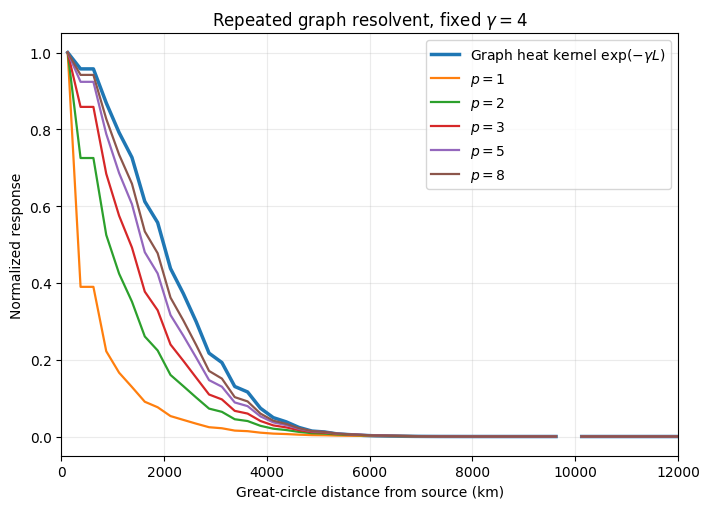

Saved: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/graph_filter_order_p_heatkernel_v1/graph_filter_p_radial_profiles.png
Saved: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/graph_filter_order_p_heatkernel_v1/graph_filter_p_radial_profiles.pdf


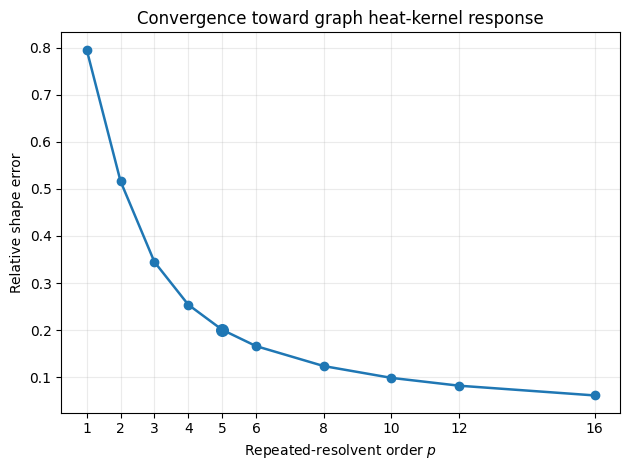

Saved: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/graph_filter_order_p_heatkernel_v1/graph_filter_p_convergence_error.png
Saved: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/graph_filter_order_p_heatkernel_v1/graph_filter_p_convergence_error.pdf
Saved: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/graph_filter_order_p_heatkernel_v1/graph_filter_p_radial_profiles.csv

Completed
Output directory:
/content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/graph_filter_order_p_heatkernel_v1

Main diagnostics:
  1. graph_filter_p_radial_profiles.png
  2. graph_filter_p_convergence_error.png
  3. graph_filter_order_p_metrics.csv


In [ ]:
# ================================================================
# test_graph_filter_order_p_heatkernel_v1.py
#
# Controlled test of repeated-resolvent Graph Filter order p:
#
#     B_p = (I + gamma/p L)^(-p)
#
# compared with the graph heat-kernel limit
#
#     B_inf = exp(-gamma L)
#
# Purpose:
#   - quantify convergence with increasing p
#   - support selection of p=5 as practical standard
#   - produce manuscript-quality radial and error plots
#
# ================================================================

import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt


# ================================================================
# 1. Configuration
# ================================================================

PROJECT_ROOT = "/content/drive/MyDrive/GLOBAL_SW_FV"
GRID_DIR = f"{PROJECT_ROOT}/grid"

G0_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub4.npz"

OUT_DIR = (
    f"{PROJECT_ROOT}/intermediate_generations/"
    "graph_filter_order_p_heatkernel_v1"
)

os.makedirs(OUT_DIR, exist_ok=True)

SOURCE_CELL = 38

GAMMA = 4.0

P_VALUES = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16]

P_PROFILE = [1, 2, 3, 5, 8]

EARTH_RADIUS_KM = 6371.0

RADIAL_BIN_KM = 250.0


# ================================================================
# 2. Load grid
# ================================================================

grid = np.load(G0_FILE, allow_pickle=True)

xyz = np.asarray(grid["cell_center_xyz"], dtype=np.float64)
xyz /= np.linalg.norm(xyz, axis=1, keepdims=True)

area = np.asarray(grid["cell_area"], dtype=np.float64)

dual_cells = grid["dual_cells"]

ncell = len(area)

print("============================================================")
print("Graph Filter p-order / heat-kernel experiment")
print("============================================================")
print(f"Grid cells      : {ncell}")
print(f"Source cell     : {SOURCE_CELL}")
print(f"gamma           : {GAMMA}")
print(f"p values        : {P_VALUES}")
print()


# ================================================================
# 3. Construct graph connectivity and Laplacian
# ================================================================

def build_neighbors_from_dual_cells(dual_cells):

    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):

        poly = np.asarray(poly, dtype=np.int64)

        for k in range(len(poly)):

            a = int(poly[k])
            b = int(poly[(k + 1) % len(poly)])

            key = tuple(sorted((a, b)))

            edge_to_cells.setdefault(key, []).append(ci)

    neighbors = [set() for _ in range(len(dual_cells))]

    for cells in edge_to_cells.values():

        if len(cells) == 2:

            i, j = cells

            neighbors[i].add(j)
            neighbors[j].add(i)

    return [sorted(s) for s in neighbors]


def build_graph_laplacian(dual_cells):

    neighbors = build_neighbors_from_dual_cells(dual_cells)

    n = len(neighbors)

    rows = []
    cols = []
    vals = []

    degree = np.zeros(n, dtype=np.float64)

    for i, ns in enumerate(neighbors):

        degree[i] = len(ns)

        rows.append(i)
        cols.append(i)
        vals.append(degree[i])

        for j in ns:

            rows.append(i)
            cols.append(j)
            vals.append(-1.0)

    L = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(n, n)
    ).tocsr()

    return L, degree


L, degree = build_graph_laplacian(dual_cells)

print(f"L nnz           : {L.nnz}")
print(f"Degree min/mean/max: "
      f"{degree.min():.0f} / {degree.mean():.3f} / {degree.max():.0f}")
print()


# ================================================================
# 4. Source impulse
# ================================================================

x0 = np.zeros(ncell, dtype=np.float64)

# Unit graph impulse.
#
# Since all operators are compared using the identical source,
# this is sufficient for the controlled p-convergence experiment.
#
x0[SOURCE_CELL] = 1.0


# ================================================================
# 5. Exact graph heat-kernel reference
# ================================================================

print("Computing graph heat-kernel reference ...")

heat = spla.expm_multiply(
    -GAMMA * L,
    x0
)

print("Heat-kernel reference complete.")
print()


# ================================================================
# 6. Repeated-resolvent operator
# ================================================================

def repeated_resolvent(L, gamma, p, x):

    step_gamma = gamma / float(p)

    A = (
        sp.eye(L.shape[0], format="csc")
        + step_gamma * L.tocsc()
    )

    # Factor once because the same matrix is applied p times.
    solve = spla.factorized(A)

    y = np.asarray(x, dtype=np.float64).copy()

    for _ in range(p):
        y = solve(y)

    return y


responses = {}

print("Computing repeated-resolvent responses ...")

for p in P_VALUES:

    y = repeated_resolvent(
        L=L,
        gamma=GAMMA,
        p=p,
        x=x0
    )

    responses[p] = y

    print(
        f"p={p:2d}   "
        f"source={y[SOURCE_CELL]:.8e}   "
        f"min={y.min():.8e}   "
        f"max={y.max():.8e}"
    )

print()


# ================================================================
# 7. Error metrics
# ================================================================

def weighted_l2_relative(y, ref, weights):

    num = np.sum(weights * (y - ref)**2)
    den = np.sum(weights * ref**2)

    return np.sqrt(num / den)


def weighted_centered_correlation(y, ref, weights):

    w = weights / np.sum(weights)

    ym = np.sum(w * y)
    rm = np.sum(w * ref)

    ya = y - ym
    ra = ref - rm

    num = np.sum(w * ya * ra)

    den = np.sqrt(
        np.sum(w * ya**2)
        *
        np.sum(w * ra**2)
    )

    return num / den


# Also compare normalized shapes so that p dependence of
# peak amplitude does not dominate the shape comparison.

heat_shape = heat / heat[SOURCE_CELL]

metrics = []

print("============================================================")
print("Convergence to graph heat kernel")
print("============================================================")
print(
    " p      raw_rel_L2      shape_rel_L2      centered_rho"
)

for p in P_VALUES:

    y = responses[p]

    raw_error = weighted_l2_relative(
        y,
        heat,
        area
    )

    y_shape = y / y[SOURCE_CELL]

    shape_error = weighted_l2_relative(
        y_shape,
        heat_shape,
        area
    )

    rho = weighted_centered_correlation(
        y_shape,
        heat_shape,
        area
    )

    metrics.append(
        (p, raw_error, shape_error, rho)
    )

    print(
        f"{p:2d}   "
        f"{raw_error:14.8e}   "
        f"{shape_error:14.8e}   "
        f"{rho:14.8f}"
    )

print()


# ================================================================
# 8. Save metrics
# ================================================================

metrics_array = np.asarray(metrics, dtype=np.float64)

csv_file = os.path.join(
    OUT_DIR,
    "graph_filter_order_p_metrics.csv"
)

np.savetxt(
    csv_file,
    metrics_array,
    delimiter=",",
    header=(
        "p,"
        "raw_relative_L2_to_heat_kernel,"
        "shape_relative_L2_to_heat_kernel,"
        "area_weighted_centered_correlation"
    ),
    comments=""
)

print(f"Saved: {csv_file}")


# ================================================================
# 9. Great-circle distance from source
# ================================================================

source_xyz = xyz[SOURCE_CELL]

cosang = np.clip(
    xyz @ source_xyz,
    -1.0,
    1.0
)

distance_km = (
    EARTH_RADIUS_KM
    * np.arccos(cosang)
)


# ================================================================
# 10. Area-weighted radial shell means
# ================================================================

rmax = distance_km.max()

edges = np.arange(
    0.0,
    rmax + RADIAL_BIN_KM,
    RADIAL_BIN_KM
)

centers = 0.5 * (edges[:-1] + edges[1:])


def radial_area_mean(field):

    result = np.full(len(centers), np.nan)

    for k in range(len(centers)):

        mask = (
            (distance_km >= edges[k])
            &
            (distance_km < edges[k + 1])
        )

        if np.any(mask):

            result[k] = np.sum(
                area[mask] * field[mask]
            ) / np.sum(area[mask])

    return result


radial_heat = radial_area_mean(heat_shape)

radial_profiles = {}

for p in P_PROFILE:

    shape = (
        responses[p]
        / responses[p][SOURCE_CELL]
    )

    radial_profiles[p] = radial_area_mean(shape)


# ================================================================
# 11. Plot radial response
# ================================================================

plt.figure(figsize=(7.2, 5.2))

plt.plot(
    centers,
    radial_heat,
    linewidth=2.5,
    label=r"Graph heat kernel $\exp(-\gamma L)$"
)

for p in P_PROFILE:

    plt.plot(
        centers,
        radial_profiles[p],
        linewidth=1.6,
        label=rf"$p={p}$"
    )

plt.xlabel("Great-circle distance from source (km)")
plt.ylabel("Normalized response")
plt.title(
    rf"Repeated graph resolvent, fixed $\gamma={GAMMA:g}$"
)

plt.xlim(0, min(12000, rmax))

plt.grid(alpha=0.25)

plt.legend()

plt.tight_layout()

png1 = os.path.join(
    OUT_DIR,
    "graph_filter_p_radial_profiles.png"
)

pdf1 = os.path.join(
    OUT_DIR,
    "graph_filter_p_radial_profiles.pdf"
)

plt.savefig(
    png1,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf1,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {png1}")
print(f"Saved: {pdf1}")


# ================================================================
# 12. Plot convergence error versus p
# ================================================================

p_arr = metrics_array[:, 0]

shape_err = metrics_array[:, 2]

plt.figure(figsize=(6.4, 4.8))

plt.plot(
    p_arr,
    shape_err,
    marker="o",
    linewidth=1.8
)

# Highlight p=5
if 5 in P_VALUES:

    i5 = P_VALUES.index(5)

    plt.scatter(
        [5],
        [shape_err[i5]],
        s=70,
        zorder=5
    )

plt.xlabel(r"Repeated-resolvent order $p$")
plt.ylabel("Relative shape error")
plt.title(
    r"Convergence toward graph heat-kernel response"
)

plt.xticks(P_VALUES)

plt.grid(alpha=0.25)

plt.tight_layout()

png2 = os.path.join(
    OUT_DIR,
    "graph_filter_p_convergence_error.png"
)

pdf2 = os.path.join(
    OUT_DIR,
    "graph_filter_p_convergence_error.pdf"
)

plt.savefig(
    png2,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf2,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {png2}")
print(f"Saved: {pdf2}")


# ================================================================
# 13. Save radial profiles
# ================================================================

columns = [
    centers,
    radial_heat
]

header = [
    "distance_km",
    "heat_kernel"
]

for p in P_PROFILE:

    columns.append(
        radial_profiles[p]
    )

    header.append(
        f"p{p}"
    )

radial_data = np.column_stack(columns)

csv_radial = os.path.join(
    OUT_DIR,
    "graph_filter_p_radial_profiles.csv"
)

np.savetxt(
    csv_radial,
    radial_data,
    delimiter=",",
    header=",".join(header),
    comments=""
)

print(f"Saved: {csv_radial}")


# ================================================================
# 14. Summary
# ================================================================

print()
print("============================================================")
print("Completed")
print("============================================================")
print(f"Output directory:")
print(OUT_DIR)
print()
print("Main diagnostics:")
print("  1. graph_filter_p_radial_profiles.png")
print("  2. graph_filter_p_convergence_error.png")
print("  3. graph_filter_order_p_metrics.csv")
print("============================================================")

# Tests with Voronoi grid

# match_gaussian_5000km_voronoi_3G_p5_mu4_v0.py

In [ ]:

"""
match_gaussian_5000km_voronoi_3G_p5_mu4_v0.py

Controlled 3-generation prescribed-Gaussian matching experiment on the
independently generated irregular spherical Voronoi hierarchy.

Purpose
-------
Reproduce, as closely as possible, the 3-generation icosahedral experiment
for a prescribed 5000-km Gaussian covariance using

    p  = 5
    mu = 4

on the Voronoi hierarchy

    G0 (2562) -> G1 (642) -> G2 (162).

Only the nonnegative generation coefficients are optimized. The fit enforces

  1. unit source amplitude, and
  2. exact area-integrated covariance.

The Voronoi source cell is chosen as the cell center geographically closest
to the center of icosahedral G0 source cell 38, so that the two experiments
are centered at essentially the same physical location.
"""

from pathlib import Path
import csv
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import minimize, linprog

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

ICO_G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
VOR_G0_FILE = GRID / "global_irregular_voronoi_graph_G0_N2562_v0.npz"
VOR_G1_FILE = GRID / "global_irregular_voronoi_graph_G1_N0642_v0.npz"
VOR_G2_FILE = GRID / "global_irregular_voronoi_graph_G2_N0162_v0.npz"
VOR_COMM_FILE = GRID / "global_irregular_voronoi_graph_communication_v0.npz"

OUTDIR = GRID / "voronoi_gaussian_5000km_3G_p5_mu4_v0"
OUTDIR.mkdir(parents=True, exist_ok=True)

SIGMA_KM = 5000.0
P_ORDER = 5
MU = 4.0
ICO_SOURCE_G0 = 38
EARTH_RADIUS_M = 6371000.0
SLSQP_FTOL = 1.0e-12
SLSQP_MAXITER = 500


def load_npz(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return np.load(path, allow_pickle=True)


def unit_xyz(x):
    x = np.asarray(x, dtype=float)
    nrm = np.linalg.norm(x, axis=1, keepdims=True)
    if np.any(nrm <= 0.0):
        raise ValueError("Zero-length vector encountered.")
    return x / nrm


def great_circle_distance_m(xyz, source_index):
    q = unit_xyz(xyz)
    s = q[source_index]
    cosine = np.clip(q @ s, -1.0, 1.0)
    return EARTH_RADIUS_M * np.arccos(cosine)


def adjacency_from_archive(z):
    required = ["adjacency_indptr", "adjacency_indices", "adjacency_data", "ncells"]
    missing = [k for k in required if k not in z.files]
    if missing:
        raise KeyError(f"Missing adjacency archive keys: {missing}\nAvailable keys:\n  " + "\n  ".join(z.files))
    n = int(np.asarray(z["ncells"]).item())
    indptr = np.asarray(z["adjacency_indptr"], dtype=np.int64)
    indices = np.asarray(z["adjacency_indices"], dtype=np.int64)
    data = np.asarray(z["adjacency_data"], dtype=float)
    A = sp.csr_matrix((data, indices, indptr), shape=(n, n))
    A.data[:] = 1.0
    A.eliminate_zeros()
    if (A != A.T).nnz != 0:
        raise RuntimeError("Stored adjacency is not symmetric.")
    return A


def graph_laplacian_from_adjacency(A):
    degree = np.asarray(A.sum(axis=1)).ravel()
    return (sp.diags(degree, format="csr") - A).tocsr()


def build_PR(parent, area_f, area_c):
    parent = np.asarray(parent, dtype=np.int64).ravel()
    area_f = np.asarray(area_f, dtype=float)
    area_c = np.asarray(area_c, dtype=float)
    nf = len(area_f)
    nc = len(area_c)
    if len(parent) != nf:
        raise ValueError(f"Parent-map length {len(parent)} does not match fine size {nf}.")
    if np.min(parent) < 0 or np.max(parent) >= nc:
        raise ValueError("Parent map contains an invalid coarse-cell index.")
    P = sp.coo_matrix((np.ones(nf), (np.arange(nf), parent)), shape=(nf, nc)).tocsr()
    R = (sp.diags(1.0 / area_c) @ P.T @ sp.diags(area_f)).tocsr()
    return P, R


def repeated_resolvent(L, mu, x, p=P_ORDER):
    A = sp.eye(L.shape[0], format="csc") + (mu / p) * L.tocsc()
    lu = spla.splu(A)
    y = np.asarray(x, dtype=float).copy()
    for _ in range(p):
        y = lu.solve(y)
    return y


def area_weighted_rel_l2(y, target, area):
    return np.sqrt(np.sum(area * (y - target) ** 2) / np.sum(area * target ** 2))


def area_weighted_centered_corr(y, target, area):
    sw = np.sum(area)
    ym = np.sum(area * y) / sw
    tm = np.sum(area * target) / sw
    ya = y - ym
    ta = target - tm
    num = np.sum(area * ya * ta)
    den = np.sqrt(np.sum(area * ya * ya) * np.sum(area * ta * ta))
    return num / den


def fit_nonnegative_coefficients(B, target, area, source_index):
    B = np.asarray(B, dtype=float)
    target = np.asarray(target, dtype=float)
    area = np.asarray(area, dtype=float)
    source_row = B[source_index, :].copy()
    if np.any(source_row <= 0.0):
        return None, None, "Non-positive source value found in one or more basis responses."
    Bn = B / source_row[np.newaxis, :]
    target_integral = float(area @ target)
    target_norm2 = float(area @ (target * target))
    J = area @ Bn
    jscaled = J / target_integral
    Aeq = np.vstack([np.ones(B.shape[1]), jscaled])
    beq = np.array([1.0, 1.0])
    lp = linprog(c=np.zeros(B.shape[1]), A_eq=Aeq, b_eq=beq,
                 bounds=[(0.0, None)] * B.shape[1], method="highs")
    if not lp.success:
        msg = (
            "No nonnegative feasible solution for the exact source/integral constraints. "
            f"Target integral={target_integral:.6e}; normalized-basis integral range="
            f"[{J.min():.6e}, {J.max():.6e}]. linprog: {lp.message}"
        )
        return None, None, msg
    w0 = lp.x

    def objective(w):
        r = Bn @ w - target
        return 0.5 * float(area @ (r * r)) / target_norm2

    def gradient(w):
        r = Bn @ w - target
        return (Bn.T @ (area * r)) / target_norm2

    constraints = [
        {"type": "eq", "fun": lambda w: float(np.sum(w) - 1.0), "jac": lambda w: np.ones_like(w)},
        {"type": "eq", "fun": lambda w: float(jscaled @ w - 1.0), "jac": lambda w: jscaled.copy()},
    ]

    result = minimize(
        objective, w0, jac=gradient, method="SLSQP",
        bounds=[(0.0, None)] * B.shape[1], constraints=constraints,
        options={"ftol": SLSQP_FTOL, "maxiter": SLSQP_MAXITER, "disp": False},
    )

    if result.success:
        w = result.x.copy()
        msg = "OK"
    else:
        w = w0.copy()
        msg = "SLSQP did not converge; using exact feasible LP solution. " + str(result.message)

    w[np.abs(w) < 1.0e-13] = 0.0
    coef = w / source_row
    return coef, w, msg


# Load hierarchy

g0 = load_npz(VOR_G0_FILE)
g1 = load_npz(VOR_G1_FILE)
g2 = load_npz(VOR_G2_FILE)
comm = load_npz(VOR_COMM_FILE)

xyz0 = np.asarray(g0["cell_center_xyz"], dtype=float)
area0 = np.asarray(g0["cell_area"], dtype=float)
area1 = np.asarray(g1["cell_area"], dtype=float)
area2 = np.asarray(g2["cell_area"], dtype=float)

A0 = adjacency_from_archive(g0)
A1 = adjacency_from_archive(g1)
A2 = adjacency_from_archive(g2)
L0 = graph_laplacian_from_adjacency(A0)
L1 = graph_laplacian_from_adjacency(A1)
L2 = graph_laplacian_from_adjacency(A2)

parent01 = np.asarray(comm["parent01"], dtype=np.int64).ravel()
parent12 = np.asarray(comm["parent12"], dtype=np.int64).ravel()
P01, R10 = build_PR(parent01, area0, area1)
P12, R21 = build_PR(parent12, area1, area2)
P02 = P01 @ P12
R20 = R21 @ R10

# Match source location to icosahedral source cell 38
ico = load_npz(ICO_G0_FILE)
ico_xyz = np.asarray(ico["cell_center_xyz"], dtype=float)
ico_q = unit_xyz(ico_xyz)
vor_q = unit_xyz(xyz0)
source_direction = ico_q[ICO_SOURCE_G0]
VOR_SOURCE_G0 = int(np.argmax(vor_q @ source_direction))
source_angle = np.arccos(np.clip(float(vor_q[VOR_SOURCE_G0] @ source_direction), -1.0, 1.0))
source_separation_km = EARTH_RADIUS_M * source_angle / 1000.0

print("=" * 108)
print("VORONOI 3-GENERATION PRESCRIBED-GAUSSIAN MATCH")
print("=" * 108)
print(f"Target Gaussian sigma       : {SIGMA_KM:.1f} km")
print(f"Repeated resolvent order p  : {P_ORDER}")
print(f"Fixed common mu             : {MU}")
print(f"Icosahedral reference cell  : {ICO_SOURCE_G0}")
print(f"Matched Voronoi source cell : {VOR_SOURCE_G0}")
print(f"Source-location separation  : {source_separation_km:.6f} km\n")

for name, L, A, area in [("G0", L0, A0, area0), ("G1", L1, A1, area1), ("G2", L2, A2, area2)]:
    null = np.linalg.norm(L @ np.ones(len(area)))
    sym = sp.linalg.norm(L - L.T)
    print(f"{name}: N={len(area):4d}, E={A.nnz // 2:5d}, nnz(L)={L.nnz:6d}, ||L1||={null:.3e}, sym={sym:.3e}")

# Area consistency checks
area1_from_children = np.bincount(parent01, weights=area0, minlength=len(area1))
area2_from_children = np.bincount(parent12, weights=area1, minlength=len(area2))
rel_area_01 = np.max(np.abs(area1_from_children - area1)) / np.mean(area1)
rel_area_12 = np.max(np.abs(area2_from_children - area2)) / np.mean(area2)
print("\nTransfer-area checks:")
print(f"  G0 -> G1 relative max mismatch: {rel_area_01:.6e}")
print(f"  G1 -> G2 relative max mismatch: {rel_area_12:.6e}")

# Basis responses

delta0 = np.zeros(len(area0), dtype=float)
delta0[VOR_SOURCE_G0] = 1.0 / area0[VOR_SOURCE_G0]
x0 = delta0
x1 = R10 @ delta0
x2 = R20 @ delta0
b0 = repeated_resolvent(L0, MU, x0)
b1 = P01 @ repeated_resolvent(L1, MU, x1)
b2 = P02 @ repeated_resolvent(L2, MU, x2)
B3 = np.column_stack([b0, b1, b2])
labels3 = ["G0", "G1", "G2"]
basis_source = B3[VOR_SOURCE_G0, :].copy()
normalized_basis = B3 / basis_source[np.newaxis, :]

print("\nFixed-mu basis diagnostics:")
for j, label in enumerate(labels3):
    print(f"  {label}: source={basis_source[j]:.6e}, integral={area0 @ B3[:, j]:.6e}, min={B3[:, j].min():.6e}, max={B3[:, j].max():.6e}")

# Target

distance_m = great_circle_distance_m(xyz0, VOR_SOURCE_G0)
sigma_m = SIGMA_KM * 1000.0
target = np.exp(-0.5 * (distance_m / sigma_m) ** 2)

# Fit
coef, source_weights, fit_message = fit_nonnegative_coefficients(B3, target, area0, VOR_SOURCE_G0)
if coef is None:
    raise RuntimeError("3G Voronoi Gaussian fit failed:\n" + fit_message)

response = B3 @ coef
E = area_weighted_rel_l2(response, target, area0)
rho = area_weighted_centered_corr(response, target, area0)
source_ratio = response[VOR_SOURCE_G0] / target[VOR_SOURCE_G0]
integral_ratio = (area0 @ response) / (area0 @ target)
max_index = int(np.argmax(response))

print("\n" + "=" * 108)
print("FIT RESULT")
print("=" * 108)
print(f"area-weighted relative L2 E : {E:.10f}")
print(f"centered correlation rho    : {rho:.10f}")
print(f"source ratio                : {source_ratio:.12f}")
print(f"integral ratio              : {integral_ratio:.12f}")
print(f"response min                : {response.min():.6e}")
print(f"response max                : {response.max():.6e}")
print(f"response max index          : {max_index}")
print(f"source index                : {VOR_SOURCE_G0}")
print(f"optimizer message           : {fit_message}")

print("\nRaw coefficients:")
for label, value in zip(labels3, coef):
    print(f"  {label}: {value:.12e}")

print("\nDimensionless source-contribution weights:")
for label, value in zip(labels3, source_weights):
    print(f"  {label}: {value:.10f}")
print(f"\nWeight sum: {source_weights.sum():.12f}")

# Existing icosahedral benchmark for the same controlled 3G experiment
ICO_E_REF = 0.18451224
ICO_RHO_REF = 0.98615553

print("\n" + "-" * 108)
print("REFERENCE: ICOSAHEDRAL 3G, sigma=5000 km, p=5, mu=4")
print("-" * 108)
print(f"Icosahedral E reference     : {ICO_E_REF:.8f}")
print(f"Icosahedral rho reference   : {ICO_RHO_REF:.8f}")
print(f"Voronoi - ico difference E  : {E - ICO_E_REF:+.8f}")
print(f"Voronoi - ico difference rho: {rho - ICO_RHO_REF:+.8f}")

# Save NPZ
npz_path = OUTDIR / "voronoi_gaussian_5000km_3G_p5_mu4_v0.npz"
np.savez(
    npz_path,
    sigma_km=SIGMA_KM, p=P_ORDER, mu=MU,
    ico_source_index=ICO_SOURCE_G0,
    voronoi_source_index=VOR_SOURCE_G0,
    source_location_separation_km=source_separation_km,
    distance_m=distance_m, target=target, response=response,
    coeff_3G=coef, source_weights_3G=source_weights,
    labels_3G=np.asarray(labels3),
    E_3G=E, rho_3G=rho,
    source_ratio=source_ratio, integral_ratio=integral_ratio,
    cell_area=area0, cell_center_xyz=xyz0,
    basis_3G=B3, normalized_basis_3G=normalized_basis,
    reference_icosahedral_E=ICO_E_REF,
    reference_icosahedral_rho=ICO_RHO_REF,
)
print(f"\nSaved NPZ:\n  {npz_path}")

# Save one-row CSV
csv_path = OUTDIR / "summary_voronoi_gaussian_5000km_3G_p5_mu4_v0.csv"
row = {
    "sigma_km": SIGMA_KM,
    "p": P_ORDER,
    "mu": MU,
    "ico_source_index": ICO_SOURCE_G0,
    "voronoi_source_index": VOR_SOURCE_G0,
    "source_location_separation_km": source_separation_km,
    "E_3G": E,
    "rho_3G": rho,
    "w_G0": source_weights[0],
    "w_G1": source_weights[1],
    "w_G2": source_weights[2],
    "source_ratio": source_ratio,
    "integral_ratio": integral_ratio,
    "response_min": float(response.min()),
    "response_max": float(response.max()),
    "response_max_index": max_index,
    "ico_reference_E": ICO_E_REF,
    "ico_reference_rho": ICO_RHO_REF,
    "delta_E_voronoi_minus_ico": E - ICO_E_REF,
    "delta_rho_voronoi_minus_ico": rho - ICO_RHO_REF,
}
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(row.keys()))
    writer.writeheader()
    writer.writerow(row)
print(f"Saved CSV:\n  {csv_path}")

print("\nInterpretation:")
print("  1. The source and total area integral should match the target to numerical precision.")
print("  2. Compare E and rho directly with the icosahedral 3G benchmark.")
print("  3. Inspect the nonnegative G0/G1/G2 source weights.")
print("  4. Do not require identical weights on the two mesh hierarchies.")


VORONOI 3-GENERATION PRESCRIBED-GAUSSIAN MATCH
Target Gaussian sigma       : 5000.0 km
Repeated resolvent order p  : 5
Fixed common mu             : 4.0
Icosahedral reference cell  : 38
Matched Voronoi source cell : 1275
Source-location separation  : 253.228498 km

G0: N=2562, E= 7680, nnz(L)= 17922, ||L1||=0.000e+00, sym=0.000e+00
G1: N= 642, E= 1920, nnz(L)=  4482, ||L1||=0.000e+00, sym=0.000e+00
G2: N= 162, E=  480, nnz(L)=  1122, ||L1||=0.000e+00, sym=0.000e+00

Transfer-area checks:
  G0 -> G1 relative max mismatch: 0.000000e+00
  G1 -> G2 relative max mismatch: 0.000000e+00

Fixed-mu basis diagnostics:
  G0: source=7.393131e-14, integral=9.884855e-01, min=1.377420e-24, max=7.393131e-14
  G1: source=1.427871e-14, integral=8.200994e-01, min=2.891806e-18, max=1.465360e-14
  G2: source=5.698159e-15, integral=1.017631e+00, min=4.402507e-16, max=5.698159e-15

FIT RESULT
area-weighted relative L2 E : 0.1867724309
centered correlation rho    : 0.9831174483
source ratio                : 1

# diagnose_voronoi_5000km_maximum_v0.py

In [ ]:
#!/usr/bin/env python3
"""
diagnose_voronoi_5000km_maximum_v0.py

Small diagnostic for the 3-generation Voronoi 5000-km Gaussian experiment.

Purpose
-------
Inspect why the fitted response reports

    response max index != source index

even though the source-amplitude constraint gives response(source) = 1.

The script reads the saved NPZ from

    voronoi_gaussian_5000km_3G_p5_mu4_v0

and reports

  * response(source)
  * global maximum
  * max - source difference
  * distance from source to the max-index cell
  * number of cells equal to the maximum within several tolerances
  * cells within a small tolerance of the maximum
  * top response values and their great-circle distance from the source

No filtering or fitting is repeated.
"""

from pathlib import Path
import numpy as np


# ============================================================
# Configuration
# ============================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

NPZ_FILE = (
    GRID
    / "voronoi_gaussian_5000km_3G_p5_mu4_v0"
    / "voronoi_gaussian_5000km_3G_p5_mu4_v0.npz"
)

EARTH_RADIUS_M = 6371000.0

TOP_N = 20

ABS_TOLERANCES = [
    1.0e-14,
    1.0e-12,
    1.0e-10,
    1.0e-8,
    1.0e-6,
]


# ============================================================
# Utilities
# ============================================================

def unit_xyz(x):
    x = np.asarray(x, dtype=float)
    return x / np.linalg.norm(x, axis=1, keepdims=True)


def great_circle_distance_km(xyz, i, j):
    q = unit_xyz(xyz)
    c = np.clip(float(q[i] @ q[j]), -1.0, 1.0)
    return EARTH_RADIUS_M * np.arccos(c) / 1000.0


# ============================================================
# Load result
# ============================================================

if not NPZ_FILE.exists():
    raise FileNotFoundError(NPZ_FILE)

z = np.load(NPZ_FILE, allow_pickle=True)

response = np.asarray(z["response"], dtype=float)
target = np.asarray(z["target"], dtype=float)
xyz = np.asarray(z["cell_center_xyz"], dtype=float)

source = int(np.asarray(z["voronoi_source_index"]).item())

imax = int(np.argmax(response))

ys = float(response[source])
ymax = float(response[imax])

delta = ymax - ys
rel_delta = delta / max(abs(ymax), 1.0e-300)

dist_imax_km = great_circle_distance_km(xyz, source, imax)

print("=" * 104)
print("VORONOI 5000-km RESPONSE-MAXIMUM DIAGNOSTIC")
print("=" * 104)
print(f"Result file               : {NPZ_FILE}")
print(f"Source index              : {source}")
print(f"Max index                 : {imax}")
print(f"response(source)          : {ys:.17e}")
print(f"response(max)             : {ymax:.17e}")
print(f"max - source              : {delta:.17e}")
print(f"relative difference       : {rel_delta:.17e}")
print(f"source-to-max distance    : {dist_imax_km:.6f} km")
print(f"target(source)            : {target[source]:.17e}")
print(f"target(max-index cell)    : {target[imax]:.17e}")
print()

print("Number of cells within absolute tolerance of the global maximum:")
for tol in ABS_TOLERANCES:
    n = int(np.count_nonzero(np.abs(response - ymax) <= tol))
    print(f"  tol={tol:9.1e} : {n:4d} cells")

print()

# Exact floating-point ties
exact = np.where(response == ymax)[0]

print(f"Exact floating-point ties at ymax: {len(exact)}")

if len(exact) <= 50:
    for idx in exact:
        d = great_circle_distance_km(xyz, source, int(idx))
        print(
            f"  cell={int(idx):4d}  "
            f"response={response[idx]:.17e}  "
            f"distance={d:10.4f} km"
        )

print()

# Top-N cells
order = np.argsort(response)[::-1]
nshow = min(TOP_N, len(order))

print(f"Top {nshow} response values:")
print(
    f"{'rank':>4s} {'cell':>6s} {'response':>22s} "
    f"{'max-y':>14s} {'distance_km':>14s} {'target':>16s}"
)
print("-" * 86)

for rank, idx in enumerate(order[:nshow], start=1):
    idx = int(idx)
    d = great_circle_distance_km(xyz, source, idx)
    print(
        f"{rank:4d} {idx:6d} "
        f"{response[idx]:22.15e} "
        f"{(ymax-response[idx]):14.6e} "
        f"{d:14.6f} "
        f"{target[idx]:16.9e}"
    )

print()

# Useful automatic interpretation
if abs(delta) <= 1.0e-12:
    print("INTERPRETATION:")
    print("  The response at the source and the global maximum differ only at")
    print("  approximately roundoff-level precision. The displaced argmax is")
    print("  therefore consistent with a numerically flat or nearly flat peak,")
    print("  most likely associated with coarse-grid prolongation.")
elif abs(delta) <= 1.0e-8:
    print("INTERPRETATION:")
    print("  The displaced maximum is slightly larger than the source value,")
    print("  but the difference is very small. Inspect the top-cell distances")
    print("  before deciding whether this is merely a broad numerical plateau.")
else:
    print("INTERPRETATION:")
    print("  The displaced maximum is appreciably larger than the source value.")
    print("  This should be understood before proceeding to the 5-generation test.")

print("\nDONE.")


VORONOI 5000-km RESPONSE-MAXIMUM DIAGNOSTIC
Result file               : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_gaussian_5000km_3G_p5_mu4_v0/voronoi_gaussian_5000km_3G_p5_mu4_v0.npz
Source index              : 1275
Max index                 : 1220
response(source)          : 1.00000000000000000e+00
response(max)             : 1.00000000000000000e+00
max - source              : 0.00000000000000000e+00
relative difference       : 0.00000000000000000e+00
source-to-max distance    : 415.956485 km
target(source)            : 1.00000000000000000e+00
target(max-index cell)    : 9.96545584317556354e-01

Number of cells within absolute tolerance of the global maximum:
  tol=  1.0e-14 :    5 cells
  tol=  1.0e-12 :    5 cells
  tol=  1.0e-10 :    5 cells
  tol=  1.0e-08 :    5 cells
  tol=  1.0e-06 :    5 cells

Exact floating-point ties at ymax: 5
  cell=1220  response=1.00000000000000000e+00  distance=  415.9565 km
  cell=1275  response=1.00000000000000000e+00  distance=    0.0000 km


# build_irregular_voronoi_intermediate_generations_v0.py

In [ ]:

"""
build_irregular_voronoi_intermediate_generations_v0.py

Construct the two intermediate graph generations required for the
five-generation Voronoi MGGF experiment:

    G0   : 2562 cells  (existing irregular spherical Voronoi graph)
    G0.5 : 1281 cells  (new aggregation of G0)
    G1   :  642 cells  (existing conservative aggregation of G0)
    G1.5 :  321 cells  (new aggregation of G1)
    G2   :  162 cells  (existing conservative aggregation of G1)

The new intermediate generations are built with the same area-weighted
spherical clustering and graph-aggregation philosophy used in
build_irregular_voronoi_graph_hierarchy_v0.py.

Important
---------
G0.5 and G1.5 are independent aggregate levels used only as additional
MGGF covariance generations. They do NOT replace the already existing
historical G0->G1->G2 communication maps.

Outputs
-------
/content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/
    voronoi_mggf_G0p5_pair_hierarchy_v0.npz
    voronoi_mggf_G1p5_pair_hierarchy_v0.npz

Each archive stores:
  * parent map from the corresponding finer existing generation
  * coarse cell centers
  * coarse cell areas
  * coarse graph edges
  * sparse adjacency arrays
  * degree
  * basic metadata and diagnostics
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import List, Sequence, Tuple

import numpy as np
import scipy.sparse as sp


# ============================================================
# Configuration
# ============================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"
INT.mkdir(parents=True, exist_ok=True)

G0_FILE = GRID / "global_irregular_voronoi_graph_G0_N2562_v0.npz"
G1_FILE = GRID / "global_irregular_voronoi_graph_G1_N0642_v0.npz"

G05_FILE = INT / "voronoi_mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE = INT / "voronoi_mggf_G1p5_pair_hierarchy_v0.npz"

N05 = 1281
N15 = 321

# Use deterministic but distinct random streams for the two new levels.
RNG_SEED_G05 = 314159
RNG_SEED_G15 = 271828

N_CLUSTER_ITERS = 30

EARTH_RADIUS_M = 6.37122e6


# ============================================================
# Data structure
# ============================================================

@dataclass
class GraphLevel:
    xyz: np.ndarray
    area: np.ndarray
    neighbors: List[np.ndarray]
    adjacency: sp.csr_matrix
    degree: np.ndarray


# ============================================================
# Utilities
# ============================================================

def load_npz(path: Path):
    if not path.exists():
        raise FileNotFoundError(path)
    return np.load(path, allow_pickle=True)


def normalize_rows(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    nrm = np.linalg.norm(x, axis=1)

    if np.any(nrm <= 0.0):
        raise ValueError("Cannot normalize a zero-length vector.")

    return x / nrm[:, None]


def xyz_to_lonlat_deg(xyz: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    xyz = normalize_rows(xyz)

    lon = np.rad2deg(np.arctan2(xyz[:, 1], xyz[:, 0]))
    lat = np.rad2deg(
        np.arcsin(np.clip(xyz[:, 2], -1.0, 1.0))
    )

    return lon, lat


def adjacency_from_archive(z) -> sp.csr_matrix:
    required = [
        "adjacency_indptr",
        "adjacency_indices",
        "adjacency_data",
        "ncells",
    ]

    missing = [k for k in required if k not in z.files]

    if missing:
        raise KeyError(
            f"Missing adjacency keys: {missing}\n"
            "Available keys:\n  " + "\n  ".join(z.files)
        )

    n = int(np.asarray(z["ncells"]).item())

    adjacency = sp.csr_matrix(
        (
            np.asarray(z["adjacency_data"], dtype=float),
            np.asarray(z["adjacency_indices"], dtype=np.int64),
            np.asarray(z["adjacency_indptr"], dtype=np.int64),
        ),
        shape=(n, n),
    )

    adjacency.data[:] = 1.0
    adjacency.eliminate_zeros()

    if (adjacency != adjacency.T).nnz != 0:
        raise RuntimeError("Stored adjacency is not symmetric.")

    return adjacency


def neighbors_from_adjacency(
    adjacency: sp.csr_matrix,
) -> List[np.ndarray]:
    neighbors = []

    for i in range(adjacency.shape[0]):
        start = adjacency.indptr[i]
        end = adjacency.indptr[i + 1]

        neighbors.append(
            np.asarray(
                adjacency.indices[start:end],
                dtype=np.int64,
            )
        )

    return neighbors


def adjacency_from_neighbors(
    neighbors: Sequence[np.ndarray],
) -> sp.csr_matrix:
    rows = []
    cols = []

    for i, nbrs in enumerate(neighbors):
        for j in nbrs:
            rows.append(i)
            cols.append(int(j))

    n = len(neighbors)

    adjacency = sp.coo_matrix(
        (
            np.ones(len(rows), dtype=float),
            (rows, cols),
        ),
        shape=(n, n),
    ).tocsr()

    adjacency.data[:] = 1.0
    adjacency.eliminate_zeros()

    if (adjacency != adjacency.T).nnz != 0:
        raise RuntimeError("Constructed adjacency is not symmetric.")

    return adjacency


def load_graph_level(path: Path) -> GraphLevel:
    z = load_npz(path)

    xyz = np.asarray(z["cell_center_xyz"], dtype=float)
    area = np.asarray(z["cell_area"], dtype=float)

    adjacency = adjacency_from_archive(z)
    neighbors = neighbors_from_adjacency(adjacency)
    degree = np.asarray(adjacency.sum(axis=1)).ravel()

    if len(xyz) != len(area):
        raise RuntimeError(
            f"{path.name}: xyz/area length mismatch."
        )

    if adjacency.shape[0] != len(area):
        raise RuntimeError(
            f"{path.name}: adjacency size mismatch."
        )

    return GraphLevel(
        xyz=normalize_rows(xyz),
        area=area,
        neighbors=neighbors,
        adjacency=adjacency,
        degree=degree,
    )


# ============================================================
# Spherical area-weighted clustering
# ============================================================

def farthest_point_seeds(
    xyz: np.ndarray,
    n_seeds: int,
    area: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Area-aware spherical farthest-point initialization.

    This follows the same construction used in the original
    irregular Voronoi hierarchy script.
    """
    n = len(xyz)

    if n_seeds <= 0 or n_seeds > n:
        raise ValueError("Invalid number of coarse seeds.")

    probability = area / np.sum(area)
    first = int(rng.choice(n, p=probability))

    seeds = np.empty(n_seeds, dtype=np.int64)
    seeds[0] = first

    max_similarity = xyz @ xyz[first]

    selected = np.zeros(n, dtype=bool)
    selected[first] = True

    for k in range(1, n_seeds):
        score = max_similarity.copy()

        # Same mild area weighting as in the original hierarchy builder.
        score += 0.02 * area / np.mean(area)
        score[selected] = np.inf

        new_seed = int(np.argmin(score))

        seeds[k] = new_seed
        selected[new_seed] = True

        similarity = xyz @ xyz[new_seed]
        max_similarity = np.maximum(
            max_similarity,
            similarity,
        )

    return seeds


def assign_nearest_spherical_centers(
    xyz: np.ndarray,
    centers: np.ndarray,
) -> np.ndarray:
    similarity = xyz @ centers.T

    return np.argmax(
        similarity,
        axis=1,
    ).astype(np.int64)


def repair_empty_clusters(
    xyz: np.ndarray,
    area: np.ndarray,
    centers: np.ndarray,
    parent: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    n_clusters = len(centers)

    counts = np.bincount(
        parent,
        minlength=n_clusters,
    )

    empty = np.where(counts == 0)[0]

    if len(empty) == 0:
        return centers, parent

    similarity = np.sum(
        xyz * centers[parent],
        axis=1,
    )

    poor_fit_order = np.argsort(similarity)

    used = set()

    for cluster in empty:
        replacement = None

        for idx in poor_fit_order:
            idx = int(idx)
            old_cluster = int(parent[idx])

            if idx in used:
                continue

            if counts[old_cluster] <= 1:
                continue

            replacement = idx
            break

        if replacement is None:
            raise RuntimeError(
                "Unable to repair an empty cluster."
            )

        old_cluster = int(parent[replacement])

        counts[old_cluster] -= 1

        parent[replacement] = cluster
        counts[cluster] += 1

        centers[cluster] = xyz[replacement]

        used.add(replacement)

    return normalize_rows(centers), parent


def spherical_area_weighted_clustering(
    xyz: np.ndarray,
    area: np.ndarray,
    n_clusters: int,
    rng: np.random.Generator,
    n_iterations: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Area-weighted spherical k-means used to define graph aggregates.
    """
    seed_indices = farthest_point_seeds(
        xyz,
        n_clusters,
        area,
        rng,
    )

    centers = xyz[seed_indices].copy()

    previous_parent = None

    for iteration in range(n_iterations):
        parent = assign_nearest_spherical_centers(
            xyz,
            centers,
        )

        centers, parent = repair_empty_clusters(
            xyz,
            area,
            centers,
            parent,
        )

        new_centers = np.zeros_like(centers)

        for p in range(n_clusters):
            members = np.where(parent == p)[0]

            if len(members) == 0:
                raise RuntimeError(
                    f"Cluster {p} remains empty after repair."
                )

            vector = np.sum(
                area[members, None] * xyz[members],
                axis=0,
            )

            norm = np.linalg.norm(vector)

            if norm <= 1.0e-14:
                raise RuntimeError(
                    f"Cluster {p} has a degenerate spherical centroid."
                )

            new_centers[p] = vector / norm

        changed = (
            previous_parent is None
            or not np.array_equal(
                parent,
                previous_parent,
            )
        )

        centers = new_centers
        previous_parent = parent.copy()

        counts = np.bincount(
            parent,
            minlength=n_clusters,
        )

        print(
            f"  clustering iteration {iteration + 1:2d}: "
            f"child count min/mean/max = "
            f"{counts.min()}/{counts.mean():.2f}/{counts.max()}"
        )

        if not changed:
            print("  clustering converged.")
            break

    final_parent = assign_nearest_spherical_centers(
        xyz,
        centers,
    )

    centers, final_parent = repair_empty_clusters(
        xyz,
        area,
        centers,
        final_parent,
    )

    return centers, final_parent


# ============================================================
# Conservative coarse graph construction
# ============================================================

def coarse_neighbors_from_parent(
    fine_neighbors: Sequence[np.ndarray],
    parent: np.ndarray,
    n_coarse: int,
) -> List[np.ndarray]:
    coarse_sets = [set() for _ in range(n_coarse)]

    for i, nbrs in enumerate(fine_neighbors):
        pi = int(parent[i])

        for j in nbrs:
            pj = int(parent[int(j)])

            if pi != pj:
                coarse_sets[pi].add(pj)
                coarse_sets[pj].add(pi)

    return [
        np.asarray(
            sorted(s),
            dtype=np.int64,
        )
        for s in coarse_sets
    ]


def build_aggregated_graph_level(
    fine: GraphLevel,
    n_coarse: int,
    rng: np.random.Generator,
    n_iterations: int,
) -> Tuple[GraphLevel, np.ndarray]:
    centers, parent = spherical_area_weighted_clustering(
        fine.xyz,
        fine.area,
        n_coarse,
        rng,
        n_iterations,
    )

    area_coarse = np.bincount(
        parent,
        weights=fine.area,
        minlength=n_coarse,
    ).astype(np.float64)

    if np.any(area_coarse <= 0.0):
        raise RuntimeError(
            "A coarse aggregate has nonpositive area."
        )

    neighbors_coarse = coarse_neighbors_from_parent(
        fine.neighbors,
        parent,
        n_coarse,
    )

    adjacency_coarse = adjacency_from_neighbors(
        neighbors_coarse
    )

    degree_coarse = np.asarray(
        adjacency_coarse.sum(axis=1)
    ).ravel()

    coarse = GraphLevel(
        xyz=centers,
        area=area_coarse,
        neighbors=neighbors_coarse,
        adjacency=adjacency_coarse,
        degree=degree_coarse,
    )

    return coarse, parent


# ============================================================
# Diagnostics
# ============================================================

def connected_components_count(
    adjacency: sp.csr_matrix,
) -> int:
    n_components, _ = sp.csgraph.connected_components(
        adjacency,
        directed=False,
    )

    return int(n_components)


def edge_array_from_adjacency(
    adjacency: sp.csr_matrix,
) -> np.ndarray:
    coo = sp.triu(
        adjacency,
        k=1,
        format="coo",
    )

    return np.column_stack(
        [
            coo.row.astype(np.int64),
            coo.col.astype(np.int64),
        ]
    )


def report_graph_level(
    name: str,
    graph: GraphLevel,
) -> None:
    sphere_area = 4.0 * np.pi * EARTH_RADIUS_M**2

    area_sum = np.sum(graph.area)
    rel_area_error = (
        area_sum - sphere_area
    ) / sphere_area

    components = connected_components_count(
        graph.adjacency
    )

    edges = graph.adjacency.nnz // 2

    print("\n" + "=" * 78)
    print(name)
    print("=" * 78)
    print(f"number of vertices          : {len(graph.xyz)}")
    print(f"number of edges             : {edges}")
    print(
        "degree min/mean/max       : "
        f"{int(graph.degree.min())}/"
        f"{graph.degree.mean():.6f}/"
        f"{int(graph.degree.max())}"
    )
    print(f"connected components        : {components}")
    print(
        "cell area min/mean/max    : "
        f"{graph.area.min():.8e}/"
        f"{graph.area.mean():.8e}/"
        f"{graph.area.max():.8e}"
    )
    print(f"total area [m^2]            : {area_sum:.12e}")
    print(f"relative sphere-area error  : {rel_area_error:+.6e}")

    if components != 1:
        raise RuntimeError(
            f"{name} graph is disconnected."
        )


def report_parent_map(
    name: str,
    parent: np.ndarray,
    area_fine: np.ndarray,
    area_coarse: np.ndarray,
) -> None:
    n_coarse = len(area_coarse)

    counts = np.bincount(
        parent,
        minlength=n_coarse,
    )

    area_from_children = np.bincount(
        parent,
        weights=area_fine,
        minlength=n_coarse,
    )

    max_area_error = np.max(
        np.abs(
            area_from_children - area_coarse
        )
    )

    relative_error = (
        max_area_error
        / np.mean(area_coarse)
    )

    print("\n" + "-" * 78)
    print(name)
    print("-" * 78)
    print(
        "child count min/mean/max  : "
        f"{counts.min()}/"
        f"{counts.mean():.6f}/"
        f"{counts.max()}"
    )
    print(
        f"empty parents              : "
        f"{np.count_nonzero(counts == 0)}"
    )
    print(
        f"maximum parent-area mismatch: "
        f"{max_area_error:.12e}"
    )
    print(
        f"relative maximum mismatch   : "
        f"{relative_error:.12e}"
    )

    if np.any(counts == 0):
        raise RuntimeError(
            f"{name} contains empty parents."
        )


# ============================================================
# Saving
# ============================================================

def save_intermediate_level(
    path: Path,
    fine_name: str,
    coarse_name: str,
    fine: GraphLevel,
    coarse: GraphLevel,
    parent: np.ndarray,
    parent_key: str,
) -> None:
    lon, lat = xyz_to_lonlat_deg(coarse.xyz)

    edges = edge_array_from_adjacency(
        coarse.adjacency
    )

    counts = np.bincount(
        parent,
        minlength=len(coarse.area),
    )

    area_from_children = np.bincount(
        parent,
        weights=fine.area,
        minlength=len(coarse.area),
    )

    max_area_mismatch = float(
        np.max(
            np.abs(
                area_from_children - coarse.area
            )
        )
    )

    payload = {
        parent_key: np.asarray(
            parent,
            dtype=np.int64,
        ),

        f"cell_center_xyz_{coarse_name}":
            np.asarray(coarse.xyz, dtype=float),

        f"cell_center_lon_{coarse_name}":
            np.asarray(lon, dtype=float),

        f"cell_center_lat_{coarse_name}":
            np.asarray(lat, dtype=float),

        f"cell_area_{coarse_name}":
            np.asarray(coarse.area, dtype=float),

        f"edges_{coarse_name}":
            np.asarray(edges, dtype=np.int64),

        f"degree_{coarse_name}":
            np.asarray(coarse.degree, dtype=float),

        f"adjacency_indptr_{coarse_name}":
            np.asarray(
                coarse.adjacency.indptr,
                dtype=np.int64,
            ),

        f"adjacency_indices_{coarse_name}":
            np.asarray(
                coarse.adjacency.indices,
                dtype=np.int64,
            ),

        f"adjacency_data_{coarse_name}":
            np.asarray(
                coarse.adjacency.data,
                dtype=float,
            ),

        f"ncells_{coarse_name}":
            np.asarray(
                len(coarse.area),
                dtype=np.int64,
            ),

        f"nedges_{coarse_name}":
            np.asarray(
                len(edges),
                dtype=np.int64,
            ),

        "fine_level_name":
            np.asarray(fine_name),

        "coarse_level_name":
            np.asarray(coarse_name),

        "child_count_min":
            np.asarray(
                counts.min(),
                dtype=np.int64,
            ),

        "child_count_mean":
            np.asarray(
                counts.mean(),
                dtype=float,
            ),

        "child_count_max":
            np.asarray(
                counts.max(),
                dtype=np.int64,
            ),

        "max_parent_area_mismatch":
            np.asarray(
                max_area_mismatch,
                dtype=float,
            ),

        "construction":
            np.asarray(
                f"{coarse_name} conservative graph aggregation "
                f"of existing {fine_name}"
            ),
    }

    np.savez(
        path,
        **payload,
    )

    print(f"Saved: {path}")


# ============================================================
# Main
# ============================================================

def main():
    print("=" * 88)
    print("BUILDING INTERMEDIATE VORONOI MGGF GENERATIONS")
    print("=" * 88)

    print("\nLoading existing G0 and G1...")

    g0 = load_graph_level(G0_FILE)
    g1 = load_graph_level(G1_FILE)

    report_graph_level(
        "Existing G0: irregular spherical Voronoi graph",
        g0,
    )

    report_graph_level(
        "Existing G1: conservative graph aggregation",
        g1,
    )

    # --------------------------------------------------------
    # G0.5 from G0
    # --------------------------------------------------------

    print("\n" + "=" * 88)
    print("Constructing G0.5 from existing G0")
    print("=" * 88)

    rng05 = np.random.default_rng(
        RNG_SEED_G05
    )

    g05, parent005 = build_aggregated_graph_level(
        g0,
        N05,
        rng05,
        N_CLUSTER_ITERS,
    )

    report_graph_level(
        "G0.5: intermediate Voronoi aggregate graph",
        g05,
    )

    report_parent_map(
        "Parent map G0 -> G0.5",
        parent005,
        g0.area,
        g05.area,
    )

    save_intermediate_level(
        G05_FILE,
        fine_name="G0",
        coarse_name="G0p5",
        fine=g0,
        coarse=g05,
        parent=parent005,
        parent_key="parent_of_G0",
    )

    # --------------------------------------------------------
    # G1.5 from G1
    # --------------------------------------------------------

    print("\n" + "=" * 88)
    print("Constructing G1.5 from existing G1")
    print("=" * 88)

    rng15 = np.random.default_rng(
        RNG_SEED_G15
    )

    g15, parent115 = build_aggregated_graph_level(
        g1,
        N15,
        rng15,
        N_CLUSTER_ITERS,
    )

    report_graph_level(
        "G1.5: intermediate Voronoi aggregate graph",
        g15,
    )

    report_parent_map(
        "Parent map G1 -> G1.5",
        parent115,
        g1.area,
        g15.area,
    )

    save_intermediate_level(
        G15_FILE,
        fine_name="G1",
        coarse_name="G1p5",
        fine=g1,
        coarse=g15,
        parent=parent115,
        parent_key="parent_of_G1",
    )

    # --------------------------------------------------------
    # Final comparison
    # --------------------------------------------------------

    print("\n" + "=" * 88)
    print("FINAL FIVE-GENERATION SIZE SUMMARY")
    print("=" * 88)

    print(
        f"G0   : N={len(g0.area):4d}, "
        f"E={g0.adjacency.nnz // 2:5d}"
    )
    print(
        f"G0.5 : N={len(g05.area):4d}, "
        f"E={g05.adjacency.nnz // 2:5d}"
    )
    print(
        f"G1   : N={len(g1.area):4d}, "
        f"E={g1.adjacency.nnz // 2:5d}"
    )
    print(
        f"G1.5 : N={len(g15.area):4d}, "
        f"E={g15.adjacency.nnz // 2:5d}"
    )

    print("\nExpected population sequence:")
    print("  2562 -> 1281 -> 642 -> 321 -> 162")

    print("\nCreated files:")
    print(f"  {G05_FILE}")
    print(f"  {G15_FILE}")

    print("\nNext step:")
    print(
        "  Use these two archives together with the existing "
        "G0/G1/G2 Voronoi hierarchy"
    )
    print(
        "  to repeat the prescribed 5000-km Gaussian experiment "
        "with 3G and 5G."
    )

    print("\nDONE.")


if __name__ == "__main__":
    main()


BUILDING INTERMEDIATE VORONOI MGGF GENERATIONS

Loading existing G0 and G1...

Existing G0: irregular spherical Voronoi graph
number of vertices          : 2562
number of edges             : 7680
degree min/mean/max       : 4/5.995316/8
connected components        : 1
cell area min/mean/max    : 1.39089110e+11/1.99102146e+11/2.56412387e+11
total area [m^2]            : 5.100996990708e+14
relative sphere-area error  : -2.450501e-16

Existing G1: conservative graph aggregation
number of vertices          : 642
number of edges             : 1920
degree min/mean/max       : 3/5.981308/9
connected components        : 1
cell area min/mean/max    : 1.70798397e+11/7.94547818e+11/1.42898206e+12
total area [m^2]            : 5.100996990708e+14
relative sphere-area error  : -2.450501e-16

Constructing G0.5 from existing G0
  clustering iteration  1: child count min/mean/max = 1/2.00/6
  clustering iteration  2: child count min/mean/max = 1/2.00/5
  clustering iteration  3: child count min/mean/ma

# match_gaussian_5000km_voronoi_3G_vs_5G_p5_mu4_v0.py

In [ ]:
#!/usr/bin/env python3
"""
match_gaussian_5000km_voronoi_3G_vs_5G_p5_mu4_v0.py

Controlled comparison of 3-generation and 5-generation Multigrid Graph
Filter (MGGF) representations of a prescribed 5000-km Gaussian covariance
on the independently generated irregular spherical Voronoi hierarchy.

Fixed parameters
----------------
    sigma = 5000 km
    p     = 5
    mu    = 4

Three-generation basis
----------------------
    G0, G1, G2

Five-generation basis
---------------------
    G0, G0.5, G1, G1.5, G2

Only nonnegative generation coefficients are optimized. For each fit, the
following constraints are imposed exactly:

  1. unit response at the source;
  2. exact area-integrated covariance.

Primary diagnostics
-------------------
  * area-weighted relative L2 shape error E
  * area-weighted centered correlation rho
  * nonnegative source-contribution weights
  * source-amplitude ratio
  * area-integral ratio
  * 5G improvement relative to 3G

The Voronoi source cell is chosen as the G0 cell geographically closest to
icosahedral G0 source cell 38, matching the preceding 3G experiment.

This script uses the existing Voronoi G0/G1/G2 hierarchy and the newly
constructed G0.5/G1.5 intermediate graph levels.
"""

from pathlib import Path
import csv

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import minimize, linprog


# ============================================================
# Configuration
# ============================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"

ICO_G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"

VOR_G0_FILE = GRID / "global_irregular_voronoi_graph_G0_N2562_v0.npz"
VOR_G1_FILE = GRID / "global_irregular_voronoi_graph_G1_N0642_v0.npz"
VOR_G2_FILE = GRID / "global_irregular_voronoi_graph_G2_N0162_v0.npz"
VOR_COMM_FILE = GRID / "global_irregular_voronoi_graph_communication_v0.npz"

VOR_G05_FILE = INT / "voronoi_mggf_G0p5_pair_hierarchy_v0.npz"
VOR_G15_FILE = INT / "voronoi_mggf_G1p5_pair_hierarchy_v0.npz"

OUTDIR = GRID / "voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0"
OUTDIR.mkdir(parents=True, exist_ok=True)

SIGMA_KM = 5000.0
P_ORDER = 5
MU = 4.0

ICO_SOURCE_G0 = 38
EARTH_RADIUS_M = 6371000.0

SLSQP_FTOL = 1.0e-12
SLSQP_MAXITER = 1000

# Published/previously obtained icosahedral comparison values
ICO_3G_E = 0.18451224
ICO_3G_RHO = 0.98615553

ICO_5G_E = 0.17452954
ICO_5G_RHO = 0.98795042

ICO_3G_WEIGHTS = np.array([
    0.0,
    0.4343,
    0.5657,
], dtype=float)

ICO_5G_WEIGHTS = np.array([
    0.0,
    0.0,
    0.03080427,
    0.53262034,
    0.43657540,
], dtype=float)


# ============================================================
# Basic utilities
# ============================================================

def load_npz(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    return np.load(path, allow_pickle=True)


def unit_xyz(x):
    x = np.asarray(x, dtype=float)

    nrm = np.linalg.norm(
        x,
        axis=1,
        keepdims=True,
    )

    if np.any(nrm <= 0.0):
        raise ValueError(
            "Zero-length vector encountered."
        )

    return x / nrm


def great_circle_distance_m(
    xyz,
    source_index,
):
    q = unit_xyz(xyz)
    s = q[source_index]

    cosine = np.clip(
        q @ s,
        -1.0,
        1.0,
    )

    return EARTH_RADIUS_M * np.arccos(cosine)


# ============================================================
# Graph loading
# ============================================================

def adjacency_from_standard_archive(z):
    required = [
        "adjacency_indptr",
        "adjacency_indices",
        "adjacency_data",
        "ncells",
    ]

    missing = [
        k for k in required
        if k not in z.files
    ]

    if missing:
        raise KeyError(
            f"Missing standard adjacency keys: {missing}"
        )

    n = int(
        np.asarray(z["ncells"]).item()
    )

    A = sp.csr_matrix(
        (
            np.asarray(
                z["adjacency_data"],
                dtype=float,
            ),
            np.asarray(
                z["adjacency_indices"],
                dtype=np.int64,
            ),
            np.asarray(
                z["adjacency_indptr"],
                dtype=np.int64,
            ),
        ),
        shape=(n, n),
    )

    A.data[:] = 1.0
    A.eliminate_zeros()

    if (A != A.T).nnz != 0:
        raise RuntimeError(
            "Stored standard adjacency is not symmetric."
        )

    return A


def load_intermediate_level(
    path,
    level_tag,
    parent_key,
):
    """
    Read an intermediate-generation archive written by
    build_irregular_voronoi_intermediate_generations_v0.py.
    """
    z = load_npz(path)

    area_key = f"cell_area_{level_tag}"
    xyz_key = f"cell_center_xyz_{level_tag}"
    indptr_key = f"adjacency_indptr_{level_tag}"
    indices_key = f"adjacency_indices_{level_tag}"
    data_key = f"adjacency_data_{level_tag}"
    ncells_key = f"ncells_{level_tag}"

    required = [
        area_key,
        xyz_key,
        indptr_key,
        indices_key,
        data_key,
        ncells_key,
        parent_key,
    ]

    missing = [
        k for k in required
        if k not in z.files
    ]

    if missing:
        raise KeyError(
            f"{Path(path).name}: missing keys: {missing}\n"
            f"Available keys:\n  "
            + "\n  ".join(z.files)
        )

    area = np.asarray(
        z[area_key],
        dtype=float,
    )

    xyz = np.asarray(
        z[xyz_key],
        dtype=float,
    )

    n = int(
        np.asarray(
            z[ncells_key]
        ).item()
    )

    A = sp.csr_matrix(
        (
            np.asarray(
                z[data_key],
                dtype=float,
            ),
            np.asarray(
                z[indices_key],
                dtype=np.int64,
            ),
            np.asarray(
                z[indptr_key],
                dtype=np.int64,
            ),
        ),
        shape=(n, n),
    )

    A.data[:] = 1.0
    A.eliminate_zeros()

    if (A != A.T).nnz != 0:
        raise RuntimeError(
            f"{level_tag} adjacency is not symmetric."
        )

    parent = np.asarray(
        z[parent_key],
        dtype=np.int64,
    ).ravel()

    return {
        "area": area,
        "xyz": xyz,
        "adjacency": A,
        "parent": parent,
    }


def graph_laplacian(A):
    degree = np.asarray(
        A.sum(axis=1)
    ).ravel()

    return (
        sp.diags(
            degree,
            format="csr",
        )
        - A
    ).tocsr()


def build_PR(
    parent,
    area_f,
    area_c,
):
    """
    Piecewise-constant prolongation P and
    area-weighted conservative restriction R:

        R = A_c^{-1} P^T A_f
    """
    parent = np.asarray(
        parent,
        dtype=np.int64,
    ).ravel()

    area_f = np.asarray(
        area_f,
        dtype=float,
    )

    area_c = np.asarray(
        area_c,
        dtype=float,
    )

    nf = len(area_f)
    nc = len(area_c)

    if len(parent) != nf:
        raise ValueError(
            "Parent-map length does not match fine level."
        )

    if (
        np.min(parent) < 0
        or np.max(parent) >= nc
    ):
        raise ValueError(
            "Parent map contains an invalid coarse index."
        )

    P = sp.coo_matrix(
        (
            np.ones(
                nf,
                dtype=float,
            ),
            (
                np.arange(
                    nf,
                    dtype=np.int64,
                ),
                parent,
            ),
        ),
        shape=(nf, nc),
    ).tocsr()

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()

    return P, R


# ============================================================
# Graph filter
# ============================================================

def repeated_resolvent(
    L,
    mu,
    x,
    p=P_ORDER,
):
    """
    Apply

        (I + mu/p * L)^(-p) x.
    """
    A = (
        sp.eye(
            L.shape[0],
            format="csc",
        )
        + (mu / p) * L.tocsc()
    )

    lu = spla.splu(A)

    y = np.asarray(
        x,
        dtype=float,
    ).copy()

    for _ in range(p):
        y = lu.solve(y)

    return y


# ============================================================
# Diagnostics
# ============================================================

def area_weighted_rel_l2(
    y,
    target,
    area,
):
    num = np.sum(
        area * (y - target) ** 2
    )

    den = np.sum(
        area * target ** 2
    )

    return np.sqrt(
        num / den
    )


def area_weighted_centered_corr(
    y,
    target,
    area,
):
    sw = np.sum(area)

    ym = np.sum(
        area * y
    ) / sw

    tm = np.sum(
        area * target
    ) / sw

    ya = y - ym
    ta = target - tm

    num = np.sum(
        area * ya * ta
    )

    den = np.sqrt(
        np.sum(area * ya * ya)
        * np.sum(area * ta * ta)
    )

    return num / den


def fit_nonnegative_coefficients(
    B,
    target,
    area,
    source_index,
):
    """
    Fit nonnegative generation coefficients using dimensionless
    source-contribution weights.

    Normalize each basis column to source amplitude one:

        Bn_j = B_j / B_j(source)

    and solve for w_j subject to

        sum_j w_j = 1

    and

        area_integral(Bn @ w)
        =
        area_integral(target).

    The returned raw coefficients satisfy

        response = B @ coef.
    """
    B = np.asarray(
        B,
        dtype=float,
    )

    target = np.asarray(
        target,
        dtype=float,
    )

    area = np.asarray(
        area,
        dtype=float,
    )

    source_row = B[
        source_index,
        :
    ].copy()

    if np.any(source_row <= 0.0):
        return (
            None,
            None,
            "One or more basis responses have non-positive source amplitude.",
        )

    Bn = (
        B
        / source_row[np.newaxis, :]
    )

    target_integral = float(
        area @ target
    )

    target_norm2 = float(
        area @ (target * target)
    )

    J = area @ Bn

    jscaled = (
        J / target_integral
    )

    Aeq = np.vstack([
        np.ones(
            B.shape[1],
            dtype=float,
        ),
        jscaled,
    ])

    beq = np.array(
        [1.0, 1.0],
        dtype=float,
    )

    lp = linprog(
        c=np.zeros(
            B.shape[1],
            dtype=float,
        ),
        A_eq=Aeq,
        b_eq=beq,
        bounds=[
            (0.0, None)
        ] * B.shape[1],
        method="highs",
    )

    if not lp.success:
        return (
            None,
            None,
            (
                "No nonnegative feasible solution for exact "
                "source/integral constraints. "
                f"linprog: {lp.message}"
            ),
        )

    w0 = lp.x

    def objective(w):
        r = Bn @ w - target

        return (
            0.5
            * float(
                area @ (r * r)
            )
            / target_norm2
        )

    def gradient(w):
        r = Bn @ w - target

        return (
            Bn.T @ (area * r)
        ) / target_norm2

    constraints = [
        {
            "type": "eq",
            "fun": lambda w:
                float(np.sum(w) - 1.0),
            "jac": lambda w:
                np.ones_like(w),
        },
        {
            "type": "eq",
            "fun": lambda w:
                float(jscaled @ w - 1.0),
            "jac": lambda w:
                jscaled.copy(),
        },
    ]

    result = minimize(
        objective,
        w0,
        jac=gradient,
        method="SLSQP",
        bounds=[
            (0.0, None)
        ] * B.shape[1],
        constraints=constraints,
        options={
            "ftol": SLSQP_FTOL,
            "maxiter": SLSQP_MAXITER,
            "disp": False,
        },
    )

    if result.success:
        w = result.x.copy()
        message = "OK"
    else:
        w = w0.copy()

        message = (
            "SLSQP did not converge; "
            "using exact feasible LP solution. "
            f"SLSQP message: {result.message}"
        )

    w[
        np.abs(w) < 1.0e-13
    ] = 0.0

    coef = (
        w / source_row
    )

    return (
        coef,
        w,
        message,
    )


def evaluate_fit(
    name,
    B,
    labels,
    target,
    area,
    source_index,
):
    coef, weights, message = (
        fit_nonnegative_coefficients(
            B,
            target,
            area,
            source_index,
        )
    )

    if coef is None:
        raise RuntimeError(
            f"{name} fit failed:\n{message}"
        )

    response = B @ coef

    E = area_weighted_rel_l2(
        response,
        target,
        area,
    )

    rho = area_weighted_centered_corr(
        response,
        target,
        area,
    )

    source_ratio = (
        response[source_index]
        / target[source_index]
    )

    integral_ratio = (
        area @ response
    ) / (
        area @ target
    )

    imax = int(
        np.argmax(response)
    )

    return {
        "name": name,
        "labels": labels,
        "coef": coef,
        "weights": weights,
        "message": message,
        "response": response,
        "E": float(E),
        "rho": float(rho),
        "source_ratio": float(source_ratio),
        "integral_ratio": float(integral_ratio),
        "imax": imax,
        "ymax": float(
            response[imax]
        ),
    }


# ============================================================
# Load existing hierarchy
# ============================================================

g0 = load_npz(
    VOR_G0_FILE
)

g1 = load_npz(
    VOR_G1_FILE
)

g2 = load_npz(
    VOR_G2_FILE
)

comm = load_npz(
    VOR_COMM_FILE
)

xyz0 = np.asarray(
    g0["cell_center_xyz"],
    dtype=float,
)

area0 = np.asarray(
    g0["cell_area"],
    dtype=float,
)

area1 = np.asarray(
    g1["cell_area"],
    dtype=float,
)

area2 = np.asarray(
    g2["cell_area"],
    dtype=float,
)

A0 = adjacency_from_standard_archive(
    g0
)

A1 = adjacency_from_standard_archive(
    g1
)

A2 = adjacency_from_standard_archive(
    g2
)

parent01 = np.asarray(
    comm["parent01"],
    dtype=np.int64,
).ravel()

parent12 = np.asarray(
    comm["parent12"],
    dtype=np.int64,
).ravel()

P01, R10 = build_PR(
    parent01,
    area0,
    area1,
)

P12, R21 = build_PR(
    parent12,
    area1,
    area2,
)

P02 = P01 @ P12
R20 = R21 @ R10


# ============================================================
# Load intermediate levels
# ============================================================

g05 = load_intermediate_level(
    VOR_G05_FILE,
    level_tag="G0p5",
    parent_key="parent_of_G0",
)

g15 = load_intermediate_level(
    VOR_G15_FILE,
    level_tag="G1p5",
    parent_key="parent_of_G1",
)

area05 = g05["area"]
area15 = g15["area"]

A05 = g05["adjacency"]
A15 = g15["adjacency"]

parent005 = g05["parent"]
parent115 = g15["parent"]

P005, R050 = build_PR(
    parent005,
    area0,
    area05,
)

P115, R151 = build_PR(
    parent115,
    area1,
    area15,
)

# G1.5 lives between G1 and the final G0 field:
P015 = P01 @ P115
R150 = R151 @ R10


# ============================================================
# Laplacians
# ============================================================

L0 = graph_laplacian(A0)
L05 = graph_laplacian(A05)
L1 = graph_laplacian(A1)
L15 = graph_laplacian(A15)
L2 = graph_laplacian(A2)


# ============================================================
# Match source location to the icosahedral experiment
# ============================================================

ico = load_npz(
    ICO_G0_FILE
)

ico_xyz = np.asarray(
    ico["cell_center_xyz"],
    dtype=float,
)

ico_q = unit_xyz(
    ico_xyz
)

vor_q = unit_xyz(
    xyz0
)

source_direction = (
    ico_q[ICO_SOURCE_G0]
)

VOR_SOURCE_G0 = int(
    np.argmax(
        vor_q @ source_direction
    )
)

source_angle = np.arccos(
    np.clip(
        float(
            vor_q[VOR_SOURCE_G0]
            @ source_direction
        ),
        -1.0,
        1.0,
    )
)

source_separation_km = (
    EARTH_RADIUS_M
    * source_angle
    / 1000.0
)


# ============================================================
# Structural checks
# ============================================================

print("=" * 112)
print("VORONOI PRESCRIBED 5000-km GAUSSIAN: 3G vs 5G")
print("=" * 112)

print(f"Target Gaussian sigma       : {SIGMA_KM:.1f} km")
print(f"Repeated resolvent order p  : {P_ORDER}")
print(f"Fixed common mu             : {MU}")
print(f"Icosahedral reference cell  : {ICO_SOURCE_G0}")
print(f"Matched Voronoi source cell : {VOR_SOURCE_G0}")
print(f"Source-location separation  : {source_separation_km:.6f} km")
print()

levels = [
    ("G0", L0, A0, area0),
    ("G0.5", L05, A05, area05),
    ("G1", L1, A1, area1),
    ("G1.5", L15, A15, area15),
    ("G2", L2, A2, area2),
]

for name, L, A, area in levels:
    null = np.linalg.norm(
        L @ np.ones(len(area))
    )

    sym = sp.linalg.norm(
        L - L.T
    )

    print(
        f"{name:4s}: "
        f"N={len(area):4d}, "
        f"E={A.nnz // 2:5d}, "
        f"nnz(L)={L.nnz:6d}, "
        f"||L1||={null:.3e}, "
        f"sym={sym:.3e}"
    )

print()


# ============================================================
# Transfer checks
# ============================================================

def parent_area_error(
    parent,
    area_f,
    area_c,
):
    reconstructed = np.bincount(
        parent,
        weights=area_f,
        minlength=len(area_c),
    )

    return (
        np.max(
            np.abs(
                reconstructed
                - area_c
            )
        )
        / np.mean(area_c)
    )


print("Transfer-area checks:")
print(
    "  G0 -> G0.5 relative max mismatch: "
    f"{parent_area_error(parent005, area0, area05):.6e}"
)
print(
    "  G0 -> G1   relative max mismatch: "
    f"{parent_area_error(parent01, area0, area1):.6e}"
)
print(
    "  G1 -> G1.5 relative max mismatch: "
    f"{parent_area_error(parent115, area1, area15):.6e}"
)
print(
    "  G1 -> G2   relative max mismatch: "
    f"{parent_area_error(parent12, area1, area2):.6e}"
)
print()


# ============================================================
# Build five basis responses
# ============================================================

delta0 = np.zeros(
    len(area0),
    dtype=float,
)

delta0[VOR_SOURCE_G0] = (
    1.0
    / area0[VOR_SOURCE_G0]
)

x0 = delta0
x05 = R050 @ delta0
x1 = R10 @ delta0
x15 = R150 @ delta0
x2 = R20 @ delta0

b0 = repeated_resolvent(
    L0,
    MU,
    x0,
)

b05 = (
    P005
    @ repeated_resolvent(
        L05,
        MU,
        x05,
    )
)

b1 = (
    P01
    @ repeated_resolvent(
        L1,
        MU,
        x1,
    )
)

b15 = (
    P015
    @ repeated_resolvent(
        L15,
        MU,
        x15,
    )
)

b2 = (
    P02
    @ repeated_resolvent(
        L2,
        MU,
        x2,
    )
)

B5 = np.column_stack([
    b0,
    b05,
    b1,
    b15,
    b2,
])

LABELS5 = [
    "G0",
    "G0.5",
    "G1",
    "G1.5",
    "G2",
]

B3 = np.column_stack([
    b0,
    b1,
    b2,
])

LABELS3 = [
    "G0",
    "G1",
    "G2",
]


# ============================================================
# Target Gaussian
# ============================================================

distance_m = great_circle_distance_m(
    xyz0,
    VOR_SOURCE_G0,
)

sigma_m = (
    SIGMA_KM
    * 1000.0
)

target = np.exp(
    -0.5
    * (
        distance_m
        / sigma_m
    ) ** 2
)


# ============================================================
# Basis diagnostics
# ============================================================

print("Five-generation fixed-mu basis diagnostics:")

for j, label in enumerate(LABELS5):
    bj = B5[:, j]

    print(
        f"  {label:4s}: "
        f"source={bj[VOR_SOURCE_G0]:.6e}, "
        f"integral={area0 @ bj:.6e}, "
        f"min={bj.min():.6e}, "
        f"max={bj.max():.6e}"
    )

print()


# ============================================================
# Fit 3G and 5G independently
# ============================================================

fit3 = evaluate_fit(
    "3G",
    B3,
    LABELS3,
    target,
    area0,
    VOR_SOURCE_G0,
)

fit5 = evaluate_fit(
    "5G",
    B5,
    LABELS5,
    target,
    area0,
    VOR_SOURCE_G0,
)


# ============================================================
# Comparison diagnostics
# ============================================================

E3 = fit3["E"]
E5 = fit5["E"]

rho3 = fit3["rho"]
rho5 = fit5["rho"]

error_reduction_pct = (
    100.0
    * (E3 - E5)
    / E3
)

delta_rho = (
    rho5 - rho3
)


# ============================================================
# Report
# ============================================================

print("=" * 112)
print("VORONOI 3G RESULT")
print("=" * 112)
print(
    f"area-weighted relative L2 E : {E3:.10f}"
)
print(
    f"centered correlation rho    : {rho3:.10f}"
)
print(
    f"source ratio                : {fit3['source_ratio']:.12f}"
)
print(
    f"integral ratio              : {fit3['integral_ratio']:.12f}"
)
print(
    f"response max index          : {fit3['imax']}"
)
print(
    f"optimizer message           : {fit3['message']}"
)

print("\n3G source-contribution weights:")

for label, value in zip(
    LABELS3,
    fit3["weights"],
):
    print(
        f"  {label:4s}: "
        f"{value:.10f}"
    )

print(
    f"  sum : "
    f"{fit3['weights'].sum():.12f}"
)

print()

print("=" * 112)
print("VORONOI 5G RESULT")
print("=" * 112)
print(
    f"area-weighted relative L2 E : {E5:.10f}"
)
print(
    f"centered correlation rho    : {rho5:.10f}"
)
print(
    f"source ratio                : {fit5['source_ratio']:.12f}"
)
print(
    f"integral ratio              : {fit5['integral_ratio']:.12f}"
)
print(
    f"response max index          : {fit5['imax']}"
)
print(
    f"optimizer message           : {fit5['message']}"
)

print("\n5G source-contribution weights:")

for label, value in zip(
    LABELS5,
    fit5["weights"],
):
    print(
        f"  {label:4s}: "
        f"{value:.10f}"
    )

print(
    f"  sum : "
    f"{fit5['weights'].sum():.12f}"
)

print()

print("=" * 112)
print("VORONOI 5G IMPROVEMENT OVER 3G")
print("=" * 112)
print(
    f"E3                         : {E3:.10f}"
)
print(
    f"E5                         : {E5:.10f}"
)
print(
    f"absolute E reduction       : {E3 - E5:.10f}"
)
print(
    f"relative E reduction       : {error_reduction_pct:.6f} %"
)
print(
    f"rho3                       : {rho3:.10f}"
)
print(
    f"rho5                       : {rho5:.10f}"
)
print(
    f"rho increase               : {delta_rho:+.10f}"
)

print()

print("=" * 112)
print("ICOSAHEDRAL REFERENCE")
print("=" * 112)
print(
    f"3G: E={ICO_3G_E:.8f}, "
    f"rho={ICO_3G_RHO:.8f}"
)
print(
    f"5G: E={ICO_5G_E:.8f}, "
    f"rho={ICO_5G_RHO:.8f}"
)
print(
    "3G source weights "
    f"[G0,G1,G2] = "
    f"{ICO_3G_WEIGHTS}"
)
print(
    "5G source weights "
    f"[G0,G0.5,G1,G1.5,G2] = "
    f"{ICO_5G_WEIGHTS}"
)

print()

print("Voronoi minus icosahedral:")
print(
    f"  3G delta E   : "
    f"{E3 - ICO_3G_E:+.8f}"
)
print(
    f"  3G delta rho : "
    f"{rho3 - ICO_3G_RHO:+.8f}"
)
print(
    f"  5G delta E   : "
    f"{E5 - ICO_5G_E:+.8f}"
)
print(
    f"  5G delta rho : "
    f"{rho5 - ICO_5G_RHO:+.8f}"
)


# ============================================================
# Save NPZ
# ============================================================

npz_path = (
    OUTDIR
    / "voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.npz"
)

np.savez(
    npz_path,

    sigma_km=SIGMA_KM,
    p=P_ORDER,
    mu=MU,

    ico_source_index=ICO_SOURCE_G0,
    voronoi_source_index=VOR_SOURCE_G0,
    source_location_separation_km=source_separation_km,

    distance_m=distance_m,
    target=target,

    response_3G=fit3["response"],
    response_5G=fit5["response"],

    coefficients_3G=fit3["coef"],
    coefficients_5G=fit5["coef"],

    source_weights_3G=fit3["weights"],
    source_weights_5G=fit5["weights"],

    labels_3G=np.asarray(
        LABELS3
    ),
    labels_5G=np.asarray(
        LABELS5
    ),

    E_3G=E3,
    E_5G=E5,

    rho_3G=rho3,
    rho_5G=rho5,

    relative_E_reduction_percent=
        error_reduction_pct,

    delta_rho=
        delta_rho,

    source_ratio_3G=
        fit3["source_ratio"],

    source_ratio_5G=
        fit5["source_ratio"],

    integral_ratio_3G=
        fit3["integral_ratio"],

    integral_ratio_5G=
        fit5["integral_ratio"],

    cell_center_xyz=
        xyz0,

    cell_area=
        area0,

    basis_3G=
        B3,

    basis_5G=
        B5,

    ico_reference_E_3G=
        ICO_3G_E,

    ico_reference_E_5G=
        ICO_5G_E,

    ico_reference_rho_3G=
        ICO_3G_RHO,

    ico_reference_rho_5G=
        ICO_5G_RHO,
)

print(
    f"\nSaved NPZ:\n  {npz_path}"
)


# ============================================================
# Save CSV
# ============================================================

csv_path = (
    OUTDIR
    / "summary_voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.csv"
)

row = {
    "sigma_km":
        SIGMA_KM,

    "p":
        P_ORDER,

    "mu":
        MU,

    "ico_source_index":
        ICO_SOURCE_G0,

    "voronoi_source_index":
        VOR_SOURCE_G0,

    "source_location_separation_km":
        source_separation_km,

    "E_3G":
        E3,

    "rho_3G":
        rho3,

    "E_5G":
        E5,

    "rho_5G":
        rho5,

    "relative_E_reduction_percent":
        error_reduction_pct,

    "delta_rho_5G_minus_3G":
        delta_rho,

    "w3_G0":
        fit3["weights"][0],

    "w3_G1":
        fit3["weights"][1],

    "w3_G2":
        fit3["weights"][2],

    "w5_G0":
        fit5["weights"][0],

    "w5_G0p5":
        fit5["weights"][1],

    "w5_G1":
        fit5["weights"][2],

    "w5_G1p5":
        fit5["weights"][3],

    "w5_G2":
        fit5["weights"][4],

    "source_ratio_3G":
        fit3["source_ratio"],

    "source_ratio_5G":
        fit5["source_ratio"],

    "integral_ratio_3G":
        fit3["integral_ratio"],

    "integral_ratio_5G":
        fit5["integral_ratio"],

    "ico_reference_E_3G":
        ICO_3G_E,

    "ico_reference_rho_3G":
        ICO_3G_RHO,

    "ico_reference_E_5G":
        ICO_5G_E,

    "ico_reference_rho_5G":
        ICO_5G_RHO,
}

with open(
    csv_path,
    "w",
    newline="",
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=list(
            row.keys()
        ),
    )

    writer.writeheader()
    writer.writerow(row)

print(
    f"Saved CSV:\n  {csv_path}"
)


# ============================================================
# Interpretation summary
# ============================================================

print("\n" + "=" * 112)
print("INTERPRETATION GUIDE")
print("=" * 112)

print(
    "1. Source and area-integral ratios should remain equal "
    "to one to numerical precision."
)

print(
    "2. A positive relative E reduction means that the "
    "intermediate generations improve the 5000-km fit."
)

print(
    "3. Inspect whether G0.5 and/or G1.5 receive nonzero "
    "source-contribution weights."
)

print(
    "4. Compare both Voronoi results directly with the "
    "corresponding icosahedral 3G and 5G benchmarks."
)

print(
    "5. Similar fit quality and a meaningful intermediate-level "
    "contribution would provide strong evidence that the multilevel "
    "construction is not tied to the icosahedral refinement hierarchy."
)

print("\nDONE.")


VORONOI PRESCRIBED 5000-km GAUSSIAN: 3G vs 5G
Target Gaussian sigma       : 5000.0 km
Repeated resolvent order p  : 5
Fixed common mu             : 4.0
Icosahedral reference cell  : 38
Matched Voronoi source cell : 1275
Source-location separation  : 253.228498 km

G0  : N=2562, E= 7680, nnz(L)= 17922, ||L1||=0.000e+00, sym=0.000e+00
G0.5: N=1281, E= 3837, nnz(L)=  8955, ||L1||=0.000e+00, sym=0.000e+00
G1  : N= 642, E= 1920, nnz(L)=  4482, ||L1||=0.000e+00, sym=0.000e+00
G1.5: N= 321, E=  957, nnz(L)=  2235, ||L1||=0.000e+00, sym=0.000e+00
G2  : N= 162, E=  480, nnz(L)=  1122, ||L1||=0.000e+00, sym=0.000e+00

Transfer-area checks:
  G0 -> G0.5 relative max mismatch: 0.000000e+00
  G0 -> G1   relative max mismatch: 0.000000e+00
  G1 -> G1.5 relative max mismatch: 0.000000e+00
  G1 -> G2   relative max mismatch: 0.000000e+00

Five-generation fixed-mu basis diagnostics:
  G0  : source=7.393131e-14, integral=9.884855e-01, min=1.377420e-24, max=7.393131e-14
  G0.5: source=2.313287e-14, integ

# plot_voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.py

In [ ]:

"""
plot_voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.py

Create the publication-style Voronoi analogue of the prescribed-Gaussian
comparison figure:

  (a) prescribed Gaussian, sigma = 5000 km
  (b) 3-generation Voronoi MGGF
  (c) 5-generation Voronoi MGGF

The script reads the saved NPZ produced by
match_gaussian_5000km_voronoi_3G_vs_5G_p5_mu4_v0.py.

All three panels use the same normalization, projection, contour levels,
and color scale so that differences are directly comparable.
"""

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

INFILE = (
    GRID
    / "voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0"
    / "voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.npz"
)

OUTDIR = INFILE.parent
PNG = OUTDIR / "voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.png"
PDF = OUTDIR / "voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.pdf"

DPI = 300
NLEVELS = 21

z = np.load(INFILE, allow_pickle=True)

xyz = np.asarray(z["cell_center_xyz"], dtype=float)
target = np.asarray(z["target"], dtype=float)
r3 = np.asarray(z["response_3G"], dtype=float)
r5 = np.asarray(z["response_5G"], dtype=float)

E3 = float(np.asarray(z["E_3G"]).item())
E5 = float(np.asarray(z["E_5G"]).item())
rho3 = float(np.asarray(z["rho_3G"]).item())
rho5 = float(np.asarray(z["rho_5G"]).item())
source = int(np.asarray(z["voronoi_source_index"]).item())
sigma_km = float(np.asarray(z["sigma_km"]).item())
p = int(np.asarray(z["p"]).item())
mu = float(np.asarray(z["mu"]).item())

q = xyz / np.linalg.norm(xyz, axis=1, keepdims=True)
s = q[source]

# Local orthographic coordinates centered on the source.
# e1 is tangent east-like; e2 completes the local tangent basis.
ref = np.array([0.0, 0.0, 1.0])
if abs(np.dot(ref, s)) > 0.95:
    ref = np.array([1.0, 0.0, 0.0])

e1 = np.cross(ref, s)
e1 /= np.linalg.norm(e1)
e2 = np.cross(s, e1)
e2 /= np.linalg.norm(e2)

x = q @ e1
y = q @ e2
visible = (q @ s) >= 0.0

xv = x[visible]
yv = y[visible]
tri = mtri.Triangulation(xv, yv)

fields = [target[visible], r3[visible], r5[visible]]
titles = [
    f"(a) Prescribed Gaussian, $\\sigma={sigma_km:.0f}$ km",
    f"(b) Voronoi 3G MGGF: $E={E3:.3f}$, $\\rho={rho3:.3f}$",
    f"(c) Voronoi 5G MGGF: $E={E5:.3f}$, $\\rho={rho5:.3f}$",
]

levels = np.linspace(0.0, 1.0, NLEVELS)

fig, axes = plt.subplots(
    1, 3,
    figsize=(12.0, 4.15),
    constrained_layout=True,
)

last = None
for ax, field, title in zip(axes, fields, titles):
    last = ax.tricontourf(
        tri,
        field,
        levels=levels,
        vmin=0.0,
        vmax=1.0,
        extend="neither",
    )
    ax.tricontour(
        tri,
        field,
        levels=np.arange(0.1, 1.0, 0.1),
        linewidths=0.45,
    )

    # Hemisphere boundary
    theta = np.linspace(0.0, 2.0*np.pi, 721)
    ax.plot(np.cos(theta), np.sin(theta), linewidth=0.7)

    # Source location
    ax.plot(0.0, 0.0, marker="+", markersize=7, markeredgewidth=1.0)

    ax.set_aspect("equal")
    ax.set_xlim(-1.02, 1.02)
    ax.set_ylim(-1.02, 1.02)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)

cbar = fig.colorbar(
    last,
    ax=axes,
    orientation="horizontal",
    fraction=0.055,
    pad=0.055,
    aspect=45,
)
cbar.set_label("Normalized covariance")

fig.suptitle(
    f"Prescribed 5000-km Gaussian and Voronoi MGGF representations "
    f"($p={p}$, $\\mu={mu:g}$)",
    fontsize=11,
)

fig.savefig(PNG, dpi=DPI, bbox_inches="tight")
fig.savefig(PDF, bbox_inches="tight")
plt.close(fig)

print("=" * 92)
print("VORONOI PRESCRIBED-GAUSSIAN FIGURE")
print("=" * 92)
print(f"Input       : {INFILE}")
print(f"Source cell : {source}")
print(f"3G          : E={E3:.10f}, rho={rho3:.10f}")
print(f"5G          : E={E5:.10f}, rho={rho5:.10f}")
print(f"PNG         : {PNG}")
print(f"PDF         : {PDF}")
print("DONE.")


VORONOI PRESCRIBED-GAUSSIAN FIGURE
Input       : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.npz
Source cell : 1275
3G          : E=0.1867724309, rho=0.9831174483
5G          : E=0.1413702628, rho=0.9881551705
PNG         : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.png
PDF         : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.pdf
DONE.


# Install gartopy

In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 78.7 MB/s eta 0:00:00


# plot_voronoi_gaussian_globalmap_3G_vs_5G_p5_mu4_v0.py

In [ ]:
#!/usr/bin/env python3
"""
plot_voronoi_gaussian_globalmap_3G_vs_5G_p5_mu4_v1.py

Corrected publication-style global-map analogue of the existing
icosahedral prescribed-Gaussian figure.

Corrections relative to v0
--------------------------
1. The Robinson projection is centered on the Voronoi source longitude,
   so the prescribed Gaussian peak appears in the middle of each map
   instead of being split across the map seam.
2. The extra numerical annotation below the colorbar is removed.
3. The colorbar label and spacing are adjusted to avoid overlap.
4. The figure layout is made closer to the existing icosahedral figure.

Panels
------
(a) Prescribed Gaussian, sigma = 5000 km
(b) 3-generation Voronoi MGGF (G0, G1, G2)
(c) 5-generation Voronoi MGGF (G0, G0.5, G1, G1.5, G2)
"""

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# Configuration
# ============================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

INFILE = (
    GRID
    / "voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0"
    / "voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.npz"
)

OUTDIR = INFILE.parent

PNG = OUTDIR / "voronoi_gaussian_5000km_globalmap_3G_vs_5G_p5_mu4_v1.png"
PDF = OUTDIR / "voronoi_gaussian_5000km_globalmap_3G_vs_5G_p5_mu4_v1.pdf"

DPI = 300

NLON = 721
NLAT = 361

VMIN = 0.0
VMAX = 1.0
NLEVELS = 41


# ============================================================
# Utilities
# ============================================================

def unit_xyz(xyz):
    xyz = np.asarray(xyz, dtype=float)
    return xyz / np.linalg.norm(xyz, axis=1, keepdims=True)


def xyz_to_lonlat_deg(xyz):
    q = unit_xyz(xyz)

    lon = np.rad2deg(
        np.arctan2(q[:, 1], q[:, 0])
    )

    lat = np.rad2deg(
        np.arcsin(
            np.clip(q[:, 2], -1.0, 1.0)
        )
    )

    return lon, lat


def periodic_griddata(lon, lat, field, lon2d, lat2d):
    lon_ext = np.concatenate([
        lon - 360.0,
        lon,
        lon + 360.0,
    ])

    lat_ext = np.concatenate([
        lat,
        lat,
        lat,
    ])

    field_ext = np.concatenate([
        field,
        field,
        field,
    ])

    points = np.column_stack([
        lon_ext,
        lat_ext,
    ])

    zi = griddata(
        points,
        field_ext,
        (lon2d, lat2d),
        method="linear",
    )

    missing = ~np.isfinite(zi)

    if np.any(missing):
        zi_near = griddata(
            points,
            field_ext,
            (lon2d, lat2d),
            method="nearest",
        )

        zi[missing] = zi_near[missing]

    return zi


# ============================================================
# Load result
# ============================================================

if not INFILE.exists():
    raise FileNotFoundError(INFILE)

z = np.load(INFILE, allow_pickle=True)

xyz = np.asarray(
    z["cell_center_xyz"],
    dtype=float,
)

target = np.asarray(
    z["target"],
    dtype=float,
)

response_3g = np.asarray(
    z["response_3G"],
    dtype=float,
)

response_5g = np.asarray(
    z["response_5G"],
    dtype=float,
)

source = int(
    np.asarray(
        z["voronoi_source_index"]
    ).item()
)

sigma_km = float(
    np.asarray(
        z["sigma_km"]
    ).item()
)

p = int(
    np.asarray(
        z["p"]
    ).item()
)

mu = float(
    np.asarray(
        z["mu"]
    ).item()
)


# ============================================================
# Coordinates
# ============================================================

lon, lat = xyz_to_lonlat_deg(xyz)

source_lon = float(lon[source])
source_lat = float(lat[source])

# Critical correction:
# center the map on the source longitude so that the Gaussian is
# displayed as one coherent feature rather than split at the seam.
CENTRAL_LONGITUDE = source_lon

lon_grid = np.linspace(
    -180.0,
    180.0,
    NLON,
)

lat_grid = np.linspace(
    -90.0,
    90.0,
    NLAT,
)

lon2d, lat2d = np.meshgrid(
    lon_grid,
    lat_grid,
)

fields = [
    target,
    response_3g,
    response_5g,
]

fields_grid = [
    periodic_griddata(
        lon,
        lat,
        field,
        lon2d,
        lat2d,
    )
    for field in fields
]

levels = np.linspace(
    VMIN,
    VMAX,
    NLEVELS,
)


# ============================================================
# Figure
# ============================================================

projection = ccrs.Robinson(
    central_longitude=CENTRAL_LONGITUDE
)

data_crs = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.5, 4.35),
    subplot_kw={
        "projection": projection
    },
)

panel_titles = [
    (
        "(a) Prescribed Gaussian\n"
        rf"$\sigma={sigma_km:.0f}$ km"
    ),
    (
        "(b) 3-generation MGGF\n"
        r"$(G_0,G_1,G_2)$"
    ),
    (
        "(c) 5-generation MGGF\n"
        r"$(G_0,G_{0.5},G_1,G_{1.5},G_2)$"
    ),
]

mappable = None

for ax, field_grid, title in zip(
    axes,
    fields_grid,
    panel_titles,
):
    mappable = ax.contourf(
        lon2d,
        lat2d,
        field_grid,
        levels=levels,
        vmin=VMIN,
        vmax=VMAX,
        transform=data_crs,
        extend="neither",
    )

    ax.contour(
        lon2d,
        lat2d,
        field_grid,
        levels=np.arange(
            0.1,
            1.0,
            0.1,
        ),
        linewidths=0.30,
        transform=data_crs,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.55,
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.18,
        alpha=0.40,
    )

    ax.plot(
        source_lon,
        source_lat,
        marker="+",
        markersize=8.0,
        markeredgewidth=1.2,
        transform=data_crs,
        zorder=20,
    )

    ax.set_global()

    ax.set_title(
        title,
        fontsize=10.5,
        pad=6,
    )

# Shared colorbar positioned cleanly below the maps.
cbar_ax = fig.add_axes([
    0.12,
    0.095,
    0.76,
    0.042,
])

cbar = fig.colorbar(
    mappable,
    cax=cbar_ax,
    orientation="horizontal",
)

cbar.set_ticks(
    np.linspace(
        0.0,
        1.0,
        6,
    )
)

cbar.set_label(
    "Normalized covariance",
    fontsize=10,
    labelpad=4,
)

fig.suptitle(
    (
        "Prescribed 5000-km Gaussian and Voronoi MGGF Representations\n"
        rf"($p={p}$, $\mu={mu:g}$)"
    ),
    fontsize=12,
    y=0.975,
)

fig.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.84,
    bottom=0.19,
    wspace=0.055,
)

fig.savefig(
    PNG,
    dpi=DPI,
    bbox_inches="tight",
)

fig.savefig(
    PDF,
    bbox_inches="tight",
)

plt.close(fig)

print("=" * 96)
print("CORRECTED GLOBAL-MAP VORONOI PRESCRIBED-GAUSSIAN FIGURE")
print("=" * 96)
print(f"Input             : {INFILE}")
print(f"Source cell       : {source}")
print(f"Source lon        : {source_lon:.6f} deg")
print(f"Source lat        : {source_lat:.6f} deg")
print(f"Central longitude : {CENTRAL_LONGITUDE:.6f} deg")
print(f"PNG               : {PNG}")
print(f"PDF               : {PDF}")
print("DONE.")


CORRECTED GLOBAL-MAP VORONOI PRESCRIBED-GAUSSIAN FIGURE
Input             : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.npz
Source cell       : 1275
Source lon        : -2.253568 deg
Source lat        : 0.328263 deg
Central longitude : -2.253568 deg
PNG               : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0/voronoi_gaussian_5000km_globalmap_3G_vs_5G_p5_mu4_v1.png
PDF               : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0/voronoi_gaussian_5000km_globalmap_3G_vs_5G_p5_mu4_v1.pdf
DONE.


# plot_voronoi_gaussian_globalmap_3G_vs_5G_p5_mu4_v2.py

In [ ]:

"""
plot_voronoi_gaussian_globalmap_3G_vs_5G_p5_mu4_v2.py

Corrected publication-style global-map analogue of the existing
icosahedral prescribed-Gaussian figure.

Corrections relative to v0
--------------------------
1. The Robinson projection is centered on the Voronoi source longitude,
   so the prescribed Gaussian peak appears in the middle of each map
   instead of being split across the map seam.
2. The extra numerical annotation below the colorbar is removed.
3. The colorbar label and spacing are adjusted to avoid overlap.
4. The figure layout is made closer to the existing icosahedral figure.

Panels
------
(a) Prescribed Gaussian, sigma = 5000 km
(b) 3-generation Voronoi MGGF (G0, G1, G2)
(c) 5-generation Voronoi MGGF (G0, G0.5, G1, G1.5, G2)
"""

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# Configuration
# ============================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

INFILE = (
    GRID
    / "voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0"
    / "voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.npz"
)

OUTDIR = INFILE.parent

PNG = OUTDIR / "voronoi_gaussian_5000km_globalmap_3G_vs_5G_p5_mu4_v2.png"
PDF = OUTDIR / "voronoi_gaussian_5000km_globalmap_3G_vs_5G_p5_mu4_v2.pdf"

DPI = 300

NLON = 721
NLAT = 361

VMIN = 0.0
VMAX = 1.0
# Fewer filled contour levels for a cleaner appearance closer to the
# existing icosahedral figure. This changes only the visualization;
# it does NOT smooth or otherwise modify the MGGF fields.
NLEVELS = 21


# ============================================================
# Utilities
# ============================================================

def unit_xyz(xyz):
    xyz = np.asarray(xyz, dtype=float)
    return xyz / np.linalg.norm(xyz, axis=1, keepdims=True)


def xyz_to_lonlat_deg(xyz):
    q = unit_xyz(xyz)

    lon = np.rad2deg(
        np.arctan2(q[:, 1], q[:, 0])
    )

    lat = np.rad2deg(
        np.arcsin(
            np.clip(q[:, 2], -1.0, 1.0)
        )
    )

    return lon, lat


def periodic_griddata(lon, lat, field, lon2d, lat2d):
    lon_ext = np.concatenate([
        lon - 360.0,
        lon,
        lon + 360.0,
    ])

    lat_ext = np.concatenate([
        lat,
        lat,
        lat,
    ])

    field_ext = np.concatenate([
        field,
        field,
        field,
    ])

    points = np.column_stack([
        lon_ext,
        lat_ext,
    ])

    zi = griddata(
        points,
        field_ext,
        (lon2d, lat2d),
        method="linear",
    )

    missing = ~np.isfinite(zi)

    if np.any(missing):
        zi_near = griddata(
            points,
            field_ext,
            (lon2d, lat2d),
            method="nearest",
        )

        zi[missing] = zi_near[missing]

    return zi


# ============================================================
# Load result
# ============================================================

if not INFILE.exists():
    raise FileNotFoundError(INFILE)

z = np.load(INFILE, allow_pickle=True)

xyz = np.asarray(
    z["cell_center_xyz"],
    dtype=float,
)

target = np.asarray(
    z["target"],
    dtype=float,
)

response_3g = np.asarray(
    z["response_3G"],
    dtype=float,
)

response_5g = np.asarray(
    z["response_5G"],
    dtype=float,
)

source = int(
    np.asarray(
        z["voronoi_source_index"]
    ).item()
)

sigma_km = float(
    np.asarray(
        z["sigma_km"]
    ).item()
)

p = int(
    np.asarray(
        z["p"]
    ).item()
)

mu = float(
    np.asarray(
        z["mu"]
    ).item()
)


# ============================================================
# Coordinates
# ============================================================

lon, lat = xyz_to_lonlat_deg(xyz)

source_lon = float(lon[source])
source_lat = float(lat[source])

# Critical correction:
# center the map on the source longitude so that the Gaussian is
# displayed as one coherent feature rather than split at the seam.
CENTRAL_LONGITUDE = source_lon

lon_grid = np.linspace(
    -180.0,
    180.0,
    NLON,
)

lat_grid = np.linspace(
    -90.0,
    90.0,
    NLAT,
)

lon2d, lat2d = np.meshgrid(
    lon_grid,
    lat_grid,
)

fields = [
    target,
    response_3g,
    response_5g,
]

fields_grid = [
    periodic_griddata(
        lon,
        lat,
        field,
        lon2d,
        lat2d,
    )
    for field in fields
]

levels = np.linspace(
    VMIN,
    VMAX,
    NLEVELS,
)


# ============================================================
# Figure
# ============================================================

projection = ccrs.Robinson(
    central_longitude=CENTRAL_LONGITUDE
)

data_crs = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.5, 4.35),
    subplot_kw={
        "projection": projection
    },
)

panel_titles = [
    (
        "(a) Prescribed Gaussian\n"
        rf"$\sigma={sigma_km:.0f}$ km"
    ),
    (
        "(b) 3-generation MGGF\n"
        r"$(G_0,G_1,G_2)$"
    ),
    (
        "(c) 5-generation MGGF\n"
        r"$(G_0,G_{0.5},G_1,G_{1.5},G_2)$"
    ),
]

mappable = None

for ax, field_grid, title in zip(
    axes,
    fields_grid,
    panel_titles,
):
    mappable = ax.contourf(
        lon2d,
        lat2d,
        field_grid,
        levels=levels,
        vmin=VMIN,
        vmax=VMAX,
        transform=data_crs,
        extend="neither",
    )

    ax.contour(
        lon2d,
        lat2d,
        field_grid,
        levels=np.arange(
            0.1,
            1.0,
            0.1,
        ),
        linewidths=0.30,
        transform=data_crs,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.55,
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.18,
        alpha=0.40,
    )

    ax.plot(
        source_lon,
        source_lat,
        marker="+",
        markersize=8.0,
        markeredgewidth=1.2,
        transform=data_crs,
        zorder=20,
    )

    ax.set_global()

    ax.set_title(
        title,
        fontsize=10.5,
        pad=6,
    )

# Shared colorbar positioned cleanly below the maps.
cbar_ax = fig.add_axes([
    0.12,
    0.095,
    0.76,
    0.042,
])

cbar = fig.colorbar(
    mappable,
    cax=cbar_ax,
    orientation="horizontal",
)

cbar.set_ticks(
    np.linspace(
        0.0,
        1.0,
        6,
    )
)

cbar.set_label(
    "Normalized covariance",
    fontsize=10,
    labelpad=4,
)

fig.suptitle(
    (
        "Prescribed 5000-km Gaussian and Voronoi MGGF Representations\n"
        rf"($p={p}$, $\mu={mu:g}$)"
    ),
    fontsize=12,
    y=0.975,
)

fig.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.84,
    bottom=0.19,
    wspace=0.055,
)

fig.savefig(
    PNG,
    dpi=DPI,
    bbox_inches="tight",
)

fig.savefig(
    PDF,
    bbox_inches="tight",
)

plt.close(fig)

print("=" * 96)
print("GLOBAL-MAP VORONOI FIGURE WITH REDUCED CONTOUR LEVELS")
print("=" * 96)
print(f"Input             : {INFILE}")
print(f"Source cell       : {source}")
print(f"Source lon        : {source_lon:.6f} deg")
print(f"Source lat        : {source_lat:.6f} deg")
print(f"Central longitude : {CENTRAL_LONGITUDE:.6f} deg")
print(f"PNG               : {PNG}")
print(f"PDF               : {PDF}")
print("DONE.")


GLOBAL-MAP VORONOI FIGURE WITH REDUCED CONTOUR LEVELS
Input             : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0.npz
Source cell       : 1275
Source lon        : -2.253568 deg
Source lat        : 0.328263 deg
Central longitude : -2.253568 deg
PNG               : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0/voronoi_gaussian_5000km_globalmap_3G_vs_5G_p5_mu4_v2.png
PDF               : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_gaussian_5000km_3G_vs_5G_p5_mu4_v0/voronoi_gaussian_5000km_globalmap_3G_vs_5G_p5_mu4_v2.pdf
DONE.


# plot_voronoi_hierarchy_G0_G1_G2_globalmap_v0.py

In [ ]:

"""
plot_voronoi_hierarchy_G0_G1_G2_globalmap_v0.py

Publication-style global-map illustration of the independently generated
irregular Voronoi graph hierarchy, analogous in purpose to the existing
icosahedral G0/G1/G2 hierarchy figure.

Panel (a): G0 and G1
    G0 graph edges: light gray
    G1 graph edges: blue

Panel (b): G1 and G2
    G1 graph edges: blue
    G2 graph edges: red

The plot uses graph connectivity directly. This is intentional:
G0 originates from an irregular spherical Voronoi tessellation, while
G1 and G2 are conservative graph aggregates and are not independently
generated Voronoi tessellations.

Requirements
------------
numpy
matplotlib
cartopy

If cartopy is not available in the Colab runtime:
    !pip install cartopy
"""

from pathlib import Path

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# Configuration
# ============================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

G0_FILE = GRID / "global_irregular_voronoi_graph_G0_N2562_v0.npz"
G1_FILE = GRID / "global_irregular_voronoi_graph_G1_N0642_v0.npz"
G2_FILE = GRID / "global_irregular_voronoi_graph_G2_N0162_v0.npz"

OUTDIR = GRID / "voronoi_hierarchy_figures"
OUTDIR.mkdir(parents=True, exist_ok=True)

PNG = OUTDIR / "voronoi_hierarchy_G0_G1_G2_globalmap_v0.png"
PDF = OUTDIR / "voronoi_hierarchy_G0_G1_G2_globalmap_v0.pdf"

DPI = 300
CENTRAL_LONGITUDE = 180.0


# ============================================================
# Utilities
# ============================================================

def load_npz(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    return np.load(
        path,
        allow_pickle=True,
    )


def unit_xyz(xyz):
    xyz = np.asarray(
        xyz,
        dtype=float,
    )

    return xyz / np.linalg.norm(
        xyz,
        axis=1,
        keepdims=True,
    )


def xyz_to_lonlat_deg(xyz):
    q = unit_xyz(xyz)

    lon = np.rad2deg(
        np.arctan2(
            q[:, 1],
            q[:, 0],
        )
    )

    lat = np.rad2deg(
        np.arcsin(
            np.clip(
                q[:, 2],
                -1.0,
                1.0,
            )
        )
    )

    return lon, lat


def adjacency_from_archive(z):
    n = int(
        np.asarray(
            z["ncells"]
        ).item()
    )

    A = sp.csr_matrix(
        (
            np.asarray(
                z["adjacency_data"],
                dtype=float,
            ),
            np.asarray(
                z["adjacency_indices"],
                dtype=np.int64,
            ),
            np.asarray(
                z["adjacency_indptr"],
                dtype=np.int64,
            ),
        ),
        shape=(n, n),
    )

    A.data[:] = 1.0
    A.eliminate_zeros()

    return A


def edge_pairs_from_adjacency(A):
    coo = sp.triu(
        A,
        k=1,
        format="coo",
    )

    return np.column_stack([
        coo.row.astype(
            np.int64
        ),
        coo.col.astype(
            np.int64
        ),
    ])


def split_dateline_segments(
    lon,
    lat,
    edges,
):
    """
    Build lon/lat line segments while omitting edges that jump across
    the +/-180-degree seam. With Robinson centered at 180 degrees this
    is only a plotting convenience; omission affects only seam-crossing
    rendering, not the graph itself.
    """
    segments = []

    for i, j in edges:
        lon1 = float(lon[i])
        lon2 = float(lon[j])

        if abs(lon1 - lon2) > 180.0:
            continue

        segments.append([
            [lon1, float(lat[i])],
            [lon2, float(lat[j])],
        ])

    return np.asarray(
        segments,
        dtype=float,
    )


def add_graph_edges(
    ax,
    lon,
    lat,
    edges,
    linewidth,
    alpha,
    zorder,
):
    segments = split_dateline_segments(
        lon,
        lat,
        edges,
    )

    # LineCollection is far faster than plotting each graph edge separately.
    lc = LineCollection(
        segments,
        linewidths=linewidth,
        alpha=alpha,
        transform=ccrs.PlateCarree(),
        zorder=zorder,
    )

    ax.add_collection(lc)

    return lc


# ============================================================
# Load hierarchy
# ============================================================

g0 = load_npz(G0_FILE)
g1 = load_npz(G1_FILE)
g2 = load_npz(G2_FILE)

xyz0 = np.asarray(
    g0["cell_center_xyz"],
    dtype=float,
)

xyz1 = np.asarray(
    g1["cell_center_xyz"],
    dtype=float,
)

xyz2 = np.asarray(
    g2["cell_center_xyz"],
    dtype=float,
)

A0 = adjacency_from_archive(g0)
A1 = adjacency_from_archive(g1)
A2 = adjacency_from_archive(g2)

edges0 = edge_pairs_from_adjacency(A0)
edges1 = edge_pairs_from_adjacency(A1)
edges2 = edge_pairs_from_adjacency(A2)

lon0, lat0 = xyz_to_lonlat_deg(xyz0)
lon1, lat1 = xyz_to_lonlat_deg(xyz1)
lon2, lat2 = xyz_to_lonlat_deg(xyz2)


# ============================================================
# Plot
# ============================================================

projection = ccrs.Robinson(
    central_longitude=CENTRAL_LONGITUDE
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14.0, 5.8),
    subplot_kw={
        "projection": projection
    },
)

for ax in axes:
    ax.set_global()

    ax.coastlines(
        resolution="110m",
        linewidth=0.50,
        zorder=10,
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.18,
        alpha=0.40,
        zorder=10,
    )

# Panel (a): G0 and G1
h0 = add_graph_edges(
    axes[0],
    lon0,
    lat0,
    edges0,
    linewidth=0.25,
    alpha=0.45,
    zorder=2,
)

h1a = add_graph_edges(
    axes[0],
    lon1,
    lat1,
    edges1,
    linewidth=0.75,
    alpha=0.90,
    zorder=4,
)

axes[0].set_title(
    r"(a) $G_0$ and $G_1$",
    fontsize=13,
    pad=8,
)

# Panel (b): G1 and G2
h1b = add_graph_edges(
    axes[1],
    lon1,
    lat1,
    edges1,
    linewidth=0.55,
    alpha=0.75,
    zorder=3,
)

h2 = add_graph_edges(
    axes[1],
    lon2,
    lat2,
    edges2,
    linewidth=1.10,
    alpha=0.95,
    zorder=5,
)

axes[1].set_title(
    r"(b) $G_1$ and $G_2$",
    fontsize=13,
    pad=8,
)

# Legends built from simple proxy artists.
proxy0 = plt.Line2D(
    [0], [0],
    linewidth=0.6,
    label=r"$G_0$ -- 2562 cells",
)

proxy1 = plt.Line2D(
    [0], [0],
    linewidth=1.0,
    label=r"$G_1$ -- 642 cells",
)

proxy2 = plt.Line2D(
    [0], [0],
    linewidth=1.4,
    label=r"$G_2$ -- 162 cells",
)

axes[0].legend(
    handles=[
        proxy0,
        proxy1,
    ],
    loc="lower left",
    fontsize=10.5,
    framealpha=0.92,
)

axes[1].legend(
    handles=[
        proxy1,
        proxy2,
    ],
    loc="lower left",
    fontsize=10.5,
    framealpha=0.92,
)

fig.suptitle(
    "Irregular Voronoi Graph Hierarchy",
    fontsize=14,
    y=0.965,
)

fig.subplots_adjust(
    left=0.015,
    right=0.985,
    top=0.89,
    bottom=0.06,
    wspace=0.045,
)

fig.savefig(
    PNG,
    dpi=DPI,
    bbox_inches="tight",
)

fig.savefig(
    PDF,
    bbox_inches="tight",
)

plt.close(fig)

print("=" * 92)
print("VORONOI G0/G1/G2 HIERARCHY FIGURE")
print("=" * 92)
print(f"G0: N={len(xyz0):4d}, E={len(edges0):5d}")
print(f"G1: N={len(xyz1):4d}, E={len(edges1):5d}")
print(f"G2: N={len(xyz2):4d}, E={len(edges2):5d}")
print(f"PNG: {PNG}")
print(f"PDF: {PDF}")
print("DONE.")


VORONOI G0/G1/G2 HIERARCHY FIGURE
G0: N=2562, E= 7680
G1: N= 642, E= 1920
G2: N= 162, E=  480
PNG: /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_hierarchy_figures/voronoi_hierarchy_G0_G1_G2_globalmap_v0.png
PDF: /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_hierarchy_figures/voronoi_hierarchy_G0_G1_G2_globalmap_v0.pdf
DONE.


# plot_voronoi_hierarchy_cell_boundaries_globalmap_v1.py

In [ ]:
#!/usr/bin/env python3
"""
plot_voronoi_hierarchy_cell_boundaries_globalmap_v1.py

Publication-style Voronoi hierarchy figure designed to parallel the
existing icosahedral hierarchy illustration.

IMPORTANT DIFFERENCE FROM v0
----------------------------
This version does NOT draw center-to-center graph connections.
Instead, it draws the actual G0 Voronoi cell boundaries and uses the
parent maps to identify the boundaries of the G1 and G2 aggregates.

Thus:

  panel (a):
      G0 cell boundaries  = light gray
      G1 aggregate boundaries = blue

  panel (b):
      G1 aggregate boundaries = blue
      G2 aggregate boundaries = red

This is the closest visual analogue of the existing icosahedral
G0/G1/G2 figure and correctly shows the geometry of the aggregate
generations.

The map is centered at Greenwich (central_longitude = 0), matching the
usual orientation of the existing icosahedral hierarchy figure:
Americas on the left, Europe/Africa near the center, Asia/Australia
toward the right.

Requirements
------------
numpy
matplotlib
cartopy

If needed in Colab:
    !pip install cartopy
"""

from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# Configuration
# ============================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

G0_FILE = GRID / "global_irregular_voronoi_graph_G0_N2562_v0.npz"
COMM_FILE = GRID / "global_irregular_voronoi_graph_communication_v0.npz"

OUTDIR = GRID / "voronoi_hierarchy_figures"
OUTDIR.mkdir(parents=True, exist_ok=True)

PNG = OUTDIR / "voronoi_hierarchy_cell_boundaries_G0_G1_G2_globalmap_v1.png"
PDF = OUTDIR / "voronoi_hierarchy_cell_boundaries_G0_G1_G2_globalmap_v1.pdf"

DPI = 300

# Match the orientation of the existing icosahedral hierarchy figure.
CENTRAL_LONGITUDE = 0.0

# Explicit colors chosen to match the existing hierarchy figure.
COLOR_G0 = "0.78"       # light gray
COLOR_G1 = "blue"
COLOR_G2 = "red"

LW_G0 = 0.30
LW_G1 = 0.70
LW_G2 = 1.05

ALPHA_G0 = 0.80
ALPHA_G1 = 0.90
ALPHA_G2 = 0.95


# ============================================================
# Helpers
# ============================================================

def load_npz(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return np.load(path, allow_pickle=True)


def unit_xyz(xyz):
    xyz = np.asarray(xyz, dtype=float)
    return xyz / np.linalg.norm(xyz, axis=1, keepdims=True)


def xyz_to_lonlat_deg(xyz):
    q = unit_xyz(xyz)

    lon = np.rad2deg(
        np.arctan2(q[:, 1], q[:, 0])
    )

    lat = np.rad2deg(
        np.arcsin(
            np.clip(q[:, 2], -1.0, 1.0)
        )
    )

    return lon, lat


def first_existing_key(z, candidates, description):
    for key in candidates:
        if key in z.files:
            return key

    raise KeyError(
        f"Could not locate {description} in {G0_FILE.name}.\n"
        f"Tried keys: {candidates}\n\n"
        "Available keys are:\n  "
        + "\n  ".join(z.files)
    )


def normalize_regions(raw):
    """
    Convert saved Voronoi regions to a Python list of 1-D integer arrays.
    Handles object arrays and regular 2-D integer arrays.
    """
    arr = np.asarray(raw, dtype=object)

    regions = []

    if arr.ndim == 1:
        for r in arr:
            regions.append(
                np.asarray(r, dtype=np.int64).ravel()
            )
    elif arr.ndim == 2:
        for row in arr:
            row = np.asarray(row)
            row = row[np.asarray(row) >= 0]
            regions.append(
                np.asarray(row, dtype=np.int64).ravel()
            )
    else:
        raise ValueError(
            f"Unsupported Voronoi-region array shape: {arr.shape}"
        )

    return regions


def build_unique_voronoi_edges(regions):
    """
    Build unique Voronoi polygon edges and record the G0 cells that share
    each edge.

    Returns
    -------
    edge_to_cells : dict
        key=(min_vertex,max_vertex), value=[cell_i, cell_j, ...]
    """
    edge_to_cells = defaultdict(list)

    for cell, region in enumerate(regions):
        nv = len(region)

        if nv < 3:
            raise RuntimeError(
                f"Cell {cell} has invalid Voronoi region with {nv} vertices."
            )

        for k in range(nv):
            a = int(region[k])
            b = int(region[(k + 1) % nv])

            if a == b:
                continue

            key = (
                min(a, b),
                max(a, b),
            )

            edge_to_cells[key].append(cell)

    return edge_to_cells


def wrap_relative(lon, central_longitude):
    """
    Wrap longitude into [central-180, central+180).
    """
    return (
        (lon - central_longitude + 180.0) % 360.0
        - 180.0
        + central_longitude
    )


def make_segments(
    vertex_lon,
    vertex_lat,
    edge_keys,
    central_longitude,
):
    """
    Make short lon/lat line segments, omitting only edges that cross the
    outer map seam.

    Because Voronoi edges are short, a >180-degree wrapped longitude jump
    identifies a seam-crossing plotting segment.
    """
    lonw = wrap_relative(
        vertex_lon,
        central_longitude,
    )

    segments = []

    for a, b in edge_keys:
        x1 = float(lonw[a])
        x2 = float(lonw[b])

        if abs(x1 - x2) > 180.0:
            continue

        segments.append([
            [x1, float(vertex_lat[a])],
            [x2, float(vertex_lat[b])],
        ])

    return np.asarray(
        segments,
        dtype=float,
    )


def add_segments(
    ax,
    segments,
    color,
    linewidth,
    alpha,
    zorder,
):
    lc = LineCollection(
        segments,
        colors=color,
        linewidths=linewidth,
        alpha=alpha,
        transform=ccrs.PlateCarree(),
        zorder=zorder,
    )

    ax.add_collection(lc)

    return lc


# ============================================================
# Load G0 Voronoi geometry and hierarchy communication
# ============================================================

g0 = load_npz(G0_FILE)
comm = load_npz(COMM_FILE)

vertex_key = first_existing_key(
    g0,
    [
        "voronoi_vertices_xyz",
        "vertices_xyz",
        "dual_vertex_xyz",
        "vor_vertices_xyz",
        "voronoi_vertices",
    ],
    "Voronoi vertex coordinates",
)

region_key = first_existing_key(
    g0,
    [
        "voronoi_regions",
        "regions",
        "cell_regions",
        "vor_regions",
    ],
    "Voronoi cell regions",
)

vertices_xyz = np.asarray(
    g0[vertex_key],
    dtype=float,
)

regions = normalize_regions(
    g0[region_key]
)

parent01 = np.asarray(
    comm["parent01"],
    dtype=np.int64,
).ravel()

parent12 = np.asarray(
    comm["parent12"],
    dtype=np.int64,
).ravel()

n0 = len(regions)
n1 = len(parent12)
n2 = int(parent12.max()) + 1

if len(parent01) != n0:
    raise RuntimeError(
        f"parent01 length {len(parent01)} does not match G0 cell count {n0}."
    )

parent02 = parent12[parent01]

# ============================================================
# Identify G0, G1, and G2 boundaries
# ============================================================

edge_to_cells = build_unique_voronoi_edges(
    regions
)

edges_g0 = []
edges_g1 = []
edges_g2 = []

nonmanifold = 0

for edge, cells in edge_to_cells.items():

    # Every unique Voronoi polygon edge is a G0 boundary.
    edges_g0.append(edge)

    if len(cells) != 2:
        # A closed spherical Voronoi mesh should normally have two cells
        # sharing every edge. Keep the G0 boundary but do not classify an
        # ambiguous aggregate boundary.
        nonmanifold += 1
        continue

    c0, c1 = cells

    if parent01[c0] != parent01[c1]:
        edges_g1.append(edge)

    if parent02[c0] != parent02[c1]:
        edges_g2.append(edge)

vertex_lon, vertex_lat = xyz_to_lonlat_deg(
    vertices_xyz
)

seg_g0 = make_segments(
    vertex_lon,
    vertex_lat,
    edges_g0,
    CENTRAL_LONGITUDE,
)

seg_g1 = make_segments(
    vertex_lon,
    vertex_lat,
    edges_g1,
    CENTRAL_LONGITUDE,
)

seg_g2 = make_segments(
    vertex_lon,
    vertex_lat,
    edges_g2,
    CENTRAL_LONGITUDE,
)


# ============================================================
# Plot
# ============================================================

projection = ccrs.Robinson(
    central_longitude=CENTRAL_LONGITUDE
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14.2, 6.0),
    subplot_kw={
        "projection": projection
    },
)

for ax in axes:
    ax.set_global()

    ax.coastlines(
        resolution="110m",
        linewidth=0.50,
        color="black",
        zorder=20,
    )

# ------------------------------------------------------------
# Panel (a): G0 and G1
# ------------------------------------------------------------

add_segments(
    axes[0],
    seg_g0,
    COLOR_G0,
    LW_G0,
    ALPHA_G0,
    zorder=2,
)

add_segments(
    axes[0],
    seg_g1,
    COLOR_G1,
    LW_G1,
    ALPHA_G1,
    zorder=5,
)

axes[0].set_title(
    r"(a) $G_0$ and $G_1$",
    fontsize=13,
    pad=8,
)

# ------------------------------------------------------------
# Panel (b): G1 and G2
# ------------------------------------------------------------

add_segments(
    axes[1],
    seg_g1,
    COLOR_G1,
    LW_G1,
    ALPHA_G1,
    zorder=3,
)

add_segments(
    axes[1],
    seg_g2,
    COLOR_G2,
    LW_G2,
    ALPHA_G2,
    zorder=6,
)

axes[1].set_title(
    r"(b) $G_1$ and $G_2$",
    fontsize=13,
    pad=8,
)


# ============================================================
# Legends with explicit matching colors
# ============================================================

proxy_g0 = plt.Line2D(
    [0],
    [0],
    color=COLOR_G0,
    linewidth=1.0,
    label=r"$G_0$ -- 2562 cells",
)

proxy_g1 = plt.Line2D(
    [0],
    [0],
    color=COLOR_G1,
    linewidth=1.4,
    label=r"$G_1$ -- 642 cells",
)

proxy_g2 = plt.Line2D(
    [0],
    [0],
    color=COLOR_G2,
    linewidth=1.7,
    label=r"$G_2$ -- 162 cells",
)

axes[0].legend(
    handles=[
        proxy_g0,
        proxy_g1,
    ],
    loc="lower left",
    fontsize=10.5,
    framealpha=0.95,
)

axes[1].legend(
    handles=[
        proxy_g1,
        proxy_g2,
    ],
    loc="lower left",
    fontsize=10.5,
    framealpha=0.95,
)


# ============================================================
# Final layout
# ============================================================

fig.suptitle(
    "Irregular Voronoi Graph Hierarchy",
    fontsize=14,
    y=0.955,
)

fig.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.88,
    bottom=0.055,
    wspace=0.045,
)

fig.savefig(
    PNG,
    dpi=DPI,
    bbox_inches="tight",
)

fig.savefig(
    PDF,
    bbox_inches="tight",
)

plt.close(fig)


# ============================================================
# Report
# ============================================================

print("=" * 100)
print("VORONOI HIERARCHY USING ACTUAL CELL / AGGREGATE BOUNDARIES")
print("=" * 100)

print(f"G0 Voronoi cells           : {n0}")
print(f"G1 aggregate cells         : {n1}")
print(f"G2 aggregate cells         : {n2}")

print(f"Stored Voronoi vertex key  : {vertex_key}")
print(f"Stored Voronoi region key  : {region_key}")

print(f"Unique G0 boundaries       : {len(edges_g0)}")
print(f"G1 aggregate boundaries    : {len(edges_g1)}")
print(f"G2 aggregate boundaries    : {len(edges_g2)}")

print(f"Non-two-cell Voronoi edges : {nonmanifold}")

print(f"Central longitude          : {CENTRAL_LONGITUDE:.1f} deg")

print(f"PNG                        : {PNG}")
print(f"PDF                        : {PDF}")

print("DONE.")


VORONOI HIERARCHY USING ACTUAL CELL / AGGREGATE BOUNDARIES
G0 Voronoi cells           : 2562
G1 aggregate cells         : 642
G2 aggregate cells         : 162
Stored Voronoi vertex key  : voronoi_vertices_xyz
Stored Voronoi region key  : voronoi_regions
Unique G0 boundaries       : 7680
G1 aggregate boundaries    : 4594
G2 aggregate boundaries    : 2658
Non-two-cell Voronoi edges : 0
Central longitude          : 0.0 deg
PNG                        : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_hierarchy_figures/voronoi_hierarchy_cell_boundaries_G0_G1_G2_globalmap_v1.png
PDF                        : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_hierarchy_figures/voronoi_hierarchy_cell_boundaries_G0_G1_G2_globalmap_v1.pdf
DONE.


# plot_voronoi_hierarchy_cell_boundaries_globalmap_v2.py

In [ ]:
#!/usr/bin/env python3
"""
plot_voronoi_hierarchy_cell_boundaries_globalmap_v2.py

Publication-style Voronoi hierarchy figure designed to parallel the
existing icosahedral hierarchy illustration.

IMPORTANT DIFFERENCE FROM v0
----------------------------
This version does NOT draw center-to-center graph connections.
Instead, it draws the actual G0 Voronoi cell boundaries and uses the
parent maps to identify the boundaries of the G1 and G2 aggregates.

Thus:

  panel (a):
      G0 cell boundaries  = light gray
      G1 aggregate boundaries = blue

  panel (b):
      G1 aggregate boundaries = blue
      G2 aggregate boundaries = red

This is the closest visual analogue of the existing icosahedral
G0/G1/G2 figure and correctly shows the geometry of the aggregate
generations.

The map is centered at Greenwich (central_longitude = 0), matching the
usual orientation of the existing icosahedral hierarchy figure:
Americas on the left, Europe/Africa near the center, Asia/Australia
toward the right.

Requirements
------------
numpy
matplotlib
cartopy

If needed in Colab:
    !pip install cartopy
"""

from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# Configuration
# ============================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

G0_FILE = GRID / "global_irregular_voronoi_graph_G0_N2562_v0.npz"
COMM_FILE = GRID / "global_irregular_voronoi_graph_communication_v0.npz"

OUTDIR = GRID / "voronoi_hierarchy_figures"
OUTDIR.mkdir(parents=True, exist_ok=True)

PNG = OUTDIR / "voronoi_hierarchy_cell_boundaries_G0_G1_G2_globalmap_v2.png"
PDF = OUTDIR / "voronoi_hierarchy_cell_boundaries_G0_G1_G2_globalmap_v2.pdf"

DPI = 300

# Match the orientation of the existing icosahedral hierarchy figure.
CENTRAL_LONGITUDE = 0.0

# Explicit colors chosen to match the existing hierarchy figure.
COLOR_G0 = "0.78"       # light gray
COLOR_G1 = "blue"
COLOR_G2 = "red"

LW_G0 = 0.30
LW_G1 = 0.70
LW_G2 = 1.05

ALPHA_G0 = 0.80
ALPHA_G1 = 0.90
ALPHA_G2 = 0.95


# ============================================================
# Helpers
# ============================================================

def load_npz(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return np.load(path, allow_pickle=True)


def unit_xyz(xyz):
    xyz = np.asarray(xyz, dtype=float)
    return xyz / np.linalg.norm(xyz, axis=1, keepdims=True)


def xyz_to_lonlat_deg(xyz):
    q = unit_xyz(xyz)

    lon = np.rad2deg(
        np.arctan2(q[:, 1], q[:, 0])
    )

    lat = np.rad2deg(
        np.arcsin(
            np.clip(q[:, 2], -1.0, 1.0)
        )
    )

    return lon, lat


def first_existing_key(z, candidates, description):
    for key in candidates:
        if key in z.files:
            return key

    raise KeyError(
        f"Could not locate {description} in {G0_FILE.name}.\n"
        f"Tried keys: {candidates}\n\n"
        "Available keys are:\n  "
        + "\n  ".join(z.files)
    )


def normalize_regions(raw):
    """
    Convert saved Voronoi regions to a Python list of 1-D integer arrays.
    Handles object arrays and regular 2-D integer arrays.
    """
    arr = np.asarray(raw, dtype=object)

    regions = []

    if arr.ndim == 1:
        for r in arr:
            regions.append(
                np.asarray(r, dtype=np.int64).ravel()
            )
    elif arr.ndim == 2:
        for row in arr:
            row = np.asarray(row)
            row = row[np.asarray(row) >= 0]
            regions.append(
                np.asarray(row, dtype=np.int64).ravel()
            )
    else:
        raise ValueError(
            f"Unsupported Voronoi-region array shape: {arr.shape}"
        )

    return regions


def build_unique_voronoi_edges(regions):
    """
    Build unique Voronoi polygon edges and record the G0 cells that share
    each edge.

    Returns
    -------
    edge_to_cells : dict
        key=(min_vertex,max_vertex), value=[cell_i, cell_j, ...]
    """
    edge_to_cells = defaultdict(list)

    for cell, region in enumerate(regions):
        nv = len(region)

        if nv < 3:
            raise RuntimeError(
                f"Cell {cell} has invalid Voronoi region with {nv} vertices."
            )

        for k in range(nv):
            a = int(region[k])
            b = int(region[(k + 1) % nv])

            if a == b:
                continue

            key = (
                min(a, b),
                max(a, b),
            )

            edge_to_cells[key].append(cell)

    return edge_to_cells


def wrap_relative(lon, central_longitude):
    """
    Wrap longitude into [central-180, central+180).
    """
    return (
        (lon - central_longitude + 180.0) % 360.0
        - 180.0
        + central_longitude
    )


def make_segments(
    vertex_lon,
    vertex_lat,
    edge_keys,
    central_longitude,
):
    """
    Make short lon/lat line segments, omitting only edges that cross the
    outer map seam.

    Because Voronoi edges are short, a >180-degree wrapped longitude jump
    identifies a seam-crossing plotting segment.
    """
    lonw = wrap_relative(
        vertex_lon,
        central_longitude,
    )

    segments = []

    for a, b in edge_keys:
        x1 = float(lonw[a])
        x2 = float(lonw[b])

        if abs(x1 - x2) > 180.0:
            continue

        segments.append([
            [x1, float(vertex_lat[a])],
            [x2, float(vertex_lat[b])],
        ])

    return np.asarray(
        segments,
        dtype=float,
    )


def add_segments(
    ax,
    segments,
    color,
    linewidth,
    alpha,
    zorder,
):
    lc = LineCollection(
        segments,
        colors=color,
        linewidths=linewidth,
        alpha=alpha,
        transform=ccrs.PlateCarree(),
        zorder=zorder,
    )

    ax.add_collection(lc)

    return lc


# ============================================================
# Load G0 Voronoi geometry and hierarchy communication
# ============================================================

g0 = load_npz(G0_FILE)
comm = load_npz(COMM_FILE)

vertex_key = first_existing_key(
    g0,
    [
        "voronoi_vertices_xyz",
        "vertices_xyz",
        "dual_vertex_xyz",
        "vor_vertices_xyz",
        "voronoi_vertices",
    ],
    "Voronoi vertex coordinates",
)

region_key = first_existing_key(
    g0,
    [
        "voronoi_regions",
        "regions",
        "cell_regions",
        "vor_regions",
    ],
    "Voronoi cell regions",
)

vertices_xyz = np.asarray(
    g0[vertex_key],
    dtype=float,
)

regions = normalize_regions(
    g0[region_key]
)

parent01 = np.asarray(
    comm["parent01"],
    dtype=np.int64,
).ravel()

parent12 = np.asarray(
    comm["parent12"],
    dtype=np.int64,
).ravel()

n0 = len(regions)
n1 = len(parent12)
n2 = int(parent12.max()) + 1

if len(parent01) != n0:
    raise RuntimeError(
        f"parent01 length {len(parent01)} does not match G0 cell count {n0}."
    )

parent02 = parent12[parent01]

# ============================================================
# Identify G0, G1, and G2 boundaries
# ============================================================

edge_to_cells = build_unique_voronoi_edges(
    regions
)

edges_g0 = []
edges_g1 = []
edges_g2 = []

nonmanifold = 0

for edge, cells in edge_to_cells.items():

    # Every unique Voronoi polygon edge is a G0 boundary.
    edges_g0.append(edge)

    if len(cells) != 2:
        # A closed spherical Voronoi mesh should normally have two cells
        # sharing every edge. Keep the G0 boundary but do not classify an
        # ambiguous aggregate boundary.
        nonmanifold += 1
        continue

    c0, c1 = cells

    if parent01[c0] != parent01[c1]:
        edges_g1.append(edge)

    if parent02[c0] != parent02[c1]:
        edges_g2.append(edge)

# In panel (b), separate the G1 boundaries into:
#   * G1-only boundaries (blue)
#   * G2 boundaries, which are a subset of G1 boundaries (red)
# This prevents the red G2 overlay from visually making G1 look red.
set_g2 = set(edges_g2)
edges_g1_only = [
    edge for edge in edges_g1
    if edge not in set_g2
]

vertex_lon, vertex_lat = xyz_to_lonlat_deg(
    vertices_xyz
)

seg_g0 = make_segments(
    vertex_lon,
    vertex_lat,
    edges_g0,
    CENTRAL_LONGITUDE,
)

seg_g1 = make_segments(
    vertex_lon,
    vertex_lat,
    edges_g1,
    CENTRAL_LONGITUDE,
)

seg_g1_only = make_segments(
    vertex_lon,
    vertex_lat,
    edges_g1_only,
    CENTRAL_LONGITUDE,
)

seg_g2 = make_segments(
    vertex_lon,
    vertex_lat,
    edges_g2,
    CENTRAL_LONGITUDE,
)


# ============================================================
# Plot
# ============================================================

projection = ccrs.Robinson(
    central_longitude=CENTRAL_LONGITUDE
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14.2, 6.0),
    subplot_kw={
        "projection": projection
    },
)

for ax in axes:
    ax.set_global()

    ax.coastlines(
        resolution="110m",
        linewidth=0.50,
        color="black",
        zorder=20,
    )

# ------------------------------------------------------------
# Panel (a): G0 and G1
# ------------------------------------------------------------

add_segments(
    axes[0],
    seg_g0,
    COLOR_G0,
    LW_G0,
    ALPHA_G0,
    zorder=2,
)

add_segments(
    axes[0],
    seg_g1,
    COLOR_G1,
    LW_G1,
    ALPHA_G1,
    zorder=5,
)

axes[0].set_title(
    r"(a) $G_0$ and $G_1$",
    fontsize=13,
    pad=8,
)

# ------------------------------------------------------------
# Panel (b): G1 and G2
# ------------------------------------------------------------

# Plot only the G1 boundaries that are not also G2 boundaries in blue.
# The G2 subset is then drawn explicitly in red.
add_segments(
    axes[1],
    seg_g1_only,
    COLOR_G1,
    LW_G1,
    1.0,
    zorder=5,
)

add_segments(
    axes[1],
    seg_g2,
    COLOR_G2,
    LW_G2,
    1.0,
    zorder=6,
)

axes[1].set_title(
    r"(b) $G_1$ and $G_2$",
    fontsize=13,
    pad=8,
)


# ============================================================
# Legends with explicit matching colors
# ============================================================

proxy_g0 = plt.Line2D(
    [0],
    [0],
    color=COLOR_G0,
    linewidth=1.0,
    label=r"$G_0$ -- 2562 cells",
)

proxy_g1 = plt.Line2D(
    [0],
    [0],
    color=COLOR_G1,
    linewidth=1.4,
    label=r"$G_1$ -- 642 cells",
)

proxy_g2 = plt.Line2D(
    [0],
    [0],
    color=COLOR_G2,
    linewidth=1.7,
    label=r"$G_2$ -- 162 cells",
)

leg0 = axes[0].legend(
    handles=[
        proxy_g0,
        proxy_g1,
    ],
    loc="lower left",
    fontsize=10.5,
    framealpha=1.0,
    facecolor="white",
    edgecolor="0.75",
)

leg1 = axes[1].legend(
    handles=[
        proxy_g1,
        proxy_g2,
    ],
    loc="lower left",
    fontsize=10.5,
    framealpha=1.0,
    facecolor="white",
    edgecolor="0.75",
)

# Keep both legends above all map-line collections.
leg0.set_zorder(100)
leg1.set_zorder(100)


# ============================================================
# Final layout
# ============================================================

fig.suptitle(
    "Irregular Voronoi Graph Hierarchy",
    fontsize=14,
    y=0.955,
)

fig.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.88,
    bottom=0.055,
    wspace=0.045,
)

fig.savefig(
    PNG,
    dpi=DPI,
    bbox_inches="tight",
)

fig.savefig(
    PDF,
    bbox_inches="tight",
)

plt.close(fig)


# ============================================================
# Report
# ============================================================

print("=" * 100)
print("VORONOI HIERARCHY USING ACTUAL CELL / AGGREGATE BOUNDARIES")
print("=" * 100)

print(f"G0 Voronoi cells           : {n0}")
print(f"G1 aggregate cells         : {n1}")
print(f"G2 aggregate cells         : {n2}")

print(f"Stored Voronoi vertex key  : {vertex_key}")
print(f"Stored Voronoi region key  : {region_key}")

print(f"Unique G0 boundaries       : {len(edges_g0)}")
print(f"G1 aggregate boundaries    : {len(edges_g1)}")
print(f"G1-only boundaries         : {len(edges_g1_only)}")
print(f"G2 aggregate boundaries    : {len(edges_g2)}")

print(f"Non-two-cell Voronoi edges : {nonmanifold}")

print(f"Central longitude          : {CENTRAL_LONGITUDE:.1f} deg")

print(f"PNG                        : {PNG}")
print(f"PDF                        : {PDF}")

print("DONE.")


VORONOI HIERARCHY USING ACTUAL CELL / AGGREGATE BOUNDARIES
G0 Voronoi cells           : 2562
G1 aggregate cells         : 642
G2 aggregate cells         : 162
Stored Voronoi vertex key  : voronoi_vertices_xyz
Stored Voronoi region key  : voronoi_regions
Unique G0 boundaries       : 7680
G1 aggregate boundaries    : 4594
G1-only boundaries         : 1936
G2 aggregate boundaries    : 2658
Non-two-cell Voronoi edges : 0
Central longitude          : 0.0 deg
PNG                        : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_hierarchy_figures/voronoi_hierarchy_cell_boundaries_G0_G1_G2_globalmap_v2.png
PDF                        : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_hierarchy_figures/voronoi_hierarchy_cell_boundaries_G0_G1_G2_globalmap_v2.pdf
DONE.


# plot_voronoi_hierarchy_cell_boundaries_globalmap_v3.py

In [ ]:
#!/usr/bin/env python3
"""
plot_voronoi_hierarchy_cell_boundaries_globalmap_v3.py

Publication-style Voronoi hierarchy figure designed to parallel the
existing icosahedral hierarchy illustration.

IMPORTANT DIFFERENCE FROM v0
----------------------------
This version does NOT draw center-to-center graph connections.
Instead, it draws the actual G0 Voronoi cell boundaries and uses the
parent maps to identify the boundaries of the G1 and G2 aggregates.

Thus:

  panel (a):
      G0 cell boundaries  = light gray
      G1 aggregate boundaries = blue

  panel (b):
      G1 aggregate boundaries = blue
      G2 aggregate boundaries = red

This is the closest visual analogue of the existing icosahedral
G0/G1/G2 figure and correctly shows the geometry of the aggregate
generations.

The map is centered at Greenwich (central_longitude = 0), matching the
usual orientation of the existing icosahedral hierarchy figure:
Americas on the left, Europe/Africa near the center, Asia/Australia
toward the right.

Requirements
------------
numpy
matplotlib
cartopy

If needed in Colab:
    !pip install cartopy
"""

from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# Configuration
# ============================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"

G0_FILE = GRID / "global_irregular_voronoi_graph_G0_N2562_v0.npz"
COMM_FILE = GRID / "global_irregular_voronoi_graph_communication_v0.npz"

OUTDIR = GRID / "voronoi_hierarchy_figures"
OUTDIR.mkdir(parents=True, exist_ok=True)

PNG = OUTDIR / "voronoi_hierarchy_cell_boundaries_G0_G1_G2_globalmap_v3.png"
PDF = OUTDIR / "voronoi_hierarchy_cell_boundaries_G0_G1_G2_globalmap_v3.pdf"

DPI = 300

# Match the orientation of the existing icosahedral hierarchy figure.
CENTRAL_LONGITUDE = 0.0

# Explicit colors chosen to match the existing hierarchy figure.
COLOR_G0 = "0.78"       # light gray
COLOR_G1 = "blue"
COLOR_G2 = "red"

LW_G0 = 0.30
LW_G1 = 0.70
LW_G2 = 1.05

ALPHA_G0 = 0.80
ALPHA_G1 = 0.90
ALPHA_G2 = 0.95


# ============================================================
# Helpers
# ============================================================

def load_npz(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return np.load(path, allow_pickle=True)


def unit_xyz(xyz):
    xyz = np.asarray(xyz, dtype=float)
    return xyz / np.linalg.norm(xyz, axis=1, keepdims=True)


def xyz_to_lonlat_deg(xyz):
    q = unit_xyz(xyz)

    lon = np.rad2deg(
        np.arctan2(q[:, 1], q[:, 0])
    )

    lat = np.rad2deg(
        np.arcsin(
            np.clip(q[:, 2], -1.0, 1.0)
        )
    )

    return lon, lat


def first_existing_key(z, candidates, description):
    for key in candidates:
        if key in z.files:
            return key

    raise KeyError(
        f"Could not locate {description} in {G0_FILE.name}.\n"
        f"Tried keys: {candidates}\n\n"
        "Available keys are:\n  "
        + "\n  ".join(z.files)
    )


def normalize_regions(raw):
    """
    Convert saved Voronoi regions to a Python list of 1-D integer arrays.
    Handles object arrays and regular 2-D integer arrays.
    """
    arr = np.asarray(raw, dtype=object)

    regions = []

    if arr.ndim == 1:
        for r in arr:
            regions.append(
                np.asarray(r, dtype=np.int64).ravel()
            )
    elif arr.ndim == 2:
        for row in arr:
            row = np.asarray(row)
            row = row[np.asarray(row) >= 0]
            regions.append(
                np.asarray(row, dtype=np.int64).ravel()
            )
    else:
        raise ValueError(
            f"Unsupported Voronoi-region array shape: {arr.shape}"
        )

    return regions


def build_unique_voronoi_edges(regions):
    """
    Build unique Voronoi polygon edges and record the G0 cells that share
    each edge.

    Returns
    -------
    edge_to_cells : dict
        key=(min_vertex,max_vertex), value=[cell_i, cell_j, ...]
    """
    edge_to_cells = defaultdict(list)

    for cell, region in enumerate(regions):
        nv = len(region)

        if nv < 3:
            raise RuntimeError(
                f"Cell {cell} has invalid Voronoi region with {nv} vertices."
            )

        for k in range(nv):
            a = int(region[k])
            b = int(region[(k + 1) % nv])

            if a == b:
                continue

            key = (
                min(a, b),
                max(a, b),
            )

            edge_to_cells[key].append(cell)

    return edge_to_cells


def wrap_relative(lon, central_longitude):
    """
    Wrap longitude into [central-180, central+180).
    """
    return (
        (lon - central_longitude + 180.0) % 360.0
        - 180.0
        + central_longitude
    )


def make_segments(
    vertex_lon,
    vertex_lat,
    edge_keys,
    central_longitude,
):
    """
    Make short lon/lat line segments, omitting only edges that cross the
    outer map seam.

    Because Voronoi edges are short, a >180-degree wrapped longitude jump
    identifies a seam-crossing plotting segment.
    """
    lonw = wrap_relative(
        vertex_lon,
        central_longitude,
    )

    segments = []

    for a, b in edge_keys:
        x1 = float(lonw[a])
        x2 = float(lonw[b])

        if abs(x1 - x2) > 180.0:
            continue

        segments.append([
            [x1, float(vertex_lat[a])],
            [x2, float(vertex_lat[b])],
        ])

    return np.asarray(
        segments,
        dtype=float,
    )


def add_segments(
    ax,
    segments,
    color,
    linewidth,
    alpha,
    zorder,
    linestyle="solid",
):
    lc = LineCollection(
        segments,
        colors=color,
        linewidths=linewidth,
        linestyles=linestyle,
        alpha=alpha,
        transform=ccrs.PlateCarree(),
        zorder=zorder,
    )

    ax.add_collection(lc)

    return lc


# ============================================================
# Load G0 Voronoi geometry and hierarchy communication
# ============================================================

g0 = load_npz(G0_FILE)
comm = load_npz(COMM_FILE)

vertex_key = first_existing_key(
    g0,
    [
        "voronoi_vertices_xyz",
        "vertices_xyz",
        "dual_vertex_xyz",
        "vor_vertices_xyz",
        "voronoi_vertices",
    ],
    "Voronoi vertex coordinates",
)

region_key = first_existing_key(
    g0,
    [
        "voronoi_regions",
        "regions",
        "cell_regions",
        "vor_regions",
    ],
    "Voronoi cell regions",
)

vertices_xyz = np.asarray(
    g0[vertex_key],
    dtype=float,
)

regions = normalize_regions(
    g0[region_key]
)

parent01 = np.asarray(
    comm["parent01"],
    dtype=np.int64,
).ravel()

parent12 = np.asarray(
    comm["parent12"],
    dtype=np.int64,
).ravel()

n0 = len(regions)
n1 = len(parent12)
n2 = int(parent12.max()) + 1

if len(parent01) != n0:
    raise RuntimeError(
        f"parent01 length {len(parent01)} does not match G0 cell count {n0}."
    )

parent02 = parent12[parent01]

# ============================================================
# Identify G0, G1, and G2 boundaries
# ============================================================

edge_to_cells = build_unique_voronoi_edges(
    regions
)

edges_g0 = []
edges_g1 = []
edges_g2 = []

nonmanifold = 0

for edge, cells in edge_to_cells.items():

    # Every unique Voronoi polygon edge is a G0 boundary.
    edges_g0.append(edge)

    if len(cells) != 2:
        # A closed spherical Voronoi mesh should normally have two cells
        # sharing every edge. Keep the G0 boundary but do not classify an
        # ambiguous aggregate boundary.
        nonmanifold += 1
        continue

    c0, c1 = cells

    if parent01[c0] != parent01[c1]:
        edges_g1.append(edge)

    if parent02[c0] != parent02[c1]:
        edges_g2.append(edge)

# In panel (b), separate the G1 boundaries into:
#   * G1-only boundaries (blue)
#   * G2 boundaries, which are a subset of G1 boundaries (red)
# This prevents the red G2 overlay from visually making G1 look red.
set_g2 = set(edges_g2)
edges_g1_only = [
    edge for edge in edges_g1
    if edge not in set_g2
]

vertex_lon, vertex_lat = xyz_to_lonlat_deg(
    vertices_xyz
)

seg_g0 = make_segments(
    vertex_lon,
    vertex_lat,
    edges_g0,
    CENTRAL_LONGITUDE,
)

seg_g1 = make_segments(
    vertex_lon,
    vertex_lat,
    edges_g1,
    CENTRAL_LONGITUDE,
)

seg_g1_only = make_segments(
    vertex_lon,
    vertex_lat,
    edges_g1_only,
    CENTRAL_LONGITUDE,
)

seg_g2 = make_segments(
    vertex_lon,
    vertex_lat,
    edges_g2,
    CENTRAL_LONGITUDE,
)


# ============================================================
# Plot
# ============================================================

projection = ccrs.Robinson(
    central_longitude=CENTRAL_LONGITUDE
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14.2, 6.0),
    subplot_kw={
        "projection": projection
    },
)

for ax in axes:
    ax.set_global()

    ax.coastlines(
        resolution="110m",
        linewidth=0.50,
        color="black",
        zorder=20,
    )

# ------------------------------------------------------------
# Panel (a): G0 and G1
# ------------------------------------------------------------

add_segments(
    axes[0],
    seg_g0,
    COLOR_G0,
    LW_G0,
    ALPHA_G0,
    zorder=2,
)

add_segments(
    axes[0],
    seg_g1,
    COLOR_G1,
    LW_G1,
    ALPHA_G1,
    zorder=5,
)

axes[0].set_title(
    r"(a) $G_0$ and $G_1$",
    fontsize=13,
    pad=8,
)

# ------------------------------------------------------------
# Panel (b): G1 and G2
# ------------------------------------------------------------

# In panel (b), draw the complete higher-resolution G1 grid as
# BLUE DASHED boundaries, then overlay the coarser G2 aggregate
# boundaries as RED SOLID lines. This makes the two generations
# visually distinct even though every G2 boundary necessarily lies
# along a subset of G1 boundaries.
add_segments(
    axes[1],
    seg_g1,
    COLOR_G1,
    0.58,
    0.90,
    zorder=4,
    linestyle=(0, (3.2, 2.4)),
)

add_segments(
    axes[1],
    seg_g2,
    COLOR_G2,
    1.10,
    1.0,
    zorder=6,
    linestyle="solid",
)

axes[1].set_title(
    r"(b) $G_1$ and $G_2$",
    fontsize=13,
    pad=8,
)


# ============================================================
# Legends with explicit matching colors
# ============================================================

proxy_g0 = plt.Line2D(
    [0],
    [0],
    color=COLOR_G0,
    linewidth=1.0,
    label=r"$G_0$ -- 2562 cells",
)

proxy_g1 = plt.Line2D(
    [0],
    [0],
    color=COLOR_G1,
    linewidth=1.4,
    label=r"$G_1$ -- 642 cells",
)

proxy_g1_dashed = plt.Line2D(
    [0],
    [0],
    color=COLOR_G1,
    linewidth=1.4,
    linestyle=(0, (3.2, 2.4)),
    label=r"$G_1$ -- 642 cells",
)

proxy_g2 = plt.Line2D(
    [0],
    [0],
    color=COLOR_G2,
    linewidth=1.7,
    label=r"$G_2$ -- 162 cells",
)

leg0 = axes[0].legend(
    handles=[
        proxy_g0,
        proxy_g1,
    ],
    loc="lower left",
    fontsize=10.5,
    framealpha=1.0,
    facecolor="white",
    edgecolor="0.75",
)

leg1 = axes[1].legend(
    handles=[
        proxy_g1_dashed,
        proxy_g2,
    ],
    loc="lower left",
    fontsize=10.5,
    framealpha=1.0,
    facecolor="white",
    edgecolor="0.75",
)

# Keep both legends above all map-line collections.
leg0.set_zorder(100)
leg1.set_zorder(100)


# ============================================================
# Final layout
# ============================================================

fig.suptitle(
    "Irregular Voronoi Graph Hierarchy",
    fontsize=14,
    y=0.925,
)

fig.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.88,
    bottom=0.055,
    wspace=0.045,
)

fig.savefig(
    PNG,
    dpi=DPI,
    bbox_inches="tight",
)

fig.savefig(
    PDF,
    bbox_inches="tight",
)

plt.close(fig)


# ============================================================
# Report
# ============================================================

print("=" * 100)
print("VORONOI HIERARCHY USING ACTUAL CELL / AGGREGATE BOUNDARIES")
print("=" * 100)

print(f"G0 Voronoi cells           : {n0}")
print(f"G1 aggregate cells         : {n1}")
print(f"G2 aggregate cells         : {n2}")

print(f"Stored Voronoi vertex key  : {vertex_key}")
print(f"Stored Voronoi region key  : {region_key}")

print(f"Unique G0 boundaries       : {len(edges_g0)}")
print(f"G1 aggregate boundaries    : {len(edges_g1)}")
print(f"G1-only boundaries         : {len(edges_g1_only)}")
print(f"G2 aggregate boundaries    : {len(edges_g2)}")

print(f"Non-two-cell Voronoi edges : {nonmanifold}")

print(f"Central longitude          : {CENTRAL_LONGITUDE:.1f} deg")

print(f"PNG                        : {PNG}")
print(f"PDF                        : {PDF}")

print("DONE.")


VORONOI HIERARCHY USING ACTUAL CELL / AGGREGATE BOUNDARIES
G0 Voronoi cells           : 2562
G1 aggregate cells         : 642
G2 aggregate cells         : 162
Stored Voronoi vertex key  : voronoi_vertices_xyz
Stored Voronoi region key  : voronoi_regions
Unique G0 boundaries       : 7680
G1 aggregate boundaries    : 4594
G1-only boundaries         : 1936
G2 aggregate boundaries    : 2658
Non-two-cell Voronoi edges : 0
Central longitude          : 0.0 deg
PNG                        : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_hierarchy_figures/voronoi_hierarchy_cell_boundaries_G0_G1_G2_globalmap_v3.png
PDF                        : /content/drive/MyDrive/GLOBAL_SW_FV/grid/voronoi_hierarchy_figures/voronoi_hierarchy_cell_boundaries_G0_G1_G2_globalmap_v3.pdf
DONE.


# Modify and rerun diagnostic_sweep_large_gaussian_fixedGamma4_3G_vs_5G_p5_v1.py

In [ ]:

# ============================================================
# AREA-COMPATIBLE GAUSSIAN COVARIANCE FITTING
#
# Three-generation versus five-generation MGGF
#
# Part 1 of 5: Configuration and basic utilities
# ============================================================

from pathlib import Path
import csv

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

from scipy.optimize import minimize, linprog


# ------------------------------------------------------------
# Google Drive
# ------------------------------------------------------------

from google.colab import drive

drive.mount("/content/drive")


# ------------------------------------------------------------
# Input directories
# ------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")

GRID = ROOT / "grid"

INT = ROOT / "intermediate_generations"


G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"

G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"

G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"

COMM_FILE = (
    GRID / "global_hex_ico_geometric_communication_v0.npz"
)

G05_FILE = (
    INT / "mggf_G0p5_pair_hierarchy_v0.npz"
)

G15_FILE = (
    INT / "mggf_G1p5_pair_hierarchy_v1.npz"
)


# ------------------------------------------------------------
# New output directory
#
# The original experiment will not be overwritten.
# ------------------------------------------------------------

OUTDIR = (
    INT
    / "large_gaussian_area_compatible_Gamma16_3G_vs_5G_p5_v1"
)

OUTDIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Experiment parameters
# ------------------------------------------------------------

SIGMAS_KM = [
    5000.0,
]

P_ORDER = 5

GAMMA = 16.0

SOURCE_G0 = 38

EARTH_RADIUS_M = 6371000.0


# ------------------------------------------------------------
# Optimization parameters
# ------------------------------------------------------------

SLSQP_FTOL = 1.0e-12

SLSQP_MAXITER = 500


# ------------------------------------------------------------
# Area-balancing parameters
#
# Same settings as the final Figure 8 implementation.
# ------------------------------------------------------------

SINKHORN_TOL = 1.0e-13

SINKHORN_MAXITER = 20000


# ------------------------------------------------------------
# Basic utilities
# ------------------------------------------------------------

def load_npz(path):

    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found: {path}"
        )

    return np.load(path, allow_pickle=True)


def first_key(z, names):

    for name in names:

        if name in z.files:
            return name

    raise KeyError(
        f"None of the expected keys {names} found.\n"
        f"Available keys: {z.files}"
    )


def unit_xyz(x):

    x = np.asarray(x, dtype=np.float64)

    return x / np.linalg.norm(
        x,
        axis=1,
        keepdims=True
    )


def great_circle_distance_m(xyz, source_index):

    q = unit_xyz(xyz)

    s = q[source_index]

    cosine = np.clip(
        q @ s,
        -1.0,
        1.0
    )

    return EARTH_RADIUS_M * np.arccos(cosine)


def aggregate_coarse_area(P, area_f):

    return np.asarray(
        P.T @ np.asarray(area_f, dtype=np.float64)
    ).ravel()


def build_PR(parent, area_f, nc):

    parent = np.asarray(
        parent,
        dtype=np.int64
    ).ravel()

    area_f = np.asarray(
        area_f,
        dtype=np.float64
    )

    nf = len(area_f)

    if len(parent) != nf:
        raise ValueError(
            "Parent-map length does not match fine-grid size."
        )

    if np.min(parent) < 0 or np.max(parent) >= nc:
        raise ValueError(
            "Parent map contains invalid coarse-cell indices."
        )

    P = sp.coo_matrix(
        (
            np.ones(nf, dtype=np.float64),
            (np.arange(nf), parent)
        ),
        shape=(nf, nc)
    ).tocsr()

    # Conservative coarse areas:
    #
    #     A_c = P^T A_f

    area_c = aggregate_coarse_area(
        P,
        area_f
    )

    if np.any(area_c <= 0.0):
        raise ValueError(
            "One or more coarse cells have nonpositive area."
        )

    # Area-weighted restriction:
    #
    #     R = A_c^(-1) P^T A_f

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()

    return P, R, area_c


print("Part 1 loaded successfully.")
print("Output directory:", OUTDIR)


# ============================================================
# AREA-COMPATIBLE GAUSSIAN COVARIANCE FITTING
#
# Part 2 of 5:
#   Graph adjacency
#   Symmetric diagonal balancing
#   Area-compatible graph Laplacian
#   Repeated-resolvent filter
# ============================================================


# ------------------------------------------------------------
# Construct symmetric adjacency from graph edges
#
# This function is used for intermediate generations,
# whose hierarchy files contain explicit edge lists.
# ------------------------------------------------------------

def adjacency_from_edges(n, edges):

    edges = np.asarray(edges, dtype=np.int64)

    if edges.ndim != 2:
        raise ValueError("Edge array must be two-dimensional.")

    if edges.shape[0] == 2 and edges.shape[1] != 2:
        edges = edges.T

    edges = edges[:, :2]

    edges = edges[edges[:, 0] != edges[:, 1]]

    if np.any(edges < 0) or np.any(edges >= n):
        raise ValueError("Graph edges contain invalid cell indices.")

    edges = np.unique(
        np.sort(edges, axis=1),
        axis=0
    )

    ii = np.concatenate([
        edges[:, 0],
        edges[:, 1]
    ])

    jj = np.concatenate([
        edges[:, 1],
        edges[:, 0]
    ])

    adjacency = sp.coo_matrix(
        (
            np.ones(len(ii), dtype=np.float64),
            (ii, jj)
        ),
        shape=(n, n)
    ).tocsr()

    adjacency.setdiag(0.0)
    adjacency.eliminate_zeros()

    adjacency = (
        0.5 * (adjacency + adjacency.T)
    ).tocsr()

    adjacency.eliminate_zeros()

    return adjacency


# ------------------------------------------------------------
# Construct adjacency from shared dual-cell polygon edges
#
# This follows the final Figure 8 implementation.
# ------------------------------------------------------------

def adjacency_from_dual_cells(dual_cells):

    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):

        poly = np.asarray(
            poly,
            dtype=np.int64
        ).ravel()

        for k in range(len(poly)):

            a = int(poly[k])

            b = int(
                poly[(k + 1) % len(poly)]
            )

            edge = tuple(sorted((a, b)))

            edge_to_cells.setdefault(
                edge, []
            ).append(ci)

    neighbors = [
        set()
        for _ in range(len(dual_cells))
    ]

    for cells in edge_to_cells.values():

        if len(cells) == 2:

            i, j = cells

            if i != j:
                neighbors[i].add(j)
                neighbors[j].add(i)

    edges = []

    for i, nbrs in enumerate(neighbors):

        for j in nbrs:

            if i < j:
                edges.append((i, j))

    return adjacency_from_edges(
        len(dual_cells),
        np.asarray(edges, dtype=np.int64)
    )


# ------------------------------------------------------------
# Final S1 area-compatible graph Laplacian
#
#     L_A = Ahat^(-1) Q
#
#     Q = diag(W 1) - W
#
#     W = diag(s) Adj diag(s)
#
#     W 1 = ahat
#
#     ahat_i = area_i / mean(area)
#
# The balancing iteration is the same as in Figure 8.
# ------------------------------------------------------------

def build_area_compatible_laplacian(
    adjacency,
    area,
    name="graph"
):

    adjacency = adjacency.tocsr().astype(np.float64)

    area = np.asarray(
        area,
        dtype=np.float64
    )

    n = len(area)

    if adjacency.shape != (n, n):
        raise ValueError(
            f"{name}: adjacency and area sizes disagree."
        )

    if np.any(area <= 0.0):
        raise ValueError(
            f"{name}: all cell areas must be positive."
        )

    # Dimensionless finite-volume areas.

    ahat = area / np.mean(area)

    # Symmetric diagonal balancing.

    s = np.ones(n, dtype=np.float64)

    converged = False

    rel_error = np.inf

    for iteration in range(SINKHORN_MAXITER):

        adjacency_s = adjacency @ s

        if np.any(adjacency_s <= 0.0):
            raise RuntimeError(
                f"{name}: invalid adjacency during balancing."
            )

        s_new = np.sqrt(
            s * ahat / adjacency_s
        )

        row_sum_new = (
            s_new * (adjacency @ s_new)
        )

        rel_error = np.max(
            np.abs(row_sum_new - ahat)
            / np.maximum(ahat, 1.0e-300)
        )

        s = s_new

        if rel_error < SINKHORN_TOL:

            converged = True

            break

    if not converged:

        raise RuntimeError(
            f"{name}: symmetric balancing did not converge. "
            f"Final relative error = {rel_error:.3e}"
        )

    # Symmetric balanced edge weights.

    Wedge = (
        sp.diags(s)
        @ adjacency
        @ sp.diags(s)
    ).tocsr()

    Wedge = (
        0.5 * (Wedge + Wedge.T)
    ).tocsr()

    Wedge.eliminate_zeros()

    row_sum = np.asarray(
        Wedge @ np.ones(n)
    ).ravel()

    # Symmetric graph stiffness matrix.

    Q = (
        sp.diags(row_sum)
        - Wedge
    ).tocsr()

    # Area-compatible graph Laplacian.

    L_A = (
        sp.diags(1.0 / ahat)
        @ Q
    ).tocsr()

    # --------------------------------------------------------
    # Operator diagnostics
    # --------------------------------------------------------

    balance_error = np.max(
        np.abs(row_sum - ahat)
        / np.maximum(ahat, 1.0e-300)
    )

    constant_error = np.max(
        np.abs(L_A @ np.ones(n))
    )

    Ahat = sp.diags(ahat)

    weighted_adjoint_error = (
        spla.norm(
            Ahat @ L_A - L_A.T @ Ahat
        )
        / max(
            spla.norm(Ahat @ L_A),
            1.0e-300
        )
    )

    print(
        f"{name:5s}: "
        f"N={n:4d}  "
        f"iterations={iteration + 1:5d}  "
        f"balance={balance_error:.3e}  "
        f"constant={constant_error:.3e}  "
        f"adjoint={weighted_adjoint_error:.3e}"
    )

    return L_A


# ------------------------------------------------------------
# Repeated-resolvent graph filter
#
#     B^(p) = [I + (Gamma/p) L_A]^(-p)
# ------------------------------------------------------------

def repeated_resolvent(
    L_A,
    Gamma,
    x,
    p=P_ORDER
):

    system = (
        sp.eye(
            L_A.shape[0],
            format="csc"
        )
        + (Gamma / float(p)) * L_A.tocsc()
    )

    lu = spla.splu(system)

    y = np.asarray(
        x,
        dtype=np.float64
    ).copy()

    for _ in range(p):

        y = lu.solve(y)

    return y


print("Part 2 loaded successfully.")


# ============================================================
# AREA-COMPATIBLE GAUSSIAN COVARIANCE FITTING
#
# Part 3 of 5:
#   Load five graph generations
#   Construct conservative hierarchy areas
#   Construct restriction/prolongation operators
#   Build five area-compatible graph Laplacians
# ============================================================


# ------------------------------------------------------------
# Load original graph generations
# ------------------------------------------------------------

g0 = load_npz(G0_FILE)
g1 = load_npz(G1_FILE)
g2 = load_npz(G2_FILE)

xyz0 = np.asarray(
    g0["cell_center_xyz"],
    dtype=np.float64
)

area0 = np.asarray(
    g0["cell_area"],
    dtype=np.float64
)

dual0 = g0["dual_cells"]
dual1 = g1["dual_cells"]
dual2 = g2["dual_cells"]

n0 = len(area0)
n1 = len(dual1)
n2 = len(dual2)

print("=" * 72)
print("ORIGINAL GRAPH GENERATIONS")
print("=" * 72)

print("G0 cells:", n0)
print("G1 cells:", n1)
print("G2 cells:", n2)


# ------------------------------------------------------------
# Load original G0 -> G1 -> G2 parent maps
# ------------------------------------------------------------

comm = load_npz(COMM_FILE)

k_parent01 = first_key(
    comm,
    [
        "parent01",
        "parent_of_G0",
        "parent_G0_to_G1",
        "parent0_to_1",
        "parent_G0_G1",
    ]
)

k_parent12 = first_key(
    comm,
    [
        "parent12",
        "parent_of_G1",
        "parent_G1_to_G2",
        "parent1_to_2",
        "parent_G1_G2",
    ]
)

parent01 = np.asarray(
    comm[k_parent01],
    dtype=np.int64
).ravel()

parent12 = np.asarray(
    comm[k_parent12],
    dtype=np.int64
).ravel()


# ------------------------------------------------------------
# Construct conservative original hierarchy
#
# Coarse areas are aggregated from their fine-grid children.
# We do not substitute independently generated geometric
# areas for the hierarchy areas.
# ------------------------------------------------------------

P01, R10, area1 = build_PR(
    parent01,
    area0,
    n1
)

P12, R21, area2 = build_PR(
    parent12,
    area1,
    n2
)

P02 = (P01 @ P12).tocsr()

R20 = (R21 @ R10).tocsr()


# ------------------------------------------------------------
# Load intermediate generation G0.5
# ------------------------------------------------------------

z05 = load_npz(G05_FILE)

parent005 = np.asarray(
    z05["parent_of_G0"],
    dtype=np.int64
).ravel()

edges05 = np.asarray(
    z05["edges_G0p5"],
    dtype=np.int64
)

n05 = len(
    np.asarray(z05["cell_area_G0p5"])
)

P005, R050, area05 = build_PR(
    parent005,
    area0,
    n05
)


# ------------------------------------------------------------
# Load intermediate generation G1.5
# ------------------------------------------------------------

z15 = load_npz(G15_FILE)

k_parent15 = first_key(
    z15,
    [
        "parent_of_G1",
        "parent_G1_to_G1p5",
        "parent_G1_G1p5",
    ]
)

k_area15 = first_key(
    z15,
    [
        "cell_area_G1p5",
        "cell_area_G1_5",
    ]
)

k_edges15 = first_key(
    z15,
    [
        "edges_G1p5",
        "edges_G1_5",
    ]
)

parent115 = np.asarray(
    z15[k_parent15],
    dtype=np.int64
).ravel()

edges15 = np.asarray(
    z15[k_edges15],
    dtype=np.int64
)

n15 = len(
    np.asarray(z15[k_area15])
)

P115, R151, area15 = build_PR(
    parent115,
    area1,
    n15
)


# ------------------------------------------------------------
# Composite transfers from intermediate generations to G0
# ------------------------------------------------------------

# G0 -> G1 -> G1.5

P015 = (P01 @ P115).tocsr()

R150 = (R151 @ R10).tocsr()


# ------------------------------------------------------------
# Construct symmetric nearest-neighbor adjacency matrices
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("CONSTRUCTING GRAPH ADJACENCY MATRICES")
print("=" * 72)

Adj0 = adjacency_from_dual_cells(dual0)

Adj05 = adjacency_from_edges(
    n05,
    edges05
)

Adj1 = adjacency_from_dual_cells(dual1)

Adj15 = adjacency_from_edges(
    n15,
    edges15
)

Adj2 = adjacency_from_dual_cells(dual2)


# ------------------------------------------------------------
# Structural checks
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("FIVE-GENERATION HIERARCHY")
print("=" * 72)

generation_data = [
    ("G0",   area0,  Adj0),
    ("G0.5", area05, Adj05),
    ("G1",   area1,  Adj1),
    ("G1.5", area15, Adj15),
    ("G2",   area2,  Adj2),
]

for name, area, adjacency in generation_data:

    degree = np.asarray(
        adjacency.sum(axis=1)
    ).ravel()

    print(
        f"{name:5s}: "
        f"cells={len(area):4d}  "
        f"edges={adjacency.nnz // 2:5d}  "
        f"degree=[{degree.min():.0f},"
        f"{degree.max():.0f}]  "
        f"total_area={np.sum(area):.12e}"
    )


# ------------------------------------------------------------
# Verify conservative aggregation and transfers
# ------------------------------------------------------------

def check_transfer(
    name,
    P,
    R,
    area_f,
    area_c
):

    ones_f = np.ones(len(area_f))

    ones_c = np.ones(len(area_c))

    area_error = np.max(
        np.abs(
            np.asarray(P.T @ area_f).ravel()
            - area_c
        )
    ) / np.max(area_c)

    restriction_constant_error = np.max(
        np.abs(R @ ones_f - ones_c)
    )

    prolongation_constant_error = np.max(
        np.abs(P @ ones_c - ones_f)
    )

    print(
        f"{name:12s}: "
        f"area={area_error:.3e}  "
        f"R1={restriction_constant_error:.3e}  "
        f"P1={prolongation_constant_error:.3e}"
    )

    if (
        area_error > 1.0e-12
        or restriction_constant_error > 1.0e-12
        or prolongation_constant_error > 1.0e-12
    ):
        raise RuntimeError(
            f"{name}: conservative transfer check failed."
        )


print("\n" + "=" * 72)
print("CONSERVATIVE TRANSFER CHECKS")
print("=" * 72)

check_transfer(
    "G0 -> G0.5",
    P005,
    R050,
    area0,
    area05
)

check_transfer(
    "G0 -> G1",
    P01,
    R10,
    area0,
    area1
)

check_transfer(
    "G1 -> G1.5",
    P115,
    R151,
    area1,
    area15
)

check_transfer(
    "G1 -> G2",
    P12,
    R21,
    area1,
    area2
)


# ------------------------------------------------------------
# Construct final area-compatible operators on all generations
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("AREA-COMPATIBLE GRAPH OPERATORS")
print("=" * 72)

L0 = build_area_compatible_laplacian(
    Adj0,
    area0,
    name="G0"
)

L05 = build_area_compatible_laplacian(
    Adj05,
    area05,
    name="G0.5"
)

L1 = build_area_compatible_laplacian(
    Adj1,
    area1,
    name="G1"
)

L15 = build_area_compatible_laplacian(
    Adj15,
    area15,
    name="G1.5"
)

L2 = build_area_compatible_laplacian(
    Adj2,
    area2,
    name="G2"
)


print("\nPart 3 loaded successfully.")
print("All five area-compatible graph operators constructed.")


# ============================================================
# AREA-COMPATIBLE GAUSSIAN COVARIANCE FITTING
#
# Part 4 of 5:
#   Construct five impulse-response basis functions
#   Verify area-integral conservation
#   Define Gaussian-fitting diagnostics
#   Define constrained nonnegative optimization
# ============================================================


# ------------------------------------------------------------
# Construct unit-area-integral impulse on G0
#
# The impulse has:
#
#     sum_i area0[i] * delta0[i] = 1
# ------------------------------------------------------------

delta0 = np.zeros(
    n0,
    dtype=np.float64
)

delta0[SOURCE_G0] = (
    1.0 / area0[SOURCE_G0]
)


# ------------------------------------------------------------
# Restrict the impulse to all graph generations
# ------------------------------------------------------------

x0 = delta0

x05 = R050 @ delta0

x1 = R10 @ delta0

x15 = R150 @ delta0

x2 = R20 @ delta0


# ------------------------------------------------------------
# Apply the same fixed-Gamma filter on every generation
#
#     B_l = [I + (Gamma/p) L_A,l]^(-p)
#
# Transfer each response back to G0.
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("CONSTRUCTING AREA-COMPATIBLE IMPULSE RESPONSES")
print("=" * 72)

b0 = repeated_resolvent(
    L0,
    GAMMA,
    x0
)

print("G0 response constructed.")

b05 = P005 @ repeated_resolvent(
    L05,
    GAMMA,
    x05
)

print("G0.5 response constructed.")

b1 = P01 @ repeated_resolvent(
    L1,
    GAMMA,
    x1
)

print("G1 response constructed.")

b15 = P015 @ repeated_resolvent(
    L15,
    GAMMA,
    x15
)

print("G1.5 response constructed.")

b2 = P02 @ repeated_resolvent(
    L2,
    GAMMA,
    x2
)

print("G2 response constructed.")


# ------------------------------------------------------------
# Assemble five-generation and three-generation bases
#
# Column ordering:
#
# B5: G0, G0.5, G1, G1.5, G2
# B3: G0, G1, G2
# ------------------------------------------------------------

B5 = np.column_stack([
    b0,
    b05,
    b1,
    b15,
    b2
])

B3 = B5[:, [0, 2, 4]]

labels5 = [
    "G0",
    "G0.5",
    "G1",
    "G1.5",
    "G2"
]

labels3 = [
    "G0",
    "G1",
    "G2"
]


# ------------------------------------------------------------
# Check area-integral conservation of each basis response
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("IMPULSE-RESPONSE CONSERVATION")
print("=" * 72)

input_integral = float(
    area0 @ delta0
)

print(
    f"Input impulse integral = {input_integral:.12e}"
)

for j, name in enumerate(labels5):

    response_integral = float(
        area0 @ B5[:, j]
    )

    relative_error = abs(
        response_integral - input_integral
    ) / abs(input_integral)

    print(
        f"{name:5s}: "
        f"integral={response_integral:.12e}  "
        f"relative_error={relative_error:.3e}"
    )

    if relative_error > 1.0e-10:

        raise RuntimeError(
            f"{name}: area-integral conservation failed."
        )


# ------------------------------------------------------------
# Source-amplitude normalization
#
# Each normalized basis has source amplitude equal to 1.
# ------------------------------------------------------------

basis_source5 = B5[SOURCE_G0, :].copy()

basis_source3 = B3[SOURCE_G0, :].copy()

if np.any(basis_source5 <= 0.0):

    raise RuntimeError(
        "One or more basis responses have nonpositive "
        "source amplitude."
    )

Bn5 = B5 / basis_source5[np.newaxis, :]

Bn3 = B3 / basis_source3[np.newaxis, :]


# ------------------------------------------------------------
# Area-weighted relative L2 mismatch
# ------------------------------------------------------------

def area_weighted_rel_l2(
    y,
    target,
    area
):

    numerator = np.sum(
        area * (y - target) ** 2
    )

    denominator = np.sum(
        area * target ** 2
    )

    return np.sqrt(
        numerator / denominator
    )


# ------------------------------------------------------------
# Area-weighted centered pattern correlation
# ------------------------------------------------------------

def area_weighted_centered_corr(
    y,
    target,
    area
):

    total_area = np.sum(area)

    mean_y = np.sum(
        area * y
    ) / total_area

    mean_target = np.sum(
        area * target
    ) / total_area

    ya = y - mean_y

    ta = target - mean_target

    numerator = np.sum(
        area * ya * ta
    )

    denominator = np.sqrt(
        np.sum(area * ya ** 2)
        * np.sum(area * ta ** 2)
    )

    return numerator / denominator


# ------------------------------------------------------------
# Constrained nonnegative Gaussian fitting
#
# Let B_j be an impulse-response basis and define:
#
#     s_j = B_j[source]
#
#     Bn_j = B_j / s_j
#
#     w_j = c_j * s_j
#
# The source-amplitude weights w_j satisfy:
#
#     sum_j w_j = 1
#
# The area-integral constraint is:
#
#     sum_j J_j * w_j = J_target
#
# where:
#
#     J_j = sum_i area_i * Bn_j[i]
#
# The objective is the relative area-weighted squared
# mismatch between the fitted response and Gaussian target.
# ------------------------------------------------------------

def fit_nonnegative_coefficients(
    B,
    target,
    area,
    source_index
):

    B = np.asarray(
        B,
        dtype=np.float64
    )

    target = np.asarray(
        target,
        dtype=np.float64
    )

    area = np.asarray(
        area,
        dtype=np.float64
    )

    source_row = B[source_index, :].copy()

    if np.any(source_row <= 0.0):

        return (
            None,
            None,
            "Nonpositive source amplitude in basis."
        )

    # Normalize basis functions to unit source amplitude.

    Bn = B / source_row[np.newaxis, :]

    target_integral = float(
        area @ target
    )

    target_norm2 = float(
        area @ (target * target)
    )

    # Area integral of each normalized basis.

    J = area @ Bn

    # Scale integral equality to order one.

    jscaled = J / target_integral

    Aeq = np.vstack([
        np.ones(B.shape[1]),
        jscaled
    ])

    beq = np.array([
        1.0,
        1.0
    ])

    # --------------------------------------------------------
    # Find a feasible nonnegative starting point.
    # --------------------------------------------------------

    lp = linprog(
        c=np.zeros(B.shape[1]),
        A_eq=Aeq,
        b_eq=beq,
        bounds=[
            (0.0, None)
        ] * B.shape[1],
        method="highs"
    )

    if not lp.success:

        message = (
            "No nonnegative solution satisfies both "
            "source-amplitude and area-integral constraints. "
            f"Target integral={target_integral:.6e}; "
            f"basis integral range="
            f"[{np.min(J):.6e}, {np.max(J):.6e}]. "
            f"Solver message: {lp.message}"
        )

        return None, None, message

    w0 = lp.x.copy()

    # --------------------------------------------------------
    # Objective and analytical gradient.
    # --------------------------------------------------------

    def objective(w):

        residual = Bn @ w - target

        return (
            0.5
            * float(area @ (residual * residual))
            / target_norm2
        )

    def gradient(w):

        residual = Bn @ w - target

        return (
            Bn.T @ (area * residual)
        ) / target_norm2

    # --------------------------------------------------------
    # Exact equality constraints, subject to solver tolerance.
    # --------------------------------------------------------

    constraints = [
        {
            "type": "eq",
            "fun": lambda w: float(
                np.sum(w) - 1.0
            ),
            "jac": lambda w: np.ones_like(w),
        },
        {
            "type": "eq",
            "fun": lambda w: float(
                jscaled @ w - 1.0
            ),
            "jac": lambda w: jscaled.copy(),
        },
    ]

    result = minimize(
        objective,
        w0,
        jac=gradient,
        method="SLSQP",
        bounds=[
            (0.0, None)
        ] * B.shape[1],
        constraints=constraints,
        options={
            "ftol": SLSQP_FTOL,
            "maxiter": SLSQP_MAXITER,
            "disp": False,
        }
    )

    # Preserve the original experiment's fallback:
    # if SLSQP fails, retain the feasible LP solution.

    if result.success:

        w = result.x.copy()

        message = "OK"

    else:

        w = w0.copy()

        message = (
            "SLSQP did not converge; using feasible "
            f"LP solution. SLSQP message: {result.message}"
        )

    # Clean negligible numerical values.

    w[np.abs(w) < 1.0e-13] = 0.0

    # Convert source-amplitude weights to raw coefficients.

    coefficients = w / source_row

    return coefficients, w, message


# ------------------------------------------------------------
# Fit one Gaussian target using a supplied basis.
# ------------------------------------------------------------

def fit_target(
    B,
    labels,
    target
):

    coefficients, source_weights, message = (
        fit_nonnegative_coefficients(
            B,
            target,
            area0,
            SOURCE_G0
        )
    )

    if coefficients is None:

        return {
            "success": False,
            "message": message,
            "labels": labels,
        }

    response = B @ coefficients

    source_ratio = (
        response[SOURCE_G0]
        / target[SOURCE_G0]
    )

    integral_ratio = (
        float(area0 @ response)
        / float(area0 @ target)
    )

    return {
        "success": True,
        "message": message,
        "labels": labels,
        "coef": coefficients,
        "source_weights": source_weights,
        "y": response,
        "E": area_weighted_rel_l2(
            response,
            target,
            area0
        ),
        "rho": area_weighted_centered_corr(
            response,
            target,
            area0
        ),
        "source_ratio": source_ratio,
        "integral_ratio": integral_ratio,
        "min": float(response.min()),
        "max": float(response.max()),
        "max_index": int(np.argmax(response)),
    }


print("\nPart 4 loaded successfully.")
print("Five impulse-response basis functions constructed.")
print("Constrained Gaussian-fitting functions are ready.")


# ============================================================
# AREA-COMPATIBLE GAUSSIAN COVARIANCE FITTING
#
# Part 5 of 5:
#   Run prescribed Gaussian-scale sweep
#   Compare three- and five-generation representations
#   Print diagnostics
#   Save CSV and NPZ results
# ============================================================


# ------------------------------------------------------------
# Construct great-circle distances from the source cell
# ------------------------------------------------------------

distance_m = great_circle_distance_m(
    xyz0,
    SOURCE_G0
)


# ------------------------------------------------------------
# Run Gaussian-scale sweep
# ------------------------------------------------------------

rows = []

print("\n" + "=" * 118)
print("AREA-COMPATIBLE GAUSSIAN FITTING: 3G versus 5G")
print("=" * 118)

print(f"Repeated-resolvent order p = {P_ORDER}")
print(f"Fixed common Gamma = {GAMMA}")
print(f"Source G0 cell = {SOURCE_G0}")
print(f"Gaussian scales (km) = {SIGMAS_KM}")

for sigma_km in SIGMAS_KM:

    sigma_m = sigma_km * 1000.0

    # Prescribed Gaussian covariance.

    target = np.exp(
        -0.5 * (distance_m / sigma_m) ** 2
    )

    # Fit original three-generation hierarchy.

    q3 = fit_target(
        B3,
        labels3,
        target
    )

    # Fit extended five-generation hierarchy.

    q5 = fit_target(
        B5,
        labels5,
        target
    )

    print("\n" + "=" * 118)
    print(f"GAUSSIAN TARGET: sigma = {sigma_km:.0f} km")
    print("=" * 118)

    # --------------------------------------------------------
    # Handle infeasible fits without terminating the sweep.
    # --------------------------------------------------------

    if not q3["success"]:

        print("3G: INFEASIBLE OR FAILED")
        print(q3["message"])

    if not q5["success"]:

        print("5G: INFEASIBLE OR FAILED")
        print(q5["message"])

    if not q3["success"] or not q5["success"]:

        print("Skipping comparison for this Gaussian scale.")

        rows.append({
            "sigma_km": sigma_km,
            "Gamma": GAMMA,
            "p": P_ORDER,
            "E_3G": np.nan,
            "rho_3G": np.nan,
            "E_5G": np.nan,
            "rho_5G": np.nan,
            "E_improvement_pct_5G_vs_3G": np.nan,
            "w_G0_3G": np.nan,
            "w_G1_3G": np.nan,
            "w_G2_3G": np.nan,
            "w_G0_5G": np.nan,
            "w_G05_5G": np.nan,
            "w_G1_5G": np.nan,
            "w_G15_5G": np.nan,
            "w_G2_5G": np.nan,
            "source_ratio_3G": np.nan,
            "source_ratio_5G": np.nan,
            "integral_ratio_3G": np.nan,
            "integral_ratio_5G": np.nan,
            "solver_message_3G": q3["message"],
            "solver_message_5G": q5["message"],
        })

        continue

    # --------------------------------------------------------
    # Relative mismatch improvement
    # --------------------------------------------------------

    improvement = (
        100.0
        * (q3["E"] - q5["E"])
        / q3["E"]
    )

    # --------------------------------------------------------
    # Print three-generation results
    # --------------------------------------------------------

    print(
        f"3G: E={q3['E']:.8f} "
        f"rho={q3['rho']:.8f}"
    )

    print(
        "    Source weights: "
        + "  ".join(
            f"{name}={weight:.8f}"
            for name, weight in zip(
                labels3,
                q3["source_weights"]
            )
        )
    )

    print(
        f"    Source ratio={q3['source_ratio']:.12f}  "
        f"Integral ratio={q3['integral_ratio']:.12f}"
    )

    print(
        f"    Minimum={q3['min']:.6e}  "
        f"Maximum={q3['max']:.6e}  "
        f"Maximum index={q3['max_index']}"
    )

    if q3["message"] != "OK":
        print("    Solver note:", q3["message"])

    # --------------------------------------------------------
    # Print five-generation results
    # --------------------------------------------------------

    print(
        f"5G: E={q5['E']:.8f} "
        f"rho={q5['rho']:.8f}"
    )

    print(
        "    Source weights: "
        + "  ".join(
            f"{name}={weight:.8f}"
            for name, weight in zip(
                labels5,
                q5["source_weights"]
            )
        )
    )

    print(
        f"    Source ratio={q5['source_ratio']:.12f}  "
        f"Integral ratio={q5['integral_ratio']:.12f}"
    )

    print(
        f"    Minimum={q5['min']:.6e}  "
        f"Maximum={q5['max']:.6e}  "
        f"Maximum index={q5['max_index']}"
    )

    if q5["message"] != "OK":
        print("    Solver note:", q5["message"])

    print(
        f"5G relative-L2 improvement versus 3G: "
        f"{improvement:+.3f}%"
    )

    # --------------------------------------------------------
    # Save detailed NPZ for this Gaussian scale
    #
    # Includes all fields needed for subsequent plotting.
    # --------------------------------------------------------

    output_npz = (
        OUTDIR
        / f"gaussian_sigma_{int(sigma_km):04d}km.npz"
    )

    np.savez(
        output_npz,

        sigma_km=sigma_km,
        Gamma=GAMMA,
        p=P_ORDER,

        distance_m=distance_m,
        target=target,

        response_3G=q3["y"],
        response_5G=q5["y"],

        coeff_3G=q3["coef"],
        coeff_5G=q5["coef"],

        source_weights_3G=q3["source_weights"],
        source_weights_5G=q5["source_weights"],

        labels_3G=np.asarray(labels3),
        labels_5G=np.asarray(labels5),

        E_3G=q3["E"],
        E_5G=q5["E"],

        rho_3G=q3["rho"],
        rho_5G=q5["rho"],

        source_ratio_3G=q3["source_ratio"],
        source_ratio_5G=q5["source_ratio"],

        integral_ratio_3G=q3["integral_ratio"],
        integral_ratio_5G=q5["integral_ratio"],

        source_index=SOURCE_G0,

        cell_area=area0,
        cell_center_xyz=xyz0,

        basis_3G=B3,
        basis_5G=B5,

        normalized_basis_3G=Bn3,
        normalized_basis_5G=Bn5,
    )

    print("Saved:", output_npz)

    # --------------------------------------------------------
    # Add one row to the summary table
    # --------------------------------------------------------

    rows.append({
        "sigma_km": sigma_km,
        "Gamma": GAMMA,
        "p": P_ORDER,

        "E_3G": q3["E"],
        "rho_3G": q3["rho"],

        "E_5G": q5["E"],
        "rho_5G": q5["rho"],

        "E_improvement_pct_5G_vs_3G": improvement,

        "w_G0_3G": q3["source_weights"][0],
        "w_G1_3G": q3["source_weights"][1],
        "w_G2_3G": q3["source_weights"][2],

        "w_G0_5G": q5["source_weights"][0],
        "w_G05_5G": q5["source_weights"][1],
        "w_G1_5G": q5["source_weights"][2],
        "w_G15_5G": q5["source_weights"][3],
        "w_G2_5G": q5["source_weights"][4],

        "source_ratio_3G": q3["source_ratio"],
        "source_ratio_5G": q5["source_ratio"],

        "integral_ratio_3G": q3["integral_ratio"],
        "integral_ratio_5G": q5["integral_ratio"],

        "solver_message_3G": q3["message"],
        "solver_message_5G": q5["message"],
    })


# ------------------------------------------------------------
# Print compact summary
# ------------------------------------------------------------

print("\n\n" + "=" * 160)
print("SUMMARY: AREA-COMPATIBLE GRAPH FILTER")
print(f"Fixed Gamma={GAMMA}, p={P_ORDER}")
print("=" * 160)

print(
    f"{'sigma':>7} "
    f"{'E3':>10} "
    f"{'rho3':>10} "
    f"{'E5':>10} "
    f"{'rho5':>10} "
    f"{'dE%':>9} "
    f"{'w0':>8} "
    f"{'w05':>8} "
    f"{'w1':>8} "
    f"{'w15':>8} "
    f"{'w2':>8}"
)

print("-" * 160)

for r in rows:

    print(
        f"{r['sigma_km']:7.0f} "
        f"{r['E_3G']:10.6f} "
        f"{r['rho_3G']:10.6f} "
        f"{r['E_5G']:10.6f} "
        f"{r['rho_5G']:10.6f} "
        f"{r['E_improvement_pct_5G_vs_3G']:9.3f} "
        f"{r['w_G0_5G']:8.4f} "
        f"{r['w_G05_5G']:8.4f} "
        f"{r['w_G1_5G']:8.4f} "
        f"{r['w_G15_5G']:8.4f} "
        f"{r['w_G2_5G']:8.4f}"
    )


# ------------------------------------------------------------
# Save CSV summary
# ------------------------------------------------------------

csv_path = (
    OUTDIR
    / "summary_large_gaussian_area_compatible_3G_vs_5G_p5.csv"
)

with open(
    csv_path,
    "w",
    newline=""
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=list(rows[0].keys())
    )

    writer.writeheader()

    writer.writerows(rows)


print("\n" + "=" * 72)
print("EXPERIMENT COMPLETED")
print("=" * 72)

print("CSV summary:")
print(csv_path)

print("\nDetailed NPZ files:")
print(OUTDIR)

print("\nPlease retain the complete printed output.")
print("In particular, inspect the sigma=5000 km comparison.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Part 1 loaded successfully.
Output directory: /content/drive/MyDrive/GLOBAL_SW_FV/intermediate_generations/large_gaussian_area_compatible_Gamma16_3G_vs_5G_p5_v1
Part 2 loaded successfully.
ORIGINAL GRAPH GENERATIONS
G0 cells: 2562
G1 cells: 642
G2 cells: 162

CONSTRUCTING GRAPH ADJACENCY MATRICES

FIVE-GENERATION HIERARCHY
G0   : cells=2562  edges= 7680  degree=[5,6]  total_area=5.100996990708e+14
G0.5 : cells=1281  edges= 3837  degree=[4,8]  total_area=5.100996990708e+14
G1   : cells= 642  edges= 1920  degree=[5,6]  total_area=5.100996990708e+14
G1.5 : cells= 321  edges=  957  degree=[4,8]  total_area=5.100996990708e+14
G2   : cells= 162  edges=  480  degree=[5,6]  total_area=5.100996990708e+14

CONSERVATIVE TRANSFER CHECKS
G0 -> G0.5  : area=0.000e+00  R1=2.220e-16  P1=0.000e+00
G0 -> G1    : area=0.000e+00  R1=3.331e-16  P1=0.000e+00
G1 -> G1.5  : area=0.0

# Small diagnistics

In [ ]:

# ============================================================
# DIAGNOSTIC: SPATIAL EXTENT OF FIVE MGGF BASIS FUNCTIONS
#
# Uses existing variables from Parts 1-5.
# Does not modify the experiment or overwrite any files.
# ============================================================

print("\n" + "=" * 100)
print("DIAGNOSTIC: AREA-COMPATIBLE IMPULSE RESPONSES")
print("=" * 100)

print(f"Gamma = {GAMMA}")
print(f"p = {P_ORDER}")
print(f"Source cell = {SOURCE_G0}")

# ------------------------------------------------------------
# Source-normalized basis functions
# ------------------------------------------------------------

source_amplitudes = B5[SOURCE_G0, :]

normalized_basis = (
    B5 / source_amplitudes[np.newaxis, :]
)

# ------------------------------------------------------------
# Area integrals and effective spatial radii
#
# R_rms = sqrt[
#     integral(d^2 B dA) / integral(B dA)
# ]
#
# d is great-circle distance from the source.
# ------------------------------------------------------------

print("\nIndividual generation diagnostics:\n")

print(
    f"{'Generation':>10}"
    f"{'Source amp.':>16}"
    f"{'Norm. integral':>20}"
    f"{'R_rms (km)':>16}"
    f"{'Min(B)':>15}"
)

print("-" * 77)

basis_integrals = []

for j, name in enumerate(labels5):

    b = B5[:, j]

    bn = normalized_basis[:, j]

    source_amp = source_amplitudes[j]

    integral = float(
        area0 @ bn
    )

    radius_rms = np.sqrt(
        np.sum(
            area0 * distance_m**2 * b
        )
        / np.sum(
            area0 * b
        )
    ) / 1000.0

    basis_integrals.append(integral)

    print(
        f"{name:>10}"
        f"{source_amp:16.8e}"
        f"{integral:20.8e}"
        f"{radius_rms:16.2f}"
        f"{np.min(b):15.6e}"
    )


# ------------------------------------------------------------
# Compare available basis integrals with Gaussian targets
# ------------------------------------------------------------

Jmin = min(basis_integrals)
Jmax = max(basis_integrals)

print("\n" + "=" * 100)
print("GAUSSIAN TARGET INTEGRALS AND FEASIBILITY")
print("=" * 100)

print(
    f"\nAvailable normalized-basis integral range:"
    f"\n  Jmin = {Jmin:.8e}"
    f"\n  Jmax = {Jmax:.8e}"
)

print(
    f"\n{'Sigma (km)':>12}"
    f"{'Target integral':>22}"
    f"{'Target / Jmax':>18}"
    f"{'Feasible?':>14}"
)

print("-" * 66)

for sigma_km in SIGMAS_KM:

    sigma_m = sigma_km * 1000.0

    target = np.exp(
        -0.5 * (distance_m / sigma_m)**2
    )

    target_integral = float(
        area0 @ target
    )

    feasible = (
        Jmin <= target_integral <= Jmax
    )

    print(
        f"{sigma_km:12.0f}"
        f"{target_integral:22.8e}"
        f"{target_integral / Jmax:18.4f}"
        f"{str(feasible):>14}"
    )


print("\nDiagnostic completed.")


DIAGNOSTIC: AREA-COMPATIBLE IMPULSE RESPONSES
Gamma = 4.0
p = 5
Source cell = 38

Individual generation diagnostics:

Generation     Source amp.      Norm. integral      R_rms (km)         Min(B)
-----------------------------------------------------------------------------
        G0  5.61173511e-13      1.78198005e+12          970.13   2.935307e-42
      G0.5  3.10235851e-13      3.22335409e+12         1365.60   4.644300e-32
        G1  1.10113701e-13      9.08152204e+12         2034.31   2.791553e-26
      G1.5  8.26900684e-14      1.20933507e+13         2593.35   3.260758e-22
        G2  5.25263789e-14      1.90380533e+13         4037.08   1.909515e-19

GAUSSIAN TARGET INTEGRALS AND FEASIBILITY

Available normalized-basis integral range:
  Jmin = 1.78198005e+12
  Jmax = 1.90380533e+13

  Sigma (km)       Target integral     Target / Jmax     Feasible?
------------------------------------------------------------------
        2500        3.73191740e+13            1.9602         Fals

# Check Gama

In [ ]:

# ============================================================
# DIAGNOSTIC: GAMMA SENSITIVITY OF G2 IMPULSE RESPONSE
#
# Area-compatible graph operator
# Repeated-resolvent order p = 5
# Gaussian target sigma = 5000 km
#
# Uses existing variables from Parts 1-5.
# Does not modify previous results or save files.
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

SIGMA_TEST_KM = 5000.0

GAMMA_VALUES = [
    1.0,
    2.0,
    4.0,
    8.0,
    16.0,
    32.0,
    64.0,
    128.0,
    256.0,
    512.0,
    1024.0,
]

# ------------------------------------------------------------
# Gaussian target
# ------------------------------------------------------------

sigma_m = SIGMA_TEST_KM * 1000.0

target = np.exp(
    -0.5 * (distance_m / sigma_m)**2
)

target_integral = float(
    area0 @ target
)

target_rms_km = np.sqrt(
    np.sum(area0 * distance_m**2 * target)
    / target_integral
) / 1000.0

print("\n" + "=" * 110)
print("G2 GAMMA-SENSITIVITY DIAGNOSTIC")
print("=" * 110)

print(f"Gaussian sigma = {SIGMA_TEST_KM:.0f} km")
print(f"Gaussian integral = {target_integral:.8e}")
print(f"Gaussian RMS radius = {target_rms_km:.2f} km")
print(f"Repeated-resolvent order p = {P_ORDER}")
print(f"Source cell = {SOURCE_G0}")

# ------------------------------------------------------------
# Apply G2 filter for each Gamma
#
# x2 is the restricted unit-integral impulse.
# P02 prolongates the G2 response to G0.
# ------------------------------------------------------------

results = []

print("\n" + "-" * 110)

print(
    f"{'Gamma':>10}"
    f"{'Source amp.':>17}"
    f"{'Norm. integral':>20}"
    f"{'J / Jtarget':>16}"
    f"{'RMS (km)':>14}"
    f"{'Min(B)':>17}"
)

print("-" * 110)

for gamma in GAMMA_VALUES:

    # Filter on G2 and prolongate to G0.

    response_g2 = repeated_resolvent(
        L2,
        gamma,
        x2,
        p=P_ORDER
    )

    response_g0 = np.asarray(
        P02 @ response_g2,
        dtype=np.float64
    ).ravel()

    # Source amplitude on G0.

    source_amplitude = float(
        response_g0[SOURCE_G0]
    )

    if source_amplitude <= 0.0:
        raise RuntimeError(
            f"Nonpositive source amplitude at Gamma={gamma}"
        )

    # Normalize to source amplitude one.

    normalized_response = (
        response_g0 / source_amplitude
    )

    normalized_integral = float(
        area0 @ normalized_response
    )

    # RMS radius is independent of amplitude normalization.

    response_integral = float(
        area0 @ response_g0
    )

    rms_km = np.sqrt(
        np.sum(
            area0 * distance_m**2 * response_g0
        )
        / response_integral
    ) / 1000.0

    integral_ratio = (
        normalized_integral / target_integral
    )

    minimum = float(
        np.min(response_g0)
    )

    results.append({
        "Gamma": gamma,
        "source_amplitude": source_amplitude,
        "normalized_integral": normalized_integral,
        "integral_ratio": integral_ratio,
        "rms_km": rms_km,
        "minimum": minimum,
    })

    print(
        f"{gamma:10.1f}"
        f"{source_amplitude:17.8e}"
        f"{normalized_integral:20.8e}"
        f"{integral_ratio:16.6f}"
        f"{rms_km:14.2f}"
        f"{minimum:17.8e}"
    )

# ------------------------------------------------------------
# Identify first tested Gamma reaching the target integral
# ------------------------------------------------------------

print("\n" + "=" * 110)
print("INTEGRAL FEASIBILITY CHECK")
print("=" * 110)

reaching_target = [
    r for r in results
    if r["normalized_integral"] >= target_integral
]

if reaching_target:

    first = reaching_target[0]

    print(
        "First tested Gamma with G2 normalized integral "
        "at least as large as the Gaussian target:"
    )

    print(f"  Gamma = {first['Gamma']:.1f}")

    print(
        f"  G2 / target integral = "
        f"{first['integral_ratio']:.6f}"
    )

else:

    print(
        "None of the tested Gamma values produces a "
        "G2 normalized integral as large as the target."
    )

    print(
        "A broader Gamma range or a different fitting "
        "formulation may need to be examined."
    )

print("\nDiagnostic completed.")


G2 GAMMA-SENSITIVITY DIAGNOSTIC
Gaussian sigma = 5000 km
Gaussian integral = 1.28487396e+14
Gaussian RMS radius = 6338.57 km
Repeated-resolvent order p = 5
Source cell = 38

--------------------------------------------------------------------------------------------------------------
     Gamma      Source amp.      Norm. integral     J / Jtarget      RMS (km)           Min(B)
--------------------------------------------------------------------------------------------------------------
       1.0   2.94932013e-13      3.39061192e+12        0.026389       2253.47   5.58689411e-24
       2.0   1.46265746e-13      6.83687077e+12        0.053210       3054.01   1.59044454e-21
       4.0   5.25263789e-14      1.90380533e+13        0.148171       4037.08   1.90951480e-19
       8.0   1.71444888e-14      5.83277817e+13        0.453957       5272.99   7.82123404e-18
      16.0   7.66938841e-15      1.30388493e+14        1.014796       6850.58   1.05950256e-16
      32.0   4.40898950e-15      

# Modify and run ...  v2

In [ ]:

# ============================================================
# AREA-COMPATIBLE MGGF
#
# GAUSSIAN COVARIANCE APPROXIMATION:
# THREE GENERATIONS VERSUS FIVE GENERATIONS
#
# Gamma sensitivity experiment
#
# Gamma = 12, 14, 16, 18, 20
# p = 5
# Gaussian sigma = 5000 km
#
# Complete standalone Google Colab script
# ============================================================

from pathlib import Path
import csv

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

from scipy.optimize import linprog, minimize

from google.colab import drive

drive.mount("/content/drive")


# ============================================================
# 1. CONFIGURATION
# ============================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")

GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"

COMM_FILE = (
    GRID / "global_hex_ico_geometric_communication_v0.npz"
)

G05_FILE = (
    INT / "mggf_G0p5_pair_hierarchy_v0.npz"
)

G15_FILE = (
    INT / "mggf_G1p5_pair_hierarchy_v1.npz"
)

OUTDIR = (
    INT
    / "large_gaussian_area_compatible_Gamma_sweep_3G_vs_5G_p5_v1"
)

OUTDIR.mkdir(parents=True, exist_ok=True)

GAMMA_VALUES = [12.0, 14.0, 16.0, 18.0, 20.0]

SIGMA_KM = 5000.0

P_ORDER = 5
SOURCE_G0 = 38

EARTH_RADIUS_M = 6371000.0

SINKHORN_TOL = 1.0e-13
SINKHORN_MAXITER = 20000

SLSQP_FTOL = 1.0e-12
SLSQP_MAXITER = 500


# ============================================================
# 2. BASIC UTILITIES
# ============================================================

def load_npz(path):

    if not path.exists():
        raise FileNotFoundError(path)

    return np.load(path, allow_pickle=True)


def first_key(z, names):

    for name in names:
        if name in z.files:
            return name

    raise KeyError(
        f"Expected one of {names}; available keys: {z.files}"
    )


def great_circle_distance_m(xyz, source_index):

    xyz = np.asarray(xyz, dtype=np.float64)

    q = xyz / np.linalg.norm(
        xyz, axis=1, keepdims=True
    )

    cosine = np.clip(
        q @ q[source_index],
        -1.0,
        1.0
    )

    return EARTH_RADIUS_M * np.arccos(cosine)


# ============================================================
# 3. CONSERVATIVE TRANSFER OPERATORS
# ============================================================

def build_PR(parent, area_f, nc):

    parent = np.asarray(
        parent, dtype=np.int64
    ).ravel()

    area_f = np.asarray(
        area_f, dtype=np.float64
    ).ravel()

    nf = len(area_f)

    if len(parent) != nf:
        raise ValueError("Invalid parent-map length.")

    if np.any(parent < 0) or np.any(parent >= nc):
        raise ValueError("Invalid parent indices.")

    P = sp.coo_matrix(
        (
            np.ones(nf),
            (np.arange(nf), parent)
        ),
        shape=(nf, nc)
    ).tocsr()

    area_c = np.asarray(
        P.T @ area_f
    ).ravel()

    if np.any(area_c <= 0.0):
        raise ValueError("Nonpositive coarse-cell area.")

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()

    return P, R, area_c


# ============================================================
# 4. GRAPH ADJACENCY
# ============================================================

def adjacency_from_edges(n, edges):

    edges = np.asarray(edges, dtype=np.int64)

    if edges.ndim != 2:
        raise ValueError("Invalid edge-array dimensions.")

    if edges.shape[0] == 2 and edges.shape[1] != 2:
        edges = edges.T

    if edges.shape[1] != 2:
        raise ValueError("Expected edge pairs.")

    edges = edges[edges[:, 0] != edges[:, 1]]

    if np.any(edges < 0) or np.any(edges >= n):
        raise ValueError("Invalid graph-edge indices.")

    edges = np.unique(
        np.sort(edges, axis=1),
        axis=0
    )

    ii = np.concatenate(
        [edges[:, 0], edges[:, 1]]
    )

    jj = np.concatenate(
        [edges[:, 1], edges[:, 0]]
    )

    A = sp.coo_matrix(
        (
            np.ones(len(ii)),
            (ii, jj)
        ),
        shape=(n, n)
    ).tocsr()

    A.setdiag(0.0)
    A.eliminate_zeros()

    return (0.5 * (A + A.T)).tocsr()


def adjacency_from_dual_cells(dual_cells):

    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):

        poly = np.asarray(
            poly, dtype=np.int64
        ).ravel()

        for k in range(len(poly)):

            a = int(poly[k])
            b = int(poly[(k + 1) % len(poly)])

            edge = tuple(sorted((a, b)))

            edge_to_cells.setdefault(
                edge, []
            ).append(ci)

    edges = []

    for cells in edge_to_cells.values():

        if len(cells) == 2:

            i, j = cells

            if i != j:
                edges.append((i, j))

    return adjacency_from_edges(
        len(dual_cells),
        np.asarray(edges, dtype=np.int64)
    )


# ============================================================
# 5. AREA-COMPATIBLE GRAPH LAPLACIAN
# ============================================================

def build_area_compatible_laplacian(
    adjacency, area, name
):

    adjacency = adjacency.tocsr().astype(np.float64)

    area = np.asarray(
        area, dtype=np.float64
    )

    n = len(area)

    ahat = area / np.mean(area)

    s = np.ones(n)

    converged = False

    for iteration in range(SINKHORN_MAXITER):

        adjacency_s = adjacency @ s

        if np.any(adjacency_s <= 0.0):
            raise RuntimeError(
                f"{name}: invalid adjacency during balancing."
            )

        s_new = np.sqrt(
            s * ahat / adjacency_s
        )

        row_sum_new = (
            s_new * (adjacency @ s_new)
        )

        error = np.max(
            np.abs(row_sum_new - ahat)
            / np.maximum(ahat, 1.0e-300)
        )

        s = s_new

        if error < SINKHORN_TOL:
            converged = True
            break

    if not converged:
        raise RuntimeError(
            f"{name}: balancing failed; error={error:.3e}"
        )

    W = (
        sp.diags(s)
        @ adjacency
        @ sp.diags(s)
    ).tocsr()

    W = (0.5 * (W + W.T)).tocsr()

    row_sum = np.asarray(
        W @ np.ones(n)
    ).ravel()

    Q = (
        sp.diags(row_sum) - W
    ).tocsr()

    L = (
        sp.diags(1.0 / ahat) @ Q
    ).tocsr()

    balance_error = np.max(
        np.abs(row_sum - ahat)
        / np.maximum(ahat, 1.0e-300)
    )

    constant_error = np.max(
        np.abs(L @ np.ones(n))
    )

    AL = sp.diags(ahat) @ L

    adjoint_error = (
        spla.norm(AL - AL.T)
        / max(spla.norm(AL), 1.0e-300)
    )

    print(
        f"{name:5s}: N={n:4d} "
        f"iterations={iteration + 1:5d} "
        f"balance={balance_error:.3e} "
        f"constant={constant_error:.3e} "
        f"adjoint={adjoint_error:.3e}"
    )

    return L


# ============================================================
# 6. REPEATED-RESOLVENT FILTER
# ============================================================

def repeated_resolvent(L, gamma, x, p=P_ORDER):

    system = (
        sp.eye(L.shape[0], format="csc")
        + (gamma / float(p)) * L.tocsc()
    )

    lu = spla.splu(system)

    y = np.asarray(
        x, dtype=np.float64
    ).copy()

    for _ in range(p):
        y = lu.solve(y)

    return y


# ============================================================
# 7. LOAD GRIDS AND BUILD CONSERVATIVE HIERARCHY
# ============================================================

print("\n" + "=" * 72)
print("LOADING GRIDS AND CONSTRUCTING HIERARCHY")
print("=" * 72)

g0 = load_npz(G0_FILE)
g1 = load_npz(G1_FILE)
g2 = load_npz(G2_FILE)

comm = load_npz(COMM_FILE)

z05 = load_npz(G05_FILE)
z15 = load_npz(G15_FILE)

xyz0 = np.asarray(
    g0["cell_center_xyz"],
    dtype=np.float64
)

area0 = np.asarray(
    g0["cell_area"],
    dtype=np.float64
)

dual0 = g0["dual_cells"]
dual1 = g1["dual_cells"]
dual2 = g2["dual_cells"]

n0 = len(area0)
n1 = len(dual1)
n2 = len(dual2)

parent01 = np.asarray(
    comm[first_key(
        comm,
        [
            "parent01",
            "parent_of_G0",
            "parent_G0_to_G1",
            "parent0_to_1",
            "parent_G0_G1",
        ]
    )],
    dtype=np.int64
).ravel()

parent12 = np.asarray(
    comm[first_key(
        comm,
        [
            "parent12",
            "parent_of_G1",
            "parent_G1_to_G2",
            "parent1_to_2",
            "parent_G1_G2",
        ]
    )],
    dtype=np.int64
).ravel()

P01, R10, area1 = build_PR(
    parent01, area0, n1
)

P12, R21, area2 = build_PR(
    parent12, area1, n2
)

P02 = (P01 @ P12).tocsr()
R20 = (R21 @ R10).tocsr()

parent005 = np.asarray(
    z05["parent_of_G0"],
    dtype=np.int64
).ravel()

n05 = len(z05["cell_area_G0p5"])

P005, R050, area05 = build_PR(
    parent005, area0, n05
)

parent115 = np.asarray(
    z15[first_key(
        z15,
        [
            "parent_of_G1",
            "parent_G1_to_G1p5",
            "parent_G1_G1p5",
        ]
    )],
    dtype=np.int64
).ravel()

n15 = len(
    z15[first_key(
        z15,
        ["cell_area_G1p5", "cell_area_G1_5"]
    )]
)

P115, R151, area15 = build_PR(
    parent115, area1, n15
)

P015 = (P01 @ P115).tocsr()
R150 = (R151 @ R10).tocsr()

print(
    f"Cell counts: G0={n0}, G0.5={n05}, "
    f"G1={n1}, G1.5={n15}, G2={n2}"
)

for name, area in [
    ("G0", area0),
    ("G0.5", area05),
    ("G1", area1),
    ("G1.5", area15),
    ("G2", area2),
]:
    print(
        f"{name:5s}: total area={np.sum(area):.12e}"
    )


# ============================================================
# 8. CONSTRUCT ADJACENCY AND AREA-COMPATIBLE OPERATORS
# ============================================================

print("\n" + "=" * 72)
print("CONSTRUCTING AREA-COMPATIBLE GRAPH OPERATORS")
print("=" * 72)

Adj0 = adjacency_from_dual_cells(dual0)

Adj05 = adjacency_from_edges(
    n05,
    z05["edges_G0p5"]
)

Adj1 = adjacency_from_dual_cells(dual1)

Adj15 = adjacency_from_edges(
    n15,
    z15[first_key(
        z15,
        ["edges_G1p5", "edges_G1_5"]
    )]
)

Adj2 = adjacency_from_dual_cells(dual2)

L0 = build_area_compatible_laplacian(
    Adj0, area0, "G0"
)

L05 = build_area_compatible_laplacian(
    Adj05, area05, "G0.5"
)

L1 = build_area_compatible_laplacian(
    Adj1, area1, "G1"
)

L15 = build_area_compatible_laplacian(
    Adj15, area15, "G1.5"
)

L2 = build_area_compatible_laplacian(
    Adj2, area2, "G2"
)


# ============================================================
# 9. CONSTRUCT SOURCE IMPULSE AND GAUSSIAN TARGET
# ============================================================

delta0 = np.zeros(n0)

delta0[SOURCE_G0] = (
    1.0 / area0[SOURCE_G0]
)

x0 = delta0
x05 = R050 @ delta0
x1 = R10 @ delta0
x15 = R150 @ delta0
x2 = R20 @ delta0

distance_m = great_circle_distance_m(
    xyz0, SOURCE_G0
)

target = np.exp(
    -0.5 * (
        distance_m / (SIGMA_KM * 1000.0)
    )**2
)

target_integral = float(area0 @ target)

print("\n" + "=" * 72)
print("GAUSSIAN TARGET")
print("=" * 72)

print(f"Sigma = {SIGMA_KM:.0f} km")
print(f"Target integral = {target_integral:.8e}")
print(f"Source index = {SOURCE_G0}")
print(f"Filter order p = {P_ORDER}")


# ============================================================
# 10. FITTING UTILITIES
# ============================================================

def area_weighted_rel_l2(y, target, area):

    return np.sqrt(
        np.sum(area * (y - target)**2)
        / np.sum(area * target**2)
    )


def area_weighted_centered_corr(y, target, area):

    total_area = np.sum(area)

    ym = np.sum(area * y) / total_area
    tm = np.sum(area * target) / total_area

    ya = y - ym
    ta = target - tm

    numerator = np.sum(area * ya * ta)

    denominator = np.sqrt(
        np.sum(area * ya**2)
        * np.sum(area * ta**2)
    )

    return numerator / denominator


def fit_nonnegative_coefficients(
    B, target, area, source_index
):

    source_row = B[source_index, :].copy()

    if np.any(source_row <= 0.0):
        return None, None, "Nonpositive source amplitude."

    Bn = B / source_row[np.newaxis, :]

    target_integral = float(area @ target)
    target_norm2 = float(area @ (target * target))

    J = area @ Bn
    jscaled = J / target_integral

    ng = B.shape[1]

    Aeq = np.vstack([
        np.ones(ng),
        jscaled
    ])

    beq = np.array([1.0, 1.0])

    lp = linprog(
        c=np.zeros(ng),
        A_eq=Aeq,
        b_eq=beq,
        bounds=[(0.0, None)] * ng,
        method="highs"
    )

    if not lp.success:

        return (
            None,
            None,
            "Infeasible: target integral outside "
            "the nonnegative basis-integral range. "
            f"Target={target_integral:.8e}; "
            f"basis range=[{J.min():.8e}, "
            f"{J.max():.8e}]."
        )

    w0 = lp.x.copy()

    def objective(w):

        r = Bn @ w - target

        return (
            0.5 * np.sum(area * r**2)
            / target_norm2
        )

    def gradient(w):

        r = Bn @ w - target

        return (
            Bn.T @ (area * r)
        ) / target_norm2

    constraints = [
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1.0,
            "jac": lambda w: np.ones_like(w),
        },
        {
            "type": "eq",
            "fun": lambda w: jscaled @ w - 1.0,
            "jac": lambda w: jscaled.copy(),
        },
    ]

    result = minimize(
        objective,
        w0,
        jac=gradient,
        method="SLSQP",
        bounds=[(0.0, None)] * ng,
        constraints=constraints,
        options={
            "ftol": SLSQP_FTOL,
            "maxiter": SLSQP_MAXITER,
            "disp": False,
        }
    )

    if result.success:

        w = result.x.copy()
        message = "OK"

    else:

        w = w0.copy()

        message = (
            "SLSQP failed; feasible LP fallback used: "
            + str(result.message)
        )

    w[np.abs(w) < 1.0e-13] = 0.0

    coefficients = w / source_row

    return coefficients, w, message


def fit_target(B, labels, target):

    coefficients, weights, message = (
        fit_nonnegative_coefficients(
            B,
            target,
            area0,
            SOURCE_G0
        )
    )

    if coefficients is None:

        return {
            "success": False,
            "message": message,
            "labels": labels,
        }

    y = B @ coefficients

    return {
        "success": True,
        "message": message,
        "labels": labels,
        "coef": coefficients,
        "weights": weights,
        "y": y,
        "E": area_weighted_rel_l2(
            y, target, area0
        ),
        "rho": area_weighted_centered_corr(
            y, target, area0
        ),
        "source_ratio": (
            y[SOURCE_G0] / target[SOURCE_G0]
        ),
        "integral_ratio": (
            float(area0 @ y)
            / float(area0 @ target)
        ),
    }


# ============================================================
# 11. GAMMA SENSITIVITY EXPERIMENT
# ============================================================

labels5 = ["G0", "G0.5", "G1", "G1.5", "G2"]
labels3 = ["G0", "G1", "G2"]

rows = []

print("\n" + "=" * 110)
print("GAMMA SENSITIVITY: 3G VERSUS 5G")
print("=" * 110)

for gamma in GAMMA_VALUES:

    print("\n" + "=" * 110)
    print(f"GAMMA = {gamma:g}")
    print("=" * 110)

    # --------------------------------------------------------
    # Construct five impulse-response basis functions.
    # --------------------------------------------------------

    b0 = repeated_resolvent(
        L0, gamma, x0
    )

    b05 = P005 @ repeated_resolvent(
        L05, gamma, x05
    )

    b1 = P01 @ repeated_resolvent(
        L1, gamma, x1
    )

    b15 = P015 @ repeated_resolvent(
        L15, gamma, x15
    )

    b2 = P02 @ repeated_resolvent(
        L2, gamma, x2
    )

    B5 = np.column_stack([
        b0, b05, b1, b15, b2
    ])

    B3 = B5[:, [0, 2, 4]]

    # --------------------------------------------------------
    # Check conservation of each unnormalized response.
    # --------------------------------------------------------

    conservation_errors = np.abs(
        area0 @ B5 - 1.0
    )

    max_conservation_error = float(
        np.max(conservation_errors)
    )

    print(
        "Maximum impulse-integral conservation error: "
        f"{max_conservation_error:.3e}"
    )

    if max_conservation_error > 1.0e-10:

        raise RuntimeError(
            f"Conservation failed for Gamma={gamma}"
        )

    # --------------------------------------------------------
    # Check source-normalized basis-integral range.
    # --------------------------------------------------------

    source_amplitudes = B5[SOURCE_G0, :]

    if np.any(source_amplitudes <= 0.0):

        raise RuntimeError(
            f"Nonpositive source amplitude for Gamma={gamma}"
        )

    Bn5 = (
        B5 / source_amplitudes[np.newaxis, :]
    )

    Bn3 = (
        B3 / B3[SOURCE_G0, :][np.newaxis, :]
    )

    normalized_integrals = area0 @ Bn5

    print("Source-normalized basis integrals:")

    for name, integral in zip(
        labels5, normalized_integrals
    ):

        print(
            f"  {name:5s}: {integral:.8e} "
            f"(target ratio={integral / target_integral:.6f})"
        )

    # --------------------------------------------------------
    # Perform constrained fits.
    # --------------------------------------------------------

    q3 = fit_target(
        B3, labels3, target
    )

    q5 = fit_target(
        B5, labels5, target
    )

    # --------------------------------------------------------
    # Prepare output row.
    # --------------------------------------------------------

    row = {
        "Gamma": gamma,
        "sigma_km": SIGMA_KM,
        "p": P_ORDER,
        "E_3G": np.nan,
        "rho_3G": np.nan,
        "E_5G": np.nan,
        "rho_5G": np.nan,
        "improvement_pct": np.nan,
        "source_ratio_3G": np.nan,
        "source_ratio_5G": np.nan,
        "integral_ratio_3G": np.nan,
        "integral_ratio_5G": np.nan,
        "w_G0_3G": np.nan,
        "w_G1_3G": np.nan,
        "w_G2_3G": np.nan,
        "w_G0_5G": np.nan,
        "w_G05_5G": np.nan,
        "w_G1_5G": np.nan,
        "w_G15_5G": np.nan,
        "w_G2_5G": np.nan,
        "max_conservation_error": max_conservation_error,
        "solver_message_3G": q3["message"],
        "solver_message_5G": q5["message"],
    }

    if not q3["success"] or not q5["success"]:

        print("3G:", q3["message"])
        print("5G:", q5["message"])

        print(
            "Comparison unavailable for this Gamma."
        )

        rows.append(row)

        continue

    # --------------------------------------------------------
    # Successful fits.
    # --------------------------------------------------------

    improvement = (
        100.0
        * (q3["E"] - q5["E"])
        / q3["E"]
    )

    row.update({
        "E_3G": q3["E"],
        "rho_3G": q3["rho"],
        "E_5G": q5["E"],
        "rho_5G": q5["rho"],
        "improvement_pct": improvement,
        "source_ratio_3G": q3["source_ratio"],
        "source_ratio_5G": q5["source_ratio"],
        "integral_ratio_3G": q3["integral_ratio"],
        "integral_ratio_5G": q5["integral_ratio"],
        "w_G0_3G": q3["weights"][0],
        "w_G1_3G": q3["weights"][1],
        "w_G2_3G": q3["weights"][2],
        "w_G0_5G": q5["weights"][0],
        "w_G05_5G": q5["weights"][1],
        "w_G1_5G": q5["weights"][2],
        "w_G15_5G": q5["weights"][3],
        "w_G2_5G": q5["weights"][4],
    })

    rows.append(row)

    # --------------------------------------------------------
    # Print detailed results.
    # --------------------------------------------------------

    for name, q in [
        ("3G", q3),
        ("5G", q5),
    ]:

        print(
            f"\n{name}: "
            f"E={q['E']:.8f} "
            f"rho={q['rho']:.8f}"
        )

        print(
            "  Source weights: "
            + "  ".join(
                f"{label}={weight:.8f}"
                for label, weight in zip(
                    q["labels"], q["weights"]
                )
            )
        )

        print(
            f"  Source ratio={q['source_ratio']:.12f} "
            f"Integral ratio={q['integral_ratio']:.12f}"
        )

        print(
            f"  Solver: {q['message']}"
        )

    print(
        f"\n5G relative-L2 improvement: "
        f"{improvement:+.6f}%"
    )

    # --------------------------------------------------------
    # Save detailed NPZ for this Gamma.
    # --------------------------------------------------------

    gamma_dir = (
        OUTDIR / f"Gamma_{gamma:g}"
    )

    gamma_dir.mkdir(
        parents=True, exist_ok=True
    )

    output_npz = (
        gamma_dir / "gaussian_sigma_5000km.npz"
    )

    np.savez(
        output_npz,

        sigma_km=SIGMA_KM,
        Gamma=gamma,
        p=P_ORDER,

        distance_m=distance_m,
        target=target,

        response_3G=q3["y"],
        response_5G=q5["y"],

        coeff_3G=q3["coef"],
        coeff_5G=q5["coef"],

        source_weights_3G=q3["weights"],
        source_weights_5G=q5["weights"],

        labels_3G=np.asarray(labels3),
        labels_5G=np.asarray(labels5),

        E_3G=q3["E"],
        E_5G=q5["E"],

        rho_3G=q3["rho"],
        rho_5G=q5["rho"],

        source_ratio_3G=q3["source_ratio"],
        source_ratio_5G=q5["source_ratio"],

        integral_ratio_3G=q3["integral_ratio"],
        integral_ratio_5G=q5["integral_ratio"],

        source_index=SOURCE_G0,

        cell_area=area0,
        cell_center_xyz=xyz0,

        basis_3G=B3,
        basis_5G=B5,

        normalized_basis_3G=Bn3,
        normalized_basis_5G=Bn5,
    )

    print("\nSaved:", output_npz)


# ============================================================
# 12. PRINT COMPARISON TABLE
# ============================================================

print("\n\n" + "=" * 120)
print("FINAL GAMMA-SENSITIVITY COMPARISON")
print(f"Gaussian sigma = {SIGMA_KM:.0f} km; p = {P_ORDER}")
print("=" * 120)

print(
    f"{'Gamma':>8}"
    f"{'E3':>12}"
    f"{'rho3':>12}"
    f"{'E5':>12}"
    f"{'rho5':>12}"
    f"{'dE (%)':>12}"
    f"{'w_G1.5':>12}"
    f"{'w_G2':>12}"
)

print("-" * 120)

for row in rows:

    print(
        f"{row['Gamma']:8.1f}"
        f"{row['E_3G']:12.6f}"
        f"{row['rho_3G']:12.6f}"
        f"{row['E_5G']:12.6f}"
        f"{row['rho_5G']:12.6f}"
        f"{row['improvement_pct']:12.4f}"
        f"{row['w_G15_5G']:12.6f}"
        f"{row['w_G2_5G']:12.6f}"
    )


# ============================================================
# 13. SAVE COMPARISON CSV
# ============================================================

csv_path = (
    OUTDIR
    / "summary_Gamma_sensitivity_3G_vs_5G_p5.csv"
)

with open(csv_path, "w", newline="") as f:

    writer = csv.DictWriter(
        f,
        fieldnames=list(rows[0].keys())
    )

    writer.writeheader()
    writer.writerows(rows)


print("\n" + "=" * 72)
print("GAMMA-SENSITIVITY EXPERIMENT COMPLETED")
print("=" * 72)

print("\nSummary CSV:")
print(csv_path)

print("\nDetailed NPZ output directory:")
print(OUTDIR)

print("\nPlease send me the final comparison table.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

LOADING GRIDS AND CONSTRUCTING HIERARCHY
Cell counts: G0=2562, G0.5=1281, G1=642, G1.5=321, G2=162
G0   : total area=5.100996990708e+14
G0.5 : total area=5.100996990708e+14
G1   : total area=5.100996990708e+14
G1.5 : total area=5.100996990708e+14
G2   : total area=5.100996990708e+14

CONSTRUCTING AREA-COMPATIBLE GRAPH OPERATORS
G0   : N=2562 iterations=   82 balance=8.462e-14 constant=4.441e-16 adjoint=4.753e-17
G0.5 : N=1281 iterations=  111 balance=8.812e-14 constant=3.608e-16 adjoint=4.629e-17
G1   : N= 642 iterations=  223 balance=9.128e-14 constant=4.441e-16 adjoint=5.407e-17
G1.5 : N= 321 iterations=  170 balance=9.691e-14 constant=3.886e-16 adjoint=4.290e-17
G2   : N= 162 iterations=  260 balance=9.947e-14 constant=2.776e-16 adjoint=4.972e-17

GAUSSIAN TARGET
Sigma = 5000 km
Target integral = 1.28487396e+14
Source index = 38
Filter order p = 5

GAMMA 

# Tests of larger number of 2D Gaussians

In [ ]:

# ================================================================
# AREA-COMPATIBLE MGGF
# GAUSSIAN FITTING: 3 GENERATIONS VERSUS 5 GENERATIONS
#
# Complete two-parameter sensitivity experiment
#
# Gamma: 12, 14, 16, 18, 20
# Sigma: 2500, 3000, ..., 6500 km
# Repeated-resolvent order: p = 5
#
# Google Colab: run this entire script in ONE cell.
# ================================================================

from pathlib import Path
import csv

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

from scipy.optimize import linprog, minimize

from google.colab import drive

drive.mount("/content/drive")


# ================================================================
# 1. CONFIGURATION
# ================================================================

ROOT = Path("/content/drive/MyDrive/GLOBAL_SW_FV")
GRID = ROOT / "grid"
INT = ROOT / "intermediate_generations"

G0_FILE = GRID / "global_hex_ico_grid_nsub4.npz"
G1_FILE = GRID / "global_hex_ico_grid_nsub3.npz"
G2_FILE = GRID / "global_hex_ico_grid_nsub2.npz"

COMM_FILE = GRID / "global_hex_ico_geometric_communication_v0.npz"

G05_FILE = INT / "mggf_G0p5_pair_hierarchy_v0.npz"
G15_FILE = INT / "mggf_G1p5_pair_hierarchy_v1.npz"

OUTDIR = (
    INT
    / "large_gaussian_area_compatible_Gamma_sigma_sweep_3G_vs_5G_p5_v1"
)
OUTDIR.mkdir(parents=True, exist_ok=True)

GAMMA_VALUES = [12.0, 14.0, 16.0, 18.0, 20.0]

SIGMAS_KM = [
    2500.0,
    3000.0,
    3500.0,
    4000.0,
    4500.0,
    5000.0,
    5500.0,
    6000.0,
    6500.0,
]

P_ORDER = 5
SOURCE_G0 = 38

EARTH_RADIUS_M = 6371000.0

SINKHORN_TOL = 1.0e-13
SINKHORN_MAXITER = 20000

SLSQP_FTOL = 1.0e-12
SLSQP_MAXITER = 1000

LABELS5 = ["G0", "G0.5", "G1", "G1.5", "G2"]
LABELS3 = ["G0", "G1", "G2"]


# ================================================================
# 2. UTILITIES
# ================================================================

def load_npz(path):
    if not path.exists():
        raise FileNotFoundError(path)
    return np.load(path, allow_pickle=True)


def first_key(z, names):
    for name in names:
        if name in z.files:
            return name
    raise KeyError(
        f"Expected one of {names}; available keys: {z.files}"
    )


def great_circle_distance_m(xyz, source_index):
    xyz = np.asarray(xyz, dtype=np.float64)

    xyz = xyz / np.linalg.norm(
        xyz, axis=1, keepdims=True
    )

    cosine = np.clip(
        xyz @ xyz[source_index], -1.0, 1.0
    )

    return EARTH_RADIUS_M * np.arccos(cosine)


# ================================================================
# 3. CONSERVATIVE RESTRICTION AND PROLONGATION
# ================================================================

def build_PR(parent, area_f, nc):

    parent = np.asarray(parent, dtype=np.int64).ravel()
    area_f = np.asarray(area_f, dtype=np.float64).ravel()

    nf = len(area_f)

    if len(parent) != nf:
        raise ValueError("Invalid parent-map length.")

    if np.any(parent < 0) or np.any(parent >= nc):
        raise ValueError("Invalid parent indices.")

    P = sp.coo_matrix(
        (
            np.ones(nf),
            (np.arange(nf), parent)
        ),
        shape=(nf, nc)
    ).tocsr()

    area_c = np.asarray(P.T @ area_f).ravel()

    if np.any(area_c <= 0.0):
        raise ValueError("Nonpositive coarse-cell area.")

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()

    return P, R, area_c


# ================================================================
# 4. GRAPH ADJACENCY
# ================================================================

def adjacency_from_edges(n, edges):

    edges = np.asarray(edges, dtype=np.int64)

    if edges.ndim != 2:
        raise ValueError("Invalid edge-array dimensions.")

    if edges.shape[0] == 2 and edges.shape[1] != 2:
        edges = edges.T

    if edges.shape[1] != 2:
        raise ValueError("Expected edge pairs.")

    edges = edges[edges[:, 0] != edges[:, 1]]

    if np.any(edges < 0) or np.any(edges >= n):
        raise ValueError("Invalid graph-edge indices.")

    edges = np.unique(
        np.sort(edges, axis=1),
        axis=0
    )

    ii = np.concatenate([edges[:, 0], edges[:, 1]])
    jj = np.concatenate([edges[:, 1], edges[:, 0]])

    A = sp.coo_matrix(
        (
            np.ones(len(ii)),
            (ii, jj)
        ),
        shape=(n, n)
    ).tocsr()

    A.setdiag(0.0)
    A.eliminate_zeros()

    return (0.5 * (A + A.T)).tocsr()


def adjacency_from_dual_cells(dual_cells):

    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):

        poly = np.asarray(poly, dtype=np.int64).ravel()

        for k in range(len(poly)):

            a = int(poly[k])
            b = int(poly[(k + 1) % len(poly)])

            edge = tuple(sorted((a, b)))

            edge_to_cells.setdefault(edge, []).append(ci)

    edges = []

    for cells in edge_to_cells.values():

        if len(cells) == 2:

            i, j = cells

            if i != j:
                edges.append((i, j))

    return adjacency_from_edges(
        len(dual_cells),
        np.asarray(edges, dtype=np.int64)
    )


# ================================================================
# 5. AREA-COMPATIBLE GRAPH LAPLACIAN
# ================================================================

def build_area_compatible_laplacian(
    adjacency, area, name
):

    adjacency = adjacency.tocsr().astype(np.float64)
    area = np.asarray(area, dtype=np.float64)

    n = len(area)
    ahat = area / np.mean(area)

    s = np.ones(n)
    converged = False

    for iteration in range(SINKHORN_MAXITER):

        adjacency_s = adjacency @ s

        if np.any(adjacency_s <= 0.0):
            raise RuntimeError(
                f"{name}: invalid adjacency during balancing."
            )

        s_new = np.sqrt(
            s * ahat / adjacency_s
        )

        row_sum_new = s_new * (adjacency @ s_new)

        error = np.max(
            np.abs(row_sum_new - ahat)
            / np.maximum(ahat, 1.0e-300)
        )

        s = s_new

        if error < SINKHORN_TOL:
            converged = True
            break

    if not converged:
        raise RuntimeError(
            f"{name}: balancing failed; error={error:.3e}"
        )

    W = (
        sp.diags(s)
        @ adjacency
        @ sp.diags(s)
    ).tocsr()

    W = (0.5 * (W + W.T)).tocsr()

    row_sum = np.asarray(W @ np.ones(n)).ravel()

    Q = (sp.diags(row_sum) - W).tocsr()

    L = (
        sp.diags(1.0 / ahat) @ Q
    ).tocsr()

    balance_error = np.max(
        np.abs(row_sum - ahat)
        / np.maximum(ahat, 1.0e-300)
    )

    constant_error = np.max(
        np.abs(L @ np.ones(n))
    )

    AL = sp.diags(ahat) @ L

    adjoint_error = (
        spla.norm(AL - AL.T)
        / max(spla.norm(AL), 1.0e-300)
    )

    print(
        f"{name:5s}: N={n:4d} "
        f"iterations={iteration + 1:5d} "
        f"balance={balance_error:.3e} "
        f"constant={constant_error:.3e} "
        f"adjoint={adjoint_error:.3e}"
    )

    return L


# ================================================================
# 6. REPEATED-RESOLVENT FILTER
# ================================================================

def repeated_resolvent(L, gamma, x, p=P_ORDER):

    system = (
        sp.eye(L.shape[0], format="csc")
        + (gamma / float(p)) * L.tocsc()
    )

    lu = spla.splu(system)

    y = np.asarray(x, dtype=np.float64).copy()

    for _ in range(p):
        y = lu.solve(y)

    return y


# ================================================================
# 7. LOAD GRIDS AND CONSTRUCT HIERARCHY
# ================================================================

print("\n" + "=" * 72)
print("LOADING GRIDS AND CONSTRUCTING HIERARCHY")
print("=" * 72)

g0 = load_npz(G0_FILE)
g1 = load_npz(G1_FILE)
g2 = load_npz(G2_FILE)

comm = load_npz(COMM_FILE)

z05 = load_npz(G05_FILE)
z15 = load_npz(G15_FILE)

xyz0 = np.asarray(
    g0["cell_center_xyz"], dtype=np.float64
)

area0 = np.asarray(
    g0["cell_area"], dtype=np.float64
)

dual0 = g0["dual_cells"]
dual1 = g1["dual_cells"]
dual2 = g2["dual_cells"]

n0 = len(area0)
n1 = len(dual1)
n2 = len(dual2)

parent01 = np.asarray(
    comm[first_key(
        comm,
        [
            "parent01",
            "parent_of_G0",
            "parent_G0_to_G1",
            "parent0_to_1",
            "parent_G0_G1",
        ]
    )],
    dtype=np.int64
).ravel()

parent12 = np.asarray(
    comm[first_key(
        comm,
        [
            "parent12",
            "parent_of_G1",
            "parent_G1_to_G2",
            "parent1_to_2",
            "parent_G1_G2",
        ]
    )],
    dtype=np.int64
).ravel()

P01, R10, area1 = build_PR(
    parent01, area0, n1
)

P12, R21, area2 = build_PR(
    parent12, area1, n2
)

P02 = (P01 @ P12).tocsr()
R20 = (R21 @ R10).tocsr()

parent005 = np.asarray(
    z05["parent_of_G0"],
    dtype=np.int64
).ravel()

n05 = len(z05["cell_area_G0p5"])

P005, R050, area05 = build_PR(
    parent005, area0, n05
)

parent115 = np.asarray(
    z15[first_key(
        z15,
        [
            "parent_of_G1",
            "parent_G1_to_G1p5",
            "parent_G1_G1p5",
        ]
    )],
    dtype=np.int64
).ravel()

n15 = len(
    z15[first_key(
        z15,
        ["cell_area_G1p5", "cell_area_G1_5"]
    )]
)

P115, R151, area15 = build_PR(
    parent115, area1, n15
)

P015 = (P01 @ P115).tocsr()
R150 = (R151 @ R10).tocsr()

print(
    f"Cell counts: G0={n0}, G0.5={n05}, "
    f"G1={n1}, G1.5={n15}, G2={n2}"
)

for name, area in [
    ("G0", area0),
    ("G0.5", area05),
    ("G1", area1),
    ("G1.5", area15),
    ("G2", area2),
]:
    print(
        f"{name:5s}: total area={np.sum(area):.12e}"
    )


# ================================================================
# 8. CONSTRUCT GRAPH OPERATORS ONCE
# ================================================================

print("\n" + "=" * 72)
print("CONSTRUCTING AREA-COMPATIBLE GRAPH OPERATORS")
print("=" * 72)

Adj0 = adjacency_from_dual_cells(dual0)

Adj05 = adjacency_from_edges(
    n05, z05["edges_G0p5"]
)

Adj1 = adjacency_from_dual_cells(dual1)

Adj15 = adjacency_from_edges(
    n15,
    z15[first_key(
        z15,
        ["edges_G1p5", "edges_G1_5"]
    )]
)

Adj2 = adjacency_from_dual_cells(dual2)

L0 = build_area_compatible_laplacian(
    Adj0, area0, "G0"
)

L05 = build_area_compatible_laplacian(
    Adj05, area05, "G0.5"
)

L1 = build_area_compatible_laplacian(
    Adj1, area1, "G1"
)

L15 = build_area_compatible_laplacian(
    Adj15, area15, "G1.5"
)

L2 = build_area_compatible_laplacian(
    Adj2, area2, "G2"
)


# ================================================================
# 9. CONSTRUCT SOURCE IMPULSE AND DISTANCES
# ================================================================

delta0 = np.zeros(n0)

delta0[SOURCE_G0] = (
    1.0 / area0[SOURCE_G0]
)

x0 = delta0
x05 = R050 @ delta0
x1 = R10 @ delta0
x15 = R150 @ delta0
x2 = R20 @ delta0

distance_m = great_circle_distance_m(
    xyz0, SOURCE_G0
)

print("\n" + "=" * 72)
print("EXPERIMENT CONFIGURATION")
print("=" * 72)

print("Gamma values:", GAMMA_VALUES)
print("Gaussian widths (km):", SIGMAS_KM)
print("Repeated-resolvent order:", P_ORDER)
print("Source G0 cell:", SOURCE_G0)
print("Output directory:", OUTDIR)


# ================================================================
# 10. FITTING UTILITIES
# ================================================================

def area_weighted_rel_l2(y, target, area):

    return np.sqrt(
        np.sum(area * (y - target)**2)
        / np.sum(area * target**2)
    )


def area_weighted_centered_corr(y, target, area):

    total_area = np.sum(area)

    ym = np.sum(area * y) / total_area
    tm = np.sum(area * target) / total_area

    ya = y - ym
    ta = target - tm

    numerator = np.sum(area * ya * ta)

    denominator = np.sqrt(
        np.sum(area * ya**2)
        * np.sum(area * ta**2)
    )

    if denominator <= 0.0:
        return np.nan

    return numerator / denominator


def fit_nonnegative_coefficients(
    B, target, area, source_index
):

    source_row = B[source_index, :].copy()

    if np.any(source_row <= 0.0):
        return {
            "status": "INVALID_BASIS",
            "message": "Nonpositive source amplitude.",
        }

    # Normalize each basis function to unit source amplitude.
    Bn = B / source_row[np.newaxis, :]

    target_integral = float(area @ target)
    target_norm2 = float(area @ (target * target))

    J = area @ Bn
    jscaled = J / target_integral

    ng = B.shape[1]

    # Constraints:
    #   sum(w) = 1
    #   sum(w * J) = target_integral
    #   w >= 0
    Aeq = np.vstack([
        np.ones(ng),
        jscaled
    ])

    beq = np.array([1.0, 1.0])

    lp = linprog(
        c=np.zeros(ng),
        A_eq=Aeq,
        b_eq=beq,
        bounds=[(0.0, None)] * ng,
        method="highs"
    )

    if not lp.success:
        return {
            "status": "INFEASIBLE",
            "message": (
                "Target integral outside feasible "
                "nonnegative basis-integral range. "
                f"Target={target_integral:.8e}; "
                f"range=[{J.min():.8e}, {J.max():.8e}]."
            ),
            "basis_integrals": J,
        }

    w0 = lp.x.copy()

    def objective(w):
        r = Bn @ w - target

        return (
            0.5 * np.sum(area * r**2)
            / target_norm2
        )

    def gradient(w):
        r = Bn @ w - target

        return (
            Bn.T @ (area * r)
        ) / target_norm2

    constraints = [
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1.0,
            "jac": lambda w: np.ones_like(w),
        },
        {
            "type": "eq",
            "fun": lambda w: jscaled @ w - 1.0,
            "jac": lambda w: jscaled.copy(),
        },
    ]

    result = minimize(
        objective,
        w0,
        jac=gradient,
        method="SLSQP",
        bounds=[(0.0, None)] * ng,
        constraints=constraints,
        options={
            "ftol": SLSQP_FTOL,
            "maxiter": SLSQP_MAXITER,
            "disp": False,
        }
    )

    if result.success:
        w = result.x.copy()
        status = "OPTIMIZED"
        message = "SLSQP converged."
    else:
        w = w0.copy()
        status = "LP_FALLBACK"
        message = (
            "SLSQP did not converge; feasible LP "
            f"solution retained: {result.message}"
        )

    # Check constraints before accepting the solution.
    source_constraint_error = abs(np.sum(w) - 1.0)
    integral_constraint_error = abs(jscaled @ w - 1.0)
    negativity = max(0.0, -float(np.min(w)))

    if (
        source_constraint_error > 1.0e-8
        or integral_constraint_error > 1.0e-8
        or negativity > 1.0e-10
    ):
        return {
            "status": "CONSTRAINT_FAILURE",
            "message": (
                f"Source error={source_constraint_error:.3e}; "
                f"integral error={integral_constraint_error:.3e}; "
                f"negativity={negativity:.3e}"
            ),
            "basis_integrals": J,
        }

    w[np.abs(w) < 1.0e-13] = 0.0

    coefficients = w / source_row

    return {
        "status": status,
        "message": message,
        "coefficients": coefficients,
        "weights": w,
        "normalized_basis": Bn,
        "basis_integrals": J,
    }


def fit_target(B, labels, target):

    result = fit_nonnegative_coefficients(
        B,
        target,
        area0,
        SOURCE_G0
    )

    status = result["status"]

    if status not in ("OPTIMIZED", "LP_FALLBACK"):
        return {
            "success": False,
            "status": status,
            "message": result["message"],
            "labels": labels,
        }

    coefficients = result["coefficients"]
    weights = result["weights"]

    y = B @ coefficients

    return {
        "success": True,
        "status": status,
        "message": result["message"],
        "labels": labels,
        "coef": coefficients,
        "weights": weights,
        "y": y,
        "E": area_weighted_rel_l2(
            y, target, area0
        ),
        "rho": area_weighted_centered_corr(
            y, target, area0
        ),
        "source_ratio": (
            y[SOURCE_G0] / target[SOURCE_G0]
        ),
        "integral_ratio": (
            float(area0 @ y)
            / float(area0 @ target)
        ),
        "basis_integrals": result["basis_integrals"],
    }


# ================================================================
# 11. TWO-PARAMETER SWEEP
# ================================================================

rows = []

print("\n" + "=" * 110)
print("GAMMA AND GAUSSIAN-WIDTH SENSITIVITY EXPERIMENT")
print("=" * 110)

for gamma in GAMMA_VALUES:

    print("\n" + "=" * 110)
    print(f"CONSTRUCTING IMPULSE RESPONSES: GAMMA = {gamma:g}")
    print("=" * 110)

    # ------------------------------------------------------------
    # Construct five basis functions ONCE for this Gamma.
    # ------------------------------------------------------------

    b0 = repeated_resolvent(
        L0, gamma, x0
    )

    b05 = P005 @ repeated_resolvent(
        L05, gamma, x05
    )

    b1 = P01 @ repeated_resolvent(
        L1, gamma, x1
    )

    b15 = P015 @ repeated_resolvent(
        L15, gamma, x15
    )

    b2 = P02 @ repeated_resolvent(
        L2, gamma, x2
    )

    B5 = np.column_stack([
        b0, b05, b1, b15, b2
    ])

    B3 = B5[:, [0, 2, 4]]

    # ------------------------------------------------------------
    # Verify impulse-integral conservation.
    # ------------------------------------------------------------

    conservation_errors = np.abs(
        area0 @ B5 - 1.0
    )

    max_conservation_error = float(
        np.max(conservation_errors)
    )

    print(
        "Maximum impulse-integral conservation error: "
        f"{max_conservation_error:.3e}"
    )

    if max_conservation_error > 1.0e-10:
        raise RuntimeError(
            f"Conservation failed for Gamma={gamma}"
        )

    # ------------------------------------------------------------
    # Source-normalized basis integrals.
    # ------------------------------------------------------------

    source_amplitudes = B5[SOURCE_G0, :]

    if np.any(source_amplitudes <= 0.0):
        raise RuntimeError(
            f"Nonpositive source amplitude for Gamma={gamma}"
        )

    Bn5 = (
        B5 / source_amplitudes[np.newaxis, :]
    )

    basis_integrals5 = area0 @ Bn5

    print("Source-normalized basis integrals:")

    for name, integral in zip(
        LABELS5, basis_integrals5
    ):
        print(f"  {name:5s}: {integral:.8e}")

    gamma_dir = OUTDIR / f"Gamma_{gamma:g}"
    gamma_dir.mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------------------
    # Fit every Gaussian width for this Gamma.
    # ------------------------------------------------------------

    for sigma_km in SIGMAS_KM:

        print("\n" + "-" * 100)
        print(
            f"GAMMA = {gamma:g} | "
            f"GAUSSIAN SIGMA = {sigma_km:.0f} km"
        )
        print("-" * 100)

        target = np.exp(
            -0.5 * (
                distance_m / (sigma_km * 1000.0)
            )**2
        )

        target_integral = float(area0 @ target)

        print(
            f"Target integral = {target_integral:.8e}"
        )

        q3 = fit_target(
            B3, LABELS3, target
        )

        q5 = fit_target(
            B5, LABELS5, target
        )

        row = {
            "Gamma": gamma,
            "sigma_km": sigma_km,
            "p": P_ORDER,

            "status_3G": q3["status"],
            "status_5G": q5["status"],

            "E_3G": np.nan,
            "rho_3G": np.nan,
            "E_5G": np.nan,
            "rho_5G": np.nan,

            "improvement_pct": np.nan,

            "source_ratio_3G": np.nan,
            "source_ratio_5G": np.nan,

            "integral_ratio_3G": np.nan,
            "integral_ratio_5G": np.nan,

            "w_G0_3G": np.nan,
            "w_G1_3G": np.nan,
            "w_G2_3G": np.nan,

            "w_G0_5G": np.nan,
            "w_G05_5G": np.nan,
            "w_G1_5G": np.nan,
            "w_G15_5G": np.nan,
            "w_G2_5G": np.nan,

            "target_integral": target_integral,
            "min_basis_integral": float(
                np.min(basis_integrals5)
            ),
            "max_basis_integral": float(
                np.max(basis_integrals5)
            ),

            "max_conservation_error": (
                max_conservation_error
            ),

            "solver_message_3G": q3["message"],
            "solver_message_5G": q5["message"],
        }

        # --------------------------------------------------------
        # Print infeasible or unsuccessful combinations.
        # --------------------------------------------------------

        if not q3["success"] or not q5["success"]:

            print(
                f"3G: {q3['status']} — {q3['message']}"
            )

            print(
                f"5G: {q5['status']} — {q5['message']}"
            )

            rows.append(row)
            continue

        # --------------------------------------------------------
        # Both fits are feasible.
        # --------------------------------------------------------

        improvement = (
            100.0
            * (q3["E"] - q5["E"])
            / q3["E"]
        )

        row.update({
            "E_3G": q3["E"],
            "rho_3G": q3["rho"],

            "E_5G": q5["E"],
            "rho_5G": q5["rho"],

            "improvement_pct": improvement,

            "source_ratio_3G": q3["source_ratio"],
            "source_ratio_5G": q5["source_ratio"],

            "integral_ratio_3G": q3["integral_ratio"],
            "integral_ratio_5G": q5["integral_ratio"],

            "w_G0_3G": q3["weights"][0],
            "w_G1_3G": q3["weights"][1],
            "w_G2_3G": q3["weights"][2],

            "w_G0_5G": q5["weights"][0],
            "w_G05_5G": q5["weights"][1],
            "w_G1_5G": q5["weights"][2],
            "w_G15_5G": q5["weights"][3],
            "w_G2_5G": q5["weights"][4],
        })

        rows.append(row)

        # --------------------------------------------------------
        # Print detailed results.
        # --------------------------------------------------------

        for name, q in [
            ("3G", q3),
            ("5G", q5),
        ]:

            print(
                f"\n{name}: "
                f"E={q['E']:.8f} "
                f"rho={q['rho']:.8f} "
                f"status={q['status']}"
            )

            print(
                "  Source weights: "
                + "  ".join(
                    f"{label}={weight:.8f}"
                    for label, weight in zip(
                        q["labels"], q["weights"]
                    )
                )
            )

            print(
                f"  Source ratio="
                f"{q['source_ratio']:.12f} "
                f"Integral ratio="
                f"{q['integral_ratio']:.12f}"
            )

        print(
            f"\n5G relative-L2 improvement: "
            f"{improvement:+.6f}%"
        )

        # --------------------------------------------------------
        # Save detailed results for this combination.
        # --------------------------------------------------------

        output_npz = (
            gamma_dir
            / f"gaussian_sigma_{sigma_km:.0f}km.npz"
        )

        np.savez(
            output_npz,

            sigma_km=sigma_km,
            Gamma=gamma,
            p=P_ORDER,

            distance_m=distance_m,
            target=target,

            response_3G=q3["y"],
            response_5G=q5["y"],

            coeff_3G=q3["coef"],
            coeff_5G=q5["coef"],

            source_weights_3G=q3["weights"],
            source_weights_5G=q5["weights"],

            labels_3G=np.asarray(LABELS3),
            labels_5G=np.asarray(LABELS5),

            E_3G=q3["E"],
            E_5G=q5["E"],

            rho_3G=q3["rho"],
            rho_5G=q5["rho"],

            source_ratio_3G=q3["source_ratio"],
            source_ratio_5G=q5["source_ratio"],

            integral_ratio_3G=q3["integral_ratio"],
            integral_ratio_5G=q5["integral_ratio"],

            solver_status_3G=q3["status"],
            solver_status_5G=q5["status"],

            source_index=SOURCE_G0,

            cell_area=area0,
            cell_center_xyz=xyz0,

            basis_3G=B3,
            basis_5G=B5,

            normalized_basis_5G=Bn5,
        )

        print("Saved:", output_npz)


# ================================================================
# 12. PRINT COMPLETE COMPARISON TABLE
# ================================================================

print("\n\n" + "=" * 125)
print("FINAL GAMMA–SIGMA SENSITIVITY COMPARISON")
print(f"Repeated-resolvent order p = {P_ORDER}")
print("=" * 125)

print(
    f"{'Gamma':>7}"
    f"{'sigma':>8}"
    f"{'status3':>13}"
    f"{'status5':>13}"
    f"{'E3':>12}"
    f"{'rho3':>12}"
    f"{'E5':>12}"
    f"{'rho5':>12}"
    f"{'dE (%)':>12}"
    f"{'w_G1.5':>12}"
    f"{'w_G2':>12}"
)

print("-" * 125)

for row in rows:

    print(
        f"{row['Gamma']:7.1f}"
        f"{row['sigma_km']:8.0f}"
        f"{row['status_3G']:>13}"
        f"{row['status_5G']:>13}"
        f"{row['E_3G']:12.6f}"
        f"{row['rho_3G']:12.6f}"
        f"{row['E_5G']:12.6f}"
        f"{row['rho_5G']:12.6f}"
        f"{row['improvement_pct']:12.4f}"
        f"{row['w_G15_5G']:12.6f}"
        f"{row['w_G2_5G']:12.6f}"
    )


# ================================================================
# 13. SAVE COMPLETE CSV SUMMARY
# ================================================================

csv_path = (
    OUTDIR
    / "summary_Gamma_sigma_sensitivity_3G_vs_5G_p5.csv"
)

with open(csv_path, "w", newline="") as f:

    writer = csv.DictWriter(
        f,
        fieldnames=list(rows[0].keys())
    )

    writer.writeheader()
    writer.writerows(rows)


# ================================================================
# 14. ADDITIONAL SUMMARY:
#     LOWEST ERROR AMONG TESTED GAMMA VALUES
# ================================================================

print("\n\n" + "=" * 105)
print("LOWEST ERROR AMONG TESTED GAMMA VALUES")
print("Only converged SLSQP solutions are included.")
print("=" * 105)

print(
    f"{'sigma':>8}"
    f"{'Gamma3':>10}"
    f"{'E3':>12}"
    f"{'Gamma5':>10}"
    f"{'E5':>12}"
    f"{'dE (%)':>12}"
)

print("-" * 105)

best_rows = []

for sigma_km in SIGMAS_KM:

    candidates3 = [
        r for r in rows
        if r["sigma_km"] == sigma_km
        and r["status_3G"] == "OPTIMIZED"
        and np.isfinite(r["E_3G"])
    ]

    candidates5 = [
        r for r in rows
        if r["sigma_km"] == sigma_km
        and r["status_5G"] == "OPTIMIZED"
        and np.isfinite(r["E_5G"])
    ]

    best3 = (
        min(candidates3, key=lambda r: r["E_3G"])
        if candidates3 else None
    )

    best5 = (
        min(candidates5, key=lambda r: r["E_5G"])
        if candidates5 else None
    )

    if best3 is None or best5 is None:

        print(
            f"{sigma_km:8.0f}"
            "  No converged feasible fit for both models."
        )

        best_rows.append({
            "sigma_km": sigma_km,
            "Gamma_3G": np.nan,
            "E_3G": np.nan,
            "Gamma_5G": np.nan,
            "E_5G": np.nan,
            "improvement_pct": np.nan,
        })

        continue

    improvement = (
        100.0
        * (best3["E_3G"] - best5["E_5G"])
        / best3["E_3G"]
    )

    print(
        f"{sigma_km:8.0f}"
        f"{best3['Gamma']:10.1f}"
        f"{best3['E_3G']:12.6f}"
        f"{best5['Gamma']:10.1f}"
        f"{best5['E_5G']:12.6f}"
        f"{improvement:12.4f}"
    )

    best_rows.append({
        "sigma_km": sigma_km,
        "Gamma_3G": best3["Gamma"],
        "E_3G": best3["E_3G"],
        "Gamma_5G": best5["Gamma"],
        "E_5G": best5["E_5G"],
        "improvement_pct": improvement,
    })


best_csv_path = (
    OUTDIR
    / "summary_lowest_error_among_tested_Gamma_values.csv"
)

with open(best_csv_path, "w", newline="") as f:

    writer = csv.DictWriter(
        f,
        fieldnames=list(best_rows[0].keys())
    )

    writer.writeheader()
    writer.writerows(best_rows)


# ================================================================
# 15. COMPLETION
# ================================================================

print("\n" + "=" * 72)
print("TWO-PARAMETER SENSITIVITY EXPERIMENT COMPLETED")
print("=" * 72)

print("\nComplete comparison CSV:")
print(csv_path)

print("\nLowest-error comparison CSV:")
print(best_csv_path)

print("\nDetailed NPZ files:")
print(OUTDIR)

print(
    "\nPlease retain the complete output, including "
    "infeasible cases and solver statuses."
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

LOADING GRIDS AND CONSTRUCTING HIERARCHY
Cell counts: G0=2562, G0.5=1281, G1=642, G1.5=321, G2=162
G0   : total area=5.100996990708e+14
G0.5 : total area=5.100996990708e+14
G1   : total area=5.100996990708e+14
G1.5 : total area=5.100996990708e+14
G2   : total area=5.100996990708e+14

CONSTRUCTING AREA-COMPATIBLE GRAPH OPERATORS
G0   : N=2562 iterations=   82 balance=8.462e-14 constant=4.441e-16 adjoint=4.753e-17
G0.5 : N=1281 iterations=  111 balance=8.812e-14 constant=3.608e-16 adjoint=4.629e-17
G1   : N= 642 iterations=  223 balance=9.128e-14 constant=4.441e-16 adjoint=5.407e-17
G1.5 : N= 321 iterations=  170 balance=9.691e-14 constant=3.886e-16 adjoint=4.290e-17
G2   : N= 162 iterations=  260 balance=9.947e-14 constant=2.776e-16 adjoint=4.972e-17

EXPERIMENT CONFIGURATION
Gamma values: [12.0, 14.0, 16.0, 18.0, 20.0]
Gaussian widths (km): [2500.0, 3000.0, 